### Setup: Install Dependencies

This notebook uses `pymc` and `arviz` for the Bayesian hierarchical model below. Install them
before running.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q pymc arviz


### Terminology note

Throughout this notebook, the within-call control stream is referred to as the **“demon”** stream, reflecting its original implementation name in the data pipeline. In the accompanying paper, this same stream is referred to as the **“Paired Control Stream (PCS)”** stream for clarity and neutrality. The two terms refer to the same within-call control and are used interchangeably across the notebook and manuscript.


### Authoritative Frozen-Data Architecture and Raw-Stream Reconstruction

This setup is the same canonical architecture used by authoritative Zenc Notebook 1. It loads the four frozen CSVs and the raw 301-bit call artifact exactly once, fingerprints each input, reconstructs Subject and PCS from the assignment bit, verifies raw hashes and labels, scores both streams against each row's actual `target_bit`, reconciles every exclusion, and creates the shared 11,607-block analysis cohort.

The physical call is the source observation; a row in `df` is one paired block. Blocks are nested within sessions, and repeated Human sessions are nested within participants. `delta_hit` and `delta_hurst` are the row-aligned Subject-minus-PCS estimands. Legacy `demon_*` variables are compatibility aliases only.


In [3]:
import os
import ast
import pickle
import hashlib
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ks_2samp
from numpy.random import default_rng

warnings.filterwarnings("ignore")

STRUCTURAL_REVISION = "2026-08-04 structural gates 1-8"

REQUIRED_INPUTS = {
    "blocks": "Frozen_Blocks_2026-02-10_195735.csv",
    "sessions": "Frozen_Sessions_2026-02-10_195735.csv",
    "participants": "Frozen_Participants_2026-02-10_195735.csv",
    "audits": "Frozen_Audits_2026-02-10_195735.csv",
    "raw_calls": "Frozen_Exp4_RawBlockBits_2026-07-26.pkl",
}

def locate_required_inputs(filenames, search_root=None):
    """Find one unambiguous local copy of every frozen input file."""
    root = Path.cwd() if search_root is None else Path(search_root)
    resolved = {}
    problems = []
    for label, filename in filenames.items():
        # Common layouts are checked first; recursive search supports a project
        # root containing notebook/ and data/ subfolders.
        candidates = []
        for candidate in (root / filename, root / "data" / filename):
            if candidate.is_file():
                candidates.append(candidate.resolve())
        if not candidates:
            candidates = [path.resolve() for path in root.rglob(filename) if path.is_file()]
        candidates = sorted(set(candidates))
        if len(candidates) == 1:
            resolved[label] = str(candidates[0])
        elif len(candidates) == 0:
            problems.append(f"MISSING: {filename}")
        else:
            locations = ", ".join(str(path) for path in candidates)
            problems.append(f"DUPLICATED: {filename} -> {locations}")
    if problems:
        expected = "\n".join(f"  - {name}" for name in filenames.values())
        details = "\n".join(problems)
        raise FileNotFoundError(
            "Frozen input-file check failed.\n"
            f"{details}\n\n"
            "Place exactly one copy of each required file in the notebook's working "
            "folder or its data/ subfolder:\n"
            f"{expected}\n"
            f"Current search root: {root.resolve()}"
        )
    return resolved

INPUT_PATHS = locate_required_inputs(REQUIRED_INPUTS)
FROZEN_BLOCKS_PATH = INPUT_PATHS["blocks"]
FROZEN_SESSIONS_PATH = INPUT_PATHS["sessions"]
FROZEN_PARTICIPANTS_PATH = INPUT_PATHS["participants"]
FROZEN_AUDITS_PATH = INPUT_PATHS["audits"]
FROZEN_RAW_BITS_PATH = INPUT_PATHS["raw_calls"]

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

input_manifest = pd.DataFrame([
    {
        "label": label,
        "filename": Path(path).name,
        "bytes": Path(path).stat().st_size,
        "sha256": sha256_file(path),
    }
    for label, path in INPUT_PATHS.items()
])

print("Loading frozen data once...")
df_blocks_raw = pd.read_csv(FROZEN_BLOCKS_PATH)
df_sessions_raw = pd.read_csv(FROZEN_SESSIONS_PATH)
df_participants_raw = pd.read_csv(FROZEN_PARTICIPANTS_PATH)
df_audits_raw = pd.read_csv(FROZEN_AUDITS_PATH)

with open(FROZEN_RAW_BITS_PATH, "rb") as handle:
    raw_call_mapping = pickle.load(handle)

assert isinstance(raw_call_mapping, dict), "Raw-call pickle must be a session-keyed dictionary"
raw_call_rows = [
    (session_id, block_idx, bits301)
    for session_id, session_calls in raw_call_mapping.items()
    for block_idx, bits301 in session_calls
]
df_raw_calls = pd.DataFrame(raw_call_rows, columns=["session_id", "block_idx", "bits301"])
assert not df_raw_calls.duplicated(["session_id", "block_idx"]).any(), "Duplicate raw-call key"
valid_301 = df_raw_calls["bits301"].apply(
    lambda value: isinstance(value, str) and len(value) == 301 and set(value) <= {"0", "1"}
)
assert valid_301.all(), f"Invalid 301-bit strings: {(~valid_301).sum()}"
df_raw_calls["bit0"] = df_raw_calls["bits301"].str[0].astype("int8")
df_raw_calls["halfA"] = df_raw_calls["bits301"].str[1:151].apply(
    lambda value: np.fromiter((int(bit) for bit in value), dtype=np.int8, count=150)
)
df_raw_calls["halfB"] = df_raw_calls["bits301"].str[151:301].apply(
    lambda value: np.fromiter((int(bit) for bit in value), dtype=np.int8, count=150)
)
df_raw_calls["raw_sha256"] = df_raw_calls["bits301"].apply(
    lambda value: hashlib.sha256(value.encode("ascii")).hexdigest()
)

# Compatibility names: these objects are never mutated downstream.
df_blocks = df_blocks_raw.copy()
df_participants = df_participants_raw.copy()
df_audits = df_audits_raw.copy()

assert not df_sessions_raw["sessionId"].duplicated().any(), "Duplicate sessionId in Sessions"
assert not df_participants_raw["participant_id"].duplicated().any(), "Duplicate participant_id"
assert not df_blocks_raw.duplicated(["sessionId", "block_idx"]).any(), "Duplicate block key"

df_sessions = df_sessions_raw.rename(
    columns={"sessionId": "session_id", "agent_class": "condition"}
).copy()
df_audits_norm = df_audits_raw.rename(columns={"sessionId": "session_id"}).copy()

def parse_trial_data(value):
    if isinstance(value, dict):
        return value
    try:
        parsed = ast.literal_eval(value)
        return parsed if isinstance(parsed, dict) else None
    except (ValueError, SyntaxError, TypeError):
        return None

def hurstApprox(bits):
    """Single-scale R/S ordering score matching the experiment's JS implementation.

    For n observations mapped to {-1,+1}, the score is log(R/S)/log(n),
    where R is the range of cumulative mean-centered deviations and S uses
    the population convention sqrt(sum((x-mean)^2)/n). The implementation
    returns NaN for n < 20, substitutes 1 for degenerate/nonfinite R/S,
    substitutes 0.5 for a nonfinite transformed value, and clips to [0, 1].
    This fixed-scale score is not a conventional multiscale Hurst exponent.
    """
    if bits is None:
        return np.nan
    try:
        bits = np.asarray(bits, dtype=int)
        n = bits.size
        if n < 20:
            return np.nan
        x = np.where(bits != 0, 1.0, -1.0)
        mean = float(x.sum() / n)
        y = min_y = max_y = s2 = 0.0
        for value in x:
            deviation = value - mean
            y += deviation
            min_y = min(min_y, y)
            max_y = max(max_y, y)
            s2 += deviation * deviation
        spread = max_y - min_y
        scale = np.sqrt(s2 / n) if s2 > 0 else 1.0
        ratio = spread / scale if np.isfinite(scale) and scale != 0 else 1.0
        ratio = ratio if np.isfinite(ratio) and ratio != 0 else 1.0
        estimate = np.log(ratio) / np.log(n)
        estimate = estimate if np.isfinite(estimate) else 0.5
        return float(np.clip(estimate, 0.0, 1.0))
    except (TypeError, ValueError):
        return np.nan

# Normalize blocks without altering the raw table.
df_blocks_norm = df_blocks_raw.rename(columns={"sessionId": "session_id"}).copy()
df_blocks_norm["parsed"] = df_blocks_norm["trial_data"].apply(parse_trial_data)
for column, key in {
    "subject_bits": "subject_bits",
    "demon_bits": "demon_bits",
    "target_bit": "target_bit",
    "trial_count": "trial_count",
}.items():
    df_blocks_norm[column] = df_blocks_norm["parsed"].apply(
        lambda value, k=key: value.get(k) if value else None
    )

def target_aligned_rate(bits, target):
    """Fraction of bits equal to this row's target (not the fraction of ones)."""
    if target not in (0, 1) or not isinstance(bits, (list, tuple, np.ndarray)):
        return np.nan
    array = np.asarray(bits, dtype=np.int8)
    return float(np.mean(array == int(target)))

def one_fraction(bits):
    """Literal fraction of ones; a composition metric, never a hit rate."""
    if not isinstance(bits, (list, tuple, np.ndarray)):
        return np.nan
    return float(np.mean(np.asarray(bits, dtype=np.int8)))

df_blocks_norm["subject_hit_rate"] = df_blocks_norm["hits"] / 150.0
df_blocks_norm["pcs_hit_rate"] = df_blocks_norm["demon_hits"] / 150.0
df_blocks_norm["delta_hit"] = (
    df_blocks_norm["subject_hit_rate"] - df_blocks_norm["pcs_hit_rate"]
)

# Explicit composition variables prevent target-0 blocks from being scored as if
# the target were always 1.
df_blocks_norm["subject_one_fraction"] = df_blocks_norm["subject_bits"].apply(one_fraction)
df_blocks_norm["pcs_one_fraction"] = df_blocks_norm["demon_bits"].apply(one_fraction)
df_blocks_norm["subject_hit_rate_reconstructed"] = df_blocks_norm.apply(
    lambda row: target_aligned_rate(row["subject_bits"], row["target_bit"]), axis=1
)
df_blocks_norm["pcs_hit_rate_reconstructed"] = df_blocks_norm.apply(
    lambda row: target_aligned_rate(row["demon_bits"], row["target_bit"]), axis=1
)

# Compatibility aliases used by legacy downstream cells.
df_blocks_norm["rate_subject"] = df_blocks_norm["subject_hit_rate"]
df_blocks_norm["rate_pcs"] = df_blocks_norm["pcs_hit_rate"]
df_blocks_norm["rate_demon"] = df_blocks_norm["pcs_hit_rate"]
df_blocks_norm["delta_rate"] = df_blocks_norm["delta_hit"]
df_blocks_norm["subject_bit_length"] = df_blocks_norm["subject_bits"].apply(
    lambda value: len(value) if isinstance(value, (list, tuple, np.ndarray)) else np.nan
)
df_blocks_norm["demon_bit_length"] = df_blocks_norm["demon_bits"].apply(
    lambda value: len(value) if isinstance(value, (list, tuple, np.ndarray)) else np.nan
)

print("Computing single-scale R/S ordering scores...")
df_blocks_norm["hurst_subject"] = df_blocks_norm["subject_bits"].apply(hurstApprox)
df_blocks_norm["hurst_demon"] = df_blocks_norm["demon_bits"].apply(hurstApprox)
df_blocks_norm["hurst_pcs"] = df_blocks_norm["hurst_demon"]
df_blocks_norm["delta_hurst"] = (
    df_blocks_norm["hurst_subject"] - df_blocks_norm["hurst_pcs"]
)
df_blocks_norm["hurst_delta"] = df_blocks_norm["delta_hurst"]  # compatibility alias

# Canonical analysis names. Legacy hurst_* columns remain read-only aliases so
# older downstream cells can be repaired incrementally without changing values.
df_blocks_norm["rs_subject"] = df_blocks_norm["hurst_subject"]
df_blocks_norm["rs_pcs"] = df_blocks_norm["hurst_pcs"]
df_blocks_norm["delta_rs"] = df_blocks_norm["delta_hurst"]

# Canonical analysis names. Legacy hurst_* columns remain read-only aliases so
# older downstream cells can be repaired incrementally without changing values.
df_blocks_norm["rs_subject"] = df_blocks_norm["hurst_subject"]
df_blocks_norm["rs_pcs"] = df_blocks_norm["hurst_pcs"]
df_blocks_norm["delta_rs"] = df_blocks_norm["delta_hurst"]

# Canonical analysis names. Legacy hurst_* columns remain read-only aliases so
# older downstream cells can be repaired incrementally without changing values.
df_blocks_norm["rs_subject"] = df_blocks_norm["hurst_subject"]
df_blocks_norm["rs_pcs"] = df_blocks_norm["hurst_pcs"]
df_blocks_norm["delta_rs"] = df_blocks_norm["delta_hurst"]

# Reconcile raw pre-split calls with frozen blocks before analysis filtering.
df_raw_block_reconciliation = df_raw_calls.merge(
    df_blocks_norm[["session_id", "block_idx", "block_id", "qrng_hash", "subject_bits", "demon_bits", "target_bit", "hits", "demon_hits", "subject_hit_rate_reconstructed", "pcs_hit_rate_reconstructed"]],
    on=["session_id", "block_idx"], how="outer", validate="one_to_one", indicator="_raw_block_join"
)
raw_calls_without_block = df_raw_block_reconciliation.loc[
    df_raw_block_reconciliation["_raw_block_join"] == "left_only",
    ["session_id", "block_idx", "bits301"]
].copy()
blocks_without_raw_call = df_raw_block_reconciliation.loc[
    df_raw_block_reconciliation["_raw_block_join"] == "right_only",
    ["session_id", "block_idx", "block_id"]
].copy()

raw_matched = df_raw_block_reconciliation.loc[
    df_raw_block_reconciliation["_raw_block_join"] == "both"
].copy()
hash_match = raw_matched["raw_sha256"].eq(raw_matched["qrng_hash"])
assert hash_match.all(), f"Raw-call hash mismatches: {(~hash_match).sum()}"

def reconstructed_labels_match(row):
    expected_subject, expected_pcs = (
        (row["halfA"], row["halfB"]) if row["bit0"] == 1
        else (row["halfB"], row["halfA"])
    )
    return (
        np.array_equal(np.asarray(row["subject_bits"], dtype=np.int8), expected_subject)
        and np.array_equal(np.asarray(row["demon_bits"], dtype=np.int8), expected_pcs)
    )

raw_matched["labels_reconstruct"] = raw_matched.apply(reconstructed_labels_match, axis=1)
assert raw_matched["labels_reconstruct"].all(), (
    f"Raw-call label reconstruction mismatches: {(~raw_matched['labels_reconstruct']).sum()}"
)

valid_scoring = (
    raw_matched["target_bit"].isin([0, 1])
    & raw_matched["subject_hit_rate_reconstructed"].notna()
    & raw_matched["pcs_hit_rate_reconstructed"].notna()
)
assert valid_scoring.all(), f"Unscorable matched rows: {(~valid_scoring).sum()}"
assert np.allclose(
    raw_matched["subject_hit_rate_reconstructed"], raw_matched["hits"] / 150.0
), "Stored Subject hit counts disagree with target-aligned raw-bit scoring"
assert np.allclose(
    raw_matched["pcs_hit_rate_reconstructed"], raw_matched["demon_hits"] / 150.0
), "Stored PCS hit counts disagree with target-aligned raw-bit scoring"

# Validate the many-blocks-to-one-session join and preserve unmatched rows for QA.
df_joined_raw = df_blocks_norm.merge(
    df_sessions[["session_id", "condition", "participant_id", "createdAt"]],
    on="session_id", how="left", validate="many_to_one", indicator="_session_join"
)
assert len(df_joined_raw) == len(df_blocks_norm), "Session join changed block-row count"
unmatched_block_sessions = df_joined_raw.loc[
    df_joined_raw["_session_join"] == "left_only", ["session_id", "block_id", "block_idx"]
].copy()

# Participant metadata are not present for all system/AI identifiers. Preserve and
# report those unmatched identifiers rather than silently calling them participants.
participant_metadata = df_participants_raw.rename(
    columns={c: f"participant_{c}" for c in df_participants_raw.columns if c != "participant_id"}
)
df_joined_raw = df_joined_raw.merge(
    participant_metadata, on="participant_id", how="left", validate="many_to_one",
    indicator="_participant_join"
)
assert len(df_joined_raw) == len(df_blocks_norm), "Participant join changed block-row count"
unmatched_participant_sessions = df_joined_raw.loc[
    df_joined_raw["_participant_join"] == "left_only",
    ["session_id", "participant_id", "condition"]
].drop_duplicates().copy()

# Audits are one-to-many within session. Keep the row-level audit table separate and
# join only a one-row-per-session summary to blocks to avoid multiplying block rows.
df_audit_session = (
    df_audits_norm.groupby("session_id", as_index=False)
    .agg(
        audit_count=("audit_id", "size"),
        audit_failures=("is_random", lambda x: int((x == False).sum())),
        audit_nist_complete=("nist_all_pass", lambda x: int(x.notna().sum())),
        audit_first_timestamp=("qrng_timestamp", "min"),
        audit_last_timestamp=("qrng_timestamp", "max"),
    )
)
df_joined_raw = df_joined_raw.merge(
    df_audit_session, on="session_id", how="left", validate="many_to_one"
)
assert len(df_joined_raw) == len(df_blocks_norm), "Audit-summary join changed block-row count"

# Canonical analysis cohort: required outcomes/session metadata, then >=25 retained
# blocks per session. Every exclusion is recorded for the integrity audit.
required_mask = df_joined_raw[["rate_subject", "rate_demon", "condition"]].notna().all(axis=1)
df_required = df_joined_raw.loc[required_mask].copy()
required_session_sizes = df_required.groupby("session_id").size()
eligible_session_ids = required_session_sizes[required_session_sizes >= 25].index
eligible_mask = df_required["session_id"].isin(eligible_session_ids)
df = df_required.loc[eligible_mask].copy()

# Every retained analysis block must have an authenticated raw call. Raw-only calls
# are retained in the reconciliation ledger but cannot silently enter analyses.
retained_raw_check = df[["session_id", "block_idx"]].merge(
    df_raw_calls[["session_id", "block_idx"]],
    on=["session_id", "block_idx"], how="left", validate="one_to_one", indicator=True
)
assert retained_raw_check["_merge"].eq("both").all(), (
    f"Retained blocks lacking raw 301-bit calls: "
    f"{(~retained_raw_check['_merge'].eq('both')).sum()}"
)

valid_session_counts = (
    df.groupby(["participant_id", "condition"])["session_id"]
    .nunique().rename("session_count").reset_index()
)
df = df.merge(
    valid_session_counts, on=["participant_id", "condition"], how="left", validate="many_to_one"
)
df["session_count"] = df["session_count"].fillna(1).astype(int)

analysis_units = pd.DataFrame([
    {"object": "raw QRNG call", "key": "session_id + block_idx", "role": "physical source observation"},
    {"object": "paired block", "key": "session_id + block_idx", "role": "row-aligned Subject−PCS estimand"},
    {"object": "session", "key": "session_id", "role": "minimum resampling cluster for condition/session inference"},
    {"object": "Human participant", "key": "participant_id", "role": "higher cluster for repeated-Human sensitivity"},
])

def cluster_bootstrap_mean(data, value_col, cluster_col="session_id", n_boot=5000, seed=20260804):
    """Block-weighted mean with whole-cluster bootstrap uncertainty."""
    work = data[[cluster_col, value_col]].dropna()
    grouped = work.groupby(cluster_col)[value_col].agg(["sum", "count"])
    keys = grouped.index.to_numpy()
    rng_local = default_rng(seed)
    draws = np.empty(n_boot)
    for i in range(n_boot):
        sampled = rng_local.choice(keys, size=len(keys), replace=True)
        draws[i] = grouped.loc[sampled, "sum"].sum() / grouped.loc[sampled, "count"].sum()
    estimate = work[value_col].mean()
    lo, hi = np.quantile(draws, [0.025, 0.975])
    return {"estimate": estimate, "ci_low": lo, "ci_high": hi, "n_clusters": len(keys), "n_boot": n_boot}

def clustered_paired_signflip(data, value_col, cluster_col="session_id", n_perm=10000, seed=20260804):
    """Sign-flip whole session clusters; pairing is preserved inside each row."""
    work = data[[cluster_col, value_col]].dropna()
    grouped = work.groupby(cluster_col)[value_col].agg(["sum", "count"])
    observed = work[value_col].mean()
    rng_local = default_rng(seed)
    signs = rng_local.choice((-1.0, 1.0), size=(n_perm, len(grouped)))
    null = (signs * grouped["sum"].to_numpy()).sum(axis=1) / grouped["count"].sum()
    p_value = (np.count_nonzero(np.abs(null) >= abs(observed)) + 1) / (n_perm + 1)
    return {"estimate": observed, "p_value": p_value, "n_clusters": len(grouped), "n_perm": n_perm}

setup_exclusions = pd.DataFrame([
    {"stage": "raw blocks", "excluded_rows": 0, "remaining_rows": len(df_blocks_norm)},
    {"stage": "missing required outcome/session metadata", "excluded_rows": int((~required_mask).sum()), "remaining_rows": len(df_required)},
    {"stage": "sessions with fewer than 25 retained blocks", "excluded_rows": int((~eligible_mask).sum()), "remaining_rows": len(df)},
])

# Reusable canonical subsets. Downstream analyses should create local views and must
# not overwrite these names.
df_hurst = df.dropna(subset=["hurst_subject", "hurst_demon"]).copy()
df_valid_bits = df.loc[
    df["subject_bit_length"].eq(150) & df["demon_bit_length"].eq(150)
].copy()
df_repeat = df[df["session_count"] >= 5].copy()
df_repeat_hurst = df_hurst[df_hurst["session_count"] >= 5].copy()
df_single = df[df["session_count"] == 1].copy()
human_df = df[df["condition"] == "human"].copy()
ai_df = df[df["condition"] == "ai_agent"].copy()
base_df = df[df["condition"] == "baseline"].copy()
df_base = base_df.copy()  # compatibility alias; do not overwrite downstream
df_base_h = df_hurst[df_hurst["condition"] == "baseline"].copy()
base_hurst_df = df_base_h.copy()


df_raw_calls_with_session = df_raw_calls.merge(
    df_sessions[["session_id", "condition", "participant_id", "createdAt"]],
    on="session_id", how="left", validate="many_to_one"
)
baseline_raw_calls = df_raw_calls_with_session.loc[
    df_raw_calls_with_session["condition"].eq("baseline")
    & df_raw_calls_with_session["session_id"].isin(eligible_session_ids)
].copy()

h_1 = human_df[human_df["session_count"] == 1].copy()
h_2_4 = human_df[human_df["session_count"].between(2, 4)].copy()
h_5plus = human_df[human_df["session_count"] >= 5].copy()
n_human_total = human_df["participant_id"].nunique()

print("\nFrozen-input manifest")
print(input_manifest.to_string(index=False))
print("\nCanonical dataset ready")
print(setup_exclusions.to_string(index=False))
print("\nBlocks by condition:", df["condition"].value_counts().to_dict())
print("Sessions:", df["session_id"].nunique())
print("Human participants:", n_human_total)
print("Unmatched raw block rows retained for QA:", len(unmatched_block_sessions))
print("Raw calls / matched blocks:", len(df_raw_calls), len(raw_matched))
print("Raw calls without frozen block / blocks without raw call:", len(raw_calls_without_block), len(blocks_without_raw_call))
print("Baseline raw calls:", len(baseline_raw_calls))
print("Canonical paired columns: subject_hit_rate, pcs_hit_rate, delta_hit, hurst_subject, hurst_pcs, delta_hurst")
print("Objects: raw tables, normalized tables, df_joined_raw, df, df_hurst, df_valid_bits,")
print("         df_repeat, df_repeat_hurst, df_single, human_df, ai_df, base_df,")
print("         df_base, df_base_h, df_audit_session, df_raw_calls, baseline_raw_calls,")
print("         df_raw_block_reconciliation, setup_exclusions")


# NOTEBOOK 2 COMPATIBILITY VIEWS
# These are aliases/views of the canonical Notebook 1 architecture above; they
# do not reload inputs, change the cohort, or recompute a different estimand.
df["hurst_subject"] = df["hurst_subject"]
df["hurst_pcs"] = df["hurst_pcs"]
df["hurst_pcs_rough"] = df["hurst_pcs"]
df["analysis_unit_block"] = (
    df["session_id"].astype(str) + ":" + df["block_idx"].astype(str)
)
df["cluster_session"] = df["session_id"].astype(str)
df["cluster_participant"] = df["participant_id"].astype(str)
assert not df["analysis_unit_block"].duplicated().any(), "Duplicate canonical block identifier"

df_stratum_1 = df.loc[df["session_count"].eq(1)].copy()
df_stratum_2_4 = df.loc[df["session_count"].between(2, 4)].copy()
df_stratum_5plus = df.loc[df["session_count"].ge(5)].copy()
h_1 = human_df.loc[human_df["session_count"].eq(1)].copy()
h_2_4 = human_df.loc[human_df["session_count"].between(2, 4)].copy()
h_5plus = human_df.loc[human_df["session_count"].ge(5)].copy()

# Audit compatibility view. Audits remain a separate row-level table because
# joining them directly to blocks would multiply block rows.
df_audits = df_audits_raw.rename(columns={"sessionId": "session_id"}).copy()
bits_col = "auditBits" if "auditBits" in df_audits.columns else "audit_bits"
if bits_col in df_audits.columns:
    def parse_audit_bits(value):
        if pd.isna(value) or not isinstance(value, str):
            return None
        try:
            bits = [int(bit) for bit in value]
        except (TypeError, ValueError):
            return None
        return bits if len(bits) == 1000 and set(bits) <= {0, 1} else None
    df_audits["audit_bits_list"] = df_audits[bits_col].apply(parse_audit_bits)

df_audits = df_audits.merge(
    df_sessions[["session_id", "condition", "participant_id"]],
    on="session_id", how="left", validate="many_to_one"
)
audit_rename = {}
if "isRandom" not in df_audits and "is_random" in df_audits:
    audit_rename["is_random"] = "isRandom"
if "timestamp" not in df_audits and "qrng_timestamp" in df_audits:
    audit_rename["qrng_timestamp"] = "timestamp"
if "blockAfter" not in df_audits and "block_after" in df_audits:
    audit_rename["block_after"] = "blockAfter"
df_audits = df_audits.rename(columns=audit_rename)
df_audits = df_audits.merge(
    valid_session_counts,
    on=["participant_id", "condition"], how="left", validate="many_to_one"
)
df_audits["session_count"] = df_audits["session_count"].fillna(1).astype(int)

def compute_hurst_multiscale(bits_list, sizes=None):
    """Multiscale R/S slope for long audit sequences only (never 150-bit blocks)."""
    if bits_list is None:
        return np.nan
    bits = np.asarray(bits_list, dtype=float)
    n = bits.size
    if n < 500:
        return np.nan
    sizes = [25, 50, 100, 150, 250, 400] if sizes is None else sizes
    sizes = [size for size in sizes if size <= n // 2]
    rs_avg = []
    for size in sizes:
        values = []
        for start in range(0, (n // size) * size, size):
            segment = bits[start:start + size]
            cumulative = np.cumsum(segment - segment.mean())
            scale = segment.std(ddof=1)
            if scale > 0:
                values.append((cumulative.max() - cumulative.min()) / scale)
        rs_avg.append(np.mean(values) if values else np.nan)
    valid = [(size, value) for size, value in zip(sizes, rs_avg) if np.isfinite(value)]
    if len(valid) < 3:
        return np.nan
    return float(stats.linregress(np.log([x[0] for x in valid]), np.log([x[1] for x in valid])).slope)

if "audit_bits_list" in df_audits:
    df_audits["hurst_audit"] = df_audits["audit_bits_list"].apply(compute_hurst_multiscale)

print("\nNotebook 2 compatibility views created from the canonical cohort; no data reloaded.")


Loading frozen data once...
Computing single-scale R/S ordering scores...

Frozen-input manifest
       label                                  filename    bytes                                                           sha256
      blocks       Frozen_Blocks_2026-02-10_195735.csv 22044201 3328875750873c704abc47c872064c4878cb0f9d7f621a95dfdcc393b9f0b529
    sessions     Frozen_Sessions_2026-02-10_195735.csv   107732 6b54ae50ba65bcfaf2fe5a4f452765540dee2e1a3afd2da524418e5bc97f83b9
participants Frozen_Participants_2026-02-10_195735.csv    55638 9debd57c983725c2bd770e961a8fc34d5d405c8624a6b734a3d5a60d9ef362d3
      audits       Frozen_Audits_2026-02-10_195735.csv  2366384 3e6779ae2ac009934dd9360a18ed8421c7900e0d07c05eeaacfe254253b1e1d8
   raw_calls   Frozen_Exp4_RawBlockBits_2026-07-26.pkl  3959136 6cf3248d3ef2ac34f3bf9d18faaba5aeb72fdd19b9c3d78c0b3ed81e868498f7

Canonical dataset ready
                                      stage  excluded_rows  remaining_rows
                             

### Structural Integrity Gates 1–4

These fail-loud gates verify frozen inputs and joins, assignment-bit reconstruction, target-aligned scoring, exclusion reconciliation, and the hierarchy used by later inference. They establish data-flow integrity; they do not validate every downstream statistical test.


In [4]:
# STRUCTURAL GATES 1–4 — fail-loud architecture checks
print("=" * 76)
print("STRUCTURAL GATES 1–4: DATA, RECONSTRUCTION, TARGET SCORING, UNITS")
print("=" * 76)

expected_counts = {"frozen_blocks": 11764, "retained_blocks": 11607, "excluded_rows": 157}
assert len(df_blocks_norm) == expected_counts["frozen_blocks"]
assert len(df) == expected_counts["retained_blocks"]
assert len(df_blocks_norm) - len(df) == expected_counts["excluded_rows"]
assert setup_exclusions["excluded_rows"].sum() == expected_counts["excluded_rows"]
assert len(unmatched_block_sessions) == 100
assert len(df_required) - len(df) == 57

# Join cardinality and retained raw coverage
assert not df_blocks_norm.duplicated(["session_id", "block_idx"]).any()
assert not df_sessions.duplicated("session_id").any()
assert not df_raw_calls.duplicated(["session_id", "block_idx"]).any()
assert len(df_joined_raw) == len(df_blocks_norm)
assert retained_raw_check["_merge"].eq("both").all()

# Raw call: bit 0 assigns labels; the two remaining halves are exactly 150 bits.
assert valid_301.all()
assert hash_match.all()
assert raw_matched["labels_reconstruct"].all()
assert raw_matched["halfA"].apply(len).eq(150).all()
assert raw_matched["halfB"].apply(len).eq(150).all()

# Target scoring: both target values must be represented and every stored count must
# equal raw-bit scoring against that row's actual target.
assert set(df["target_bit"].unique()) == {0, 1}
assert np.allclose(df["subject_hit_rate"], df["subject_hit_rate_reconstructed"])
assert np.allclose(df["pcs_hit_rate"], df["pcs_hit_rate_reconstructed"])
assert np.allclose(df["delta_hit"], df["subject_hit_rate"] - df["pcs_hit_rate"])
assert np.allclose(df_hurst["delta_hurst"], df_hurst["hurst_subject"] - df_hurst["hurst_pcs"])

integrity_report = pd.DataFrame([
    {"gate": "1 Frozen data and joins", "result": "verified", "detail": "11,764 raw block rows → 11,607 retained; 157 exclusions reconciled"},
    {"gate": "2 Stream reconstruction", "result": "verified", "detail": f"{len(raw_matched):,} matched calls; hashes and labels agree for every matched row"},
    {"gate": "3 Target alignment", "result": "verified", "detail": f"target 0={int((df.target_bit==0).sum()):,}; target 1={int((df.target_bit==1).sum()):,}; zero scoring mismatches"},
    {"gate": "4 Analysis units", "result": "defined", "detail": "block point estimands; session/participant clustering for inference"},
])
print(integrity_report.to_string(index=False))
print("\nExclusion ledger")
print(setup_exclusions.to_string(index=False))
print("\nAnalysis-unit registry")
print(analysis_units.to_string(index=False))
print("\nThese checks validate data encoding and reconstruction only; they are not global statistical validation.")


STRUCTURAL GATES 1–4: DATA, RECONSTRUCTION, TARGET SCORING, UNITS
                   gate   result                                                              detail
1 Frozen data and joins verified  11,764 raw block rows → 11,607 retained; 157 exclusions reconciled
2 Stream reconstruction verified 11,664 matched calls; hashes and labels agree for every matched row
     3 Target alignment verified             target 0=5,732; target 1=5,875; zero scoring mismatches
       4 Analysis units  defined block point estimands; session/participant clustering for inference

Exclusion ledger
                                      stage  excluded_rows  remaining_rows
                                 raw blocks              0           11764
  missing required outcome/session metadata            100           11664
sessions with fewer than 25 retained blocks             57           11607

Analysis-unit registry
           object                    key                                               

## Structural validity status

Notebook 2 now independently reproduces the authoritative Zenc Notebook 1 architecture rather than assuming its already-split fields are correct. It requires all five frozen inputs; verifies unique keys and many-to-one joins; authenticates matched raw calls by SHA-256; reconstructs Subject and PCS from bit 0 and the two physical 150-bit halves; checks the reconstructed labels against the frozen block fields; and recomputes both hit counts against each block's actual `target_bit`.

The canonical funnel must reconcile 11,764 frozen block rows to 11,607 retained blocks: 100 rows lack required paired outcome/session metadata and 57 rows belong to sessions with fewer than 25 retained blocks. The retained cohort must contain 4,737 Human, 3,780 AI, and 3,090 Baseline blocks across 387 sessions, including 121 Human participants. Any disagreement stops execution before downstream analysis.

These checks validate data provenance, reconstruction, pairing, scoring, and cohort identity. They do not make blocks independent, validate free row permutations, establish equivalence from null results, or turn the three-person Human 5+ subgroup into a population sample. Those inferential issues remain separate downstream repair tickets.


### PCS (Paired Control Stream) Randomness Validation

**Paper section: 3.1 (Design Validation: PCS Randomness)**


ANALYSIS SECTION

The PCS is the built-in control. It receives the OPPOSITE half of each
QRNG call — bits the participant is NOT trying to influence.

(Note: The PCS is labeled "demon" in the source code, following Maxwell's
demon — a deterministic sorter that operates without intention. All
variable names use 'demon' but we refer to it as PCS in text.)

For the implemented single-scale R/S ordering score on calibrated random
150-bit sequences, the expected value is not exactly 0.5. For N=150, the
calibrated null mean is approximately 0.53.

Key checks:
  1. Describe the PCS single-scale R/S score relative to its calibrated null
  2. Test for detected PCS location differences across conditions
  3. Do not interpret a non-significant result as equivalence or independence

------------------------------------------------------------
PART 1: PCS Single-Scale Hurst by Condition
------------------------------------------------------------

Condition            N     Mean H         SD       

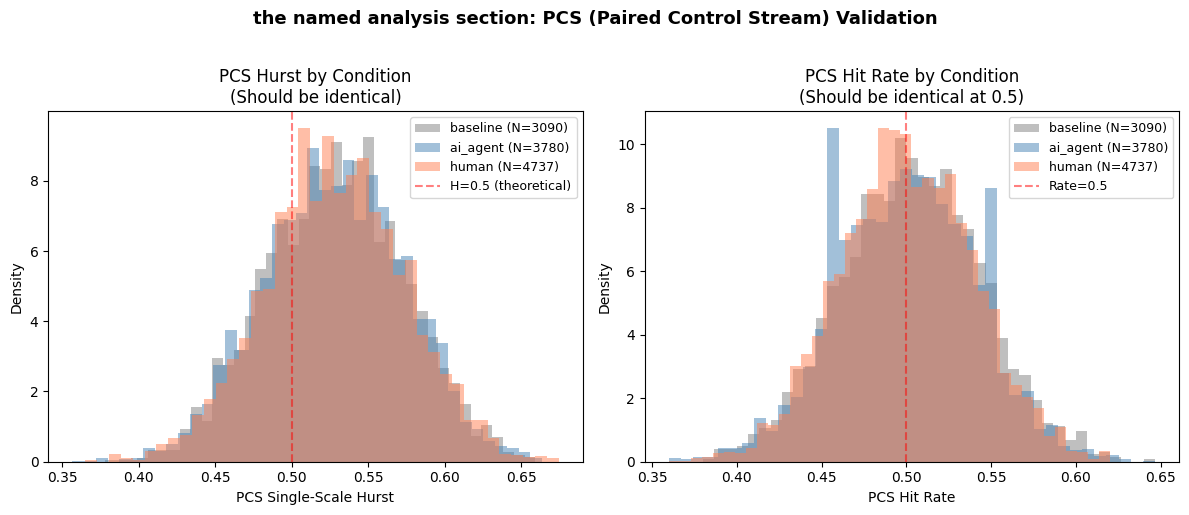


ANALYSIS SECTION

PCS descriptive summary:
  - Single-scale R/S score: ~0.528 overall
  - Hit rate: ~0.5003
  - No block-level PCS R/S-score condition difference detected (ANOVA p=0.5025)
  - These checks do not establish exact unbiasedness, equivalence, or independence



In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Describe PCS hit rate and single-scale R/S score by condition.
#          At N=150 the implemented R/S score has a finite-sample offset,
#          so its expected value under the calibrated null is not 0.5 exactly.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("="*70)
print("ANALYSIS SECTION")
print("="*70)
print("""
The PCS is the built-in control. It receives the OPPOSITE half of each
QRNG call — bits the participant is NOT trying to influence.

(Note: The PCS is labeled "demon" in the source code, following Maxwell's
demon — a deterministic sorter that operates without intention. All
variable names use 'demon' but we refer to it as PCS in text.)

For the implemented single-scale R/S ordering score on calibrated random
150-bit sequences, the expected value is not exactly 0.5. For N=150, the
calibrated null mean is approximately 0.53.

Key checks:
  1. Describe the PCS single-scale R/S score relative to its calibrated null
  2. Test for detected PCS location differences across conditions
  3. Do not interpret a non-significant result as equivalence or independence
""")

# ─────────────────────────────────────────────────────────────
# PART 1: PCS Single-Scale Hurst by Condition
# ─────────────────────────────────────────────────────────────
print("-"*60)
print("PART 1: PCS Single-Scale Hurst by Condition")
print("-"*60)

print(f"\n{'Condition':<15} {'N':>6} {'Mean H':>10} {'SD':>10} {'SE':>10}")
print("-"*55)
for cond in ['baseline', 'ai_agent', 'human']:
    sub = df_hurst[df_hurst['condition'] == cond]['hurst_pcs'].dropna()
    print(f"  {cond:<13} {len(sub):>6} {sub.mean():>10.6f} {sub.std():>10.6f} {sub.sem():>10.6f}")

# Pairwise tests
base_pcs = df_hurst[df_hurst['condition'] == 'baseline']['hurst_pcs'].dropna()
human_pcs = df_hurst[df_hurst['condition'] == 'human']['hurst_pcs'].dropna()
ai_pcs = df_hurst[df_hurst['condition'] == 'ai_agent']['hurst_pcs'].dropna()

t_hb, p_hb = stats.ttest_ind(human_pcs, base_pcs)
t_ab, p_ab = stats.ttest_ind(ai_pcs, base_pcs)
t_ha, p_ha = stats.ttest_ind(human_pcs, ai_pcs)

print(f"\nPairwise comparisons:")
print(f"  Human vs Baseline:  t={t_hb:+.3f}, p={p_hb:.4f}")
print(f"  AI vs Baseline:     t={t_ab:+.3f}, p={p_ab:.4f}")
print(f"  Human vs AI:        t={t_ha:+.3f}, p={p_ha:.4f}")

# ANOVA
f_stat, p_anova = stats.f_oneway(base_pcs, human_pcs, ai_pcs)
print(f"\nOne-way ANOVA: F={f_stat:.3f}, p={p_anova:.4f}")

if p_anova > 0.05:
    print("  → No block-level PCS R/S-score difference was detected across conditions")
    print("    (This does not establish equivalence or condition invariance.)")
else:
    print("  → WARNING: Unexpected difference in PCS Hurst across conditions")

# ─────────────────────────────────────────────────────────────
# PART 2: Finite-Sample Bias Explanation
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 2: Finite-Sample Calibration")
print("-"*60)

overall_pcs = df_hurst['hurst_pcs'].dropna()
print(f"""
Overall PCS single-scale Hurst: {overall_pcs.mean():.6f} (SD={overall_pcs.std():.6f})

Why not exactly 0.5?

The implemented single-scale R/S score has a finite-sample offset for short
sequences. At N=150 its calibrated null mean is above 0.5.

This finite-sample offset:
  - Is expected in both 150-bit streams under matched generating conditions
  - Largely cancels in a paired difference when the stream margins are similar
  - Is not by itself evidence of non-randomness
  - Does not guarantee exact cancellation under unequal generating processes

The relevant quantity for our analysis is the DELTA (subject − PCS),
which reduces a shared offset but must still be calibrated as a paired statistic.
""")

# ─────────────────────────────────────────────────────────────
# PART 3: PCS Hit Rate Check
# ─────────────────────────────────────────────────────────────
print("-"*60)
print("PART 3: PCS Hit Rate by Condition")
print("-"*60)

print(f"\n{'Condition':<15} {'N':>6} {'Mean Rate':>12} {'SD':>10}")
print("-"*45)
for cond in ['baseline', 'ai_agent', 'human']:
    sub = df[df['condition'] == cond]['rate_demon'].dropna()
    print(f"  {cond:<13} {len(sub):>6} {sub.mean():>12.6f} {sub.std():>10.6f}")

overall_pcs_rate = df['rate_demon'].dropna()
# One-sample t-test against 0.5
t_pcs, p_pcs = stats.ttest_1samp(overall_pcs_rate, 0.5)
print(f"\nOverall PCS hit rate: {overall_pcs_rate.mean():.6f}")
print(f"One-sample t-test vs 0.5: t={t_pcs:+.3f}, p={p_pcs:.4f}")
if p_pcs > 0.05:
    print("  → No departure of the overall PCS hit-rate mean from 0.5 was detected")

# ─────────────────────────────────────────────────────────────
# Visualization
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
for cond, color in [('baseline', 'gray'), ('ai_agent', 'steelblue'), ('human', 'coral')]:
    sub = df_hurst[df_hurst['condition'] == cond]['hurst_pcs'].dropna()
    ax1.hist(sub, bins=40, alpha=0.5, label=f'{cond} (N={len(sub)})',
             color=color, density=True)
ax1.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='H=0.5 (theoretical)')
ax1.set_xlabel('PCS Single-Scale Hurst')
ax1.set_ylabel('Density')
ax1.set_title('PCS Hurst by Condition\n(Should be identical)')
ax1.legend(fontsize=9)

ax2 = axes[1]
for cond, color in [('baseline', 'gray'), ('ai_agent', 'steelblue'), ('human', 'coral')]:
    sub = df[df['condition'] == cond]['rate_demon'].dropna()
    ax2.hist(sub, bins=40, alpha=0.5, label=f'{cond} (N={len(sub)})',
             color=color, density=True)
ax2.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Rate=0.5')
ax2.set_xlabel('PCS Hit Rate')
ax2.set_ylabel('Density')
ax2.set_title('PCS Hit Rate by Condition\n(Should be identical at 0.5)')
ax2.legend(fontsize=9)

plt.suptitle('the named analysis section: PCS (Paired Control Stream) Validation', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ANALYSIS SECTION")
print("="*70)
print(f"""
PCS descriptive summary:
  - Single-scale R/S score: ~{overall_pcs.mean():.3f} overall
  - Hit rate: ~{overall_pcs_rate.mean():.4f}
  - No block-level PCS R/S-score condition difference detected (ANOVA p={p_anova:.4f})
  - These checks do not establish exact unbiasedness, equivalence, or independence
""")


### Why a Single-Scale R/S Ordering Score — Metric Justification

**Paper section: 2.6.2 (single-scale R/S ordering score)**


In [6]:
# PURPOSE: Justify the fixed-150-bit R/S ordering score against the
# particular multiscale R/S regression previously considered for these blocks.
# The comparison is performed under a composition-preserving shuffle null and
# does not use the Human-5+ result or any experimental p-value to choose a metric.

import numpy as np
import pandas as pd
from scipy import stats
from numpy.random import default_rng

print("=" * 70)
print("METRIC DEFINITION AND N=150 ESTIMATOR-CHOICE CALIBRATION")
print("=" * 70)
print(r"""
For each fixed 150-bit stream, bits are mapped to {-1,+1}. Let Y_k be
the cumulative sum of mean-centered values, R = max(Y_k)-min(Y_k), and
S = sqrt(sum((x_i-xbar)^2)/n). The implemented score is

    q_RS = log(R/S) / log(n),  n = 150,

with the edge handling documented in hurstApprox(). Because q_RS is
calculated at one scale, it is an ordering-sensitive R/S score—not a
conventional Hurst exponent and not a measure of long-range memory.

Higher and lower values are interpreted only as persistence-like and
anti-persistence-like ordering within the observed 150-bit stream.
""")

def compute_multiscale_rs_slope(bits_list, sizes=(10, 15, 25, 37, 50, 75)):
    """Comparison estimator: slope of log(mean R/S) on log(window size)."""
    if bits_list is None:
        return np.nan
    try:
        bits = np.asarray(bits_list, dtype=float)
        valid = []
        for size in sizes:
            if size > len(bits) // 2:
                continue
            values = []
            for start in range(0, (len(bits) // size) * size, size):
                segment = bits[start:start + size]
                centered = segment - segment.mean()
                scale = segment.std(ddof=1)
                if scale > 0:
                    values.append(np.ptp(np.cumsum(centered)) / scale)
            if values:
                valid.append((size, np.mean(values)))
        if len(valid) < 3:
            return np.nan
        return float(stats.linregress(
            np.log([item[0] for item in valid]),
            np.log([item[1] for item in valid]),
        ).slope)
    except (TypeError, ValueError, FloatingPointError):
        return np.nan

# Shuffle Baseline streams to destroy their observed ordering while preserving
# every stream's exact number of zeros and ones. This calibration concerns
# estimator variability at n=150; it does not test the experimental effect.
CALIBRATION_SEED = 20260805
rng = default_rng(CALIBRATION_SEED)
baseline_pairs = df_hurst.loc[
    df_hurst["condition"].eq("baseline"), ["subject_bits", "demon_bits"]
].dropna().copy()

def shuffled_copy(bits):
    values = np.asarray(bits, dtype=np.int8).copy()
    rng.shuffle(values)
    return values

calibration_rows = []
for row in baseline_pairs.itertuples(index=False):
    subject = shuffled_copy(row.subject_bits)
    pcs = shuffled_copy(row.demon_bits)
    calibration_rows.append({
        "single_scale_delta": hurstApprox(subject) - hurstApprox(pcs),
        "multiscale_delta": (
            compute_multiscale_rs_slope(subject) - compute_multiscale_rs_slope(pcs)
        ),
    })

calibration = pd.DataFrame(calibration_rows)
summary = calibration.agg(["count", "mean", "std"]).T
summary["missing"] = len(calibration) - summary["count"]
print("\nComposition-preserving shuffled Baseline pairs")
print(summary.to_string(float_format=lambda value: f"{value:.6f}"))

single_sd = calibration["single_scale_delta"].std()
multi_sd = calibration["multiscale_delta"].std()
ratio = multi_sd / single_sd
print(f"\nSD ratio, tested multiscale / single-scale: {ratio:.3f}x")
print("""
Interpretation:
  - If the ratio is above 1, the tested multiscale regression is more
    variable under this n=150, composition-preserving shuffle calibration.
  - This supports using the fixed-scale score as the more stable exploratory
    within-block ordering summary for this protocol.
  - It does not establish a universal advantage over every Hurst estimator,
    validate the Human-5+ pattern, or imply long-range memory.
""")


METRIC DEFINITION AND N=150 ESTIMATOR-CHOICE CALIBRATION

For each fixed 150-bit stream, bits are mapped to {-1,+1}. Let Y_k be
the cumulative sum of mean-centered values, R = max(Y_k)-min(Y_k), and
S = sqrt(sum((x_i-xbar)^2)/n). The implemented score is

    q_RS = log(R/S) / log(n),  n = 150,

with the edge handling documented in hurstApprox(). Because q_RS is
calculated at one scale, it is an ordering-sensitive R/S score—not a
conventional Hurst exponent and not a measure of long-range memory.

Higher and lower values are interpreted only as persistence-like and
anti-persistence-like ordering within the observed 150-bit stream.


Composition-preserving shuffled Baseline pairs
                         count      mean      std  missing
single_scale_delta 3090.000000  0.001580 0.065148 0.000000
multiscale_delta   3090.000000 -0.003220 0.114614 0.000000

SD ratio, tested multiscale / single-scale: 1.759x

Interpretation:
  - If the ratio is above 1, the tested multiscale regression is m

### Authoritative Four-Estimand Component Table

This section prevents a paired difference from concealing how its two component streams behaved. For both hit rate and the single-scale R/S ordering score, it reports:

1. the Subject-stream mean;
2. the PCS-stream mean;
3. the within-call paired difference, Subject minus PCS; and
4. the condition delta-of-deltas relative to Baseline.

Point estimates are **block-weighted descriptions of the observed records**, matching the notebook's pooled block summaries. Uncertainty preserves the known collection hierarchy: Baseline and AI resample whole sessions; Human analyses resample participants and then whole sessions within participant. Blocks are never resampled independently. Accordingly, the intervals describe sensitivity to the observed session/participant hierarchy; they do not repair post-hoc subgroup selection or turn the three Human 5+ contributors into a population sample. The Human 5+ intervals are descriptive sensitivity intervals only.


In [7]:
# Authoritative component reporting for both primary metric families.
# This is deliberately deterministic, compact, and independent of later PyMC cells.

FOUR_ESTIMAND_SEED = 20260805
FOUR_ESTIMAND_DRAWS = 4000

cohorts_4e = {
    "Baseline": df.loc[df["condition"].eq("baseline")].copy(),
    "AI": df.loc[df["condition"].eq("ai_agent")].copy(),
    "Human (all)": df.loc[df["condition"].eq("human")].copy(),
    "Human 5+": df.loc[
        df["condition"].eq("human") & df["session_count"].ge(5)
    ].copy(),
}

metric_specs_4e = {
    "Hit rate": ("subject_hit_rate", "pcs_hit_rate"),
    "Single-scale R/S ordering score": ("rs_subject", "rs_pcs"),
}


def _session_summaries_4e(frame, subject_col, pcs_col):
    """One row per complete session, retaining sums so block weighting is explicit."""
    work = frame.dropna(subset=[subject_col, pcs_col]).copy()
    work["_delta"] = work[subject_col] - work[pcs_col]
    return (
        work.groupby(["participant_id", "session_id"], dropna=False)
        .agg(
            n_blocks=(subject_col, "size"),
            subject_sum=(subject_col, "sum"),
            pcs_sum=(pcs_col, "sum"),
            delta_sum=("_delta", "sum"),
        )
        .reset_index()
    )


def _means_from_session_rows_4e(rows):
    n = rows[:, 0].sum()
    return np.array([
        rows[:, 1].sum() / n,
        rows[:, 2].sum() / n,
        rows[:, 3].sum() / n,
    ])


def _hierarchical_draws_4e(frame, subject_col, pcs_col, human, n_draws, rng):
    """Resample participant -> whole session for Human; whole session otherwise."""
    sessions = _session_summaries_4e(frame, subject_col, pcs_col)
    value_cols = ["n_blocks", "subject_sum", "pcs_sum", "delta_sum"]
    draws = np.empty((n_draws, 3), dtype=float)

    if human:
        participant_groups = [
            group[value_cols].to_numpy(dtype=float)
            for _, group in sessions.groupby("participant_id", dropna=False, sort=False)
        ]
        n_participants = len(participant_groups)
        for b in range(n_draws):
            selected = rng.integers(0, n_participants, size=n_participants)
            sampled_sessions = []
            for idx in selected:
                participant_sessions = participant_groups[idx]
                chosen = rng.integers(
                    0, len(participant_sessions), size=len(participant_sessions)
                )
                sampled_sessions.append(participant_sessions[chosen])
            draws[b] = _means_from_session_rows_4e(np.vstack(sampled_sessions))
    else:
        session_rows = sessions[value_cols].to_numpy(dtype=float)
        n_sessions = len(session_rows)
        for b in range(n_draws):
            chosen = rng.integers(0, n_sessions, size=n_sessions)
            draws[b] = _means_from_session_rows_4e(session_rows[chosen])

    observed = _means_from_session_rows_4e(
        sessions[value_cols].to_numpy(dtype=float)
    )
    return observed, draws, sessions


def _fmt_estimate_4e(estimate, draws):
    lo, hi = np.quantile(draws, [0.025, 0.975])
    return f"{estimate:+.6f} [{lo:+.6f}, {hi:+.6f}]"


rng_4e = np.random.default_rng(FOUR_ESTIMAND_SEED)
records_4e = []
draw_store_4e = {}

for metric_name, (subject_col, pcs_col) in metric_specs_4e.items():
    for cohort_name, cohort_df in cohorts_4e.items():
        is_human = cohort_name.startswith("Human")
        observed, draws, sessions = _hierarchical_draws_4e(
            cohort_df, subject_col, pcs_col, is_human,
            FOUR_ESTIMAND_DRAWS, rng_4e,
        )
        draw_store_4e[(metric_name, cohort_name)] = draws
        n_people = sessions["participant_id"].nunique(dropna=False)
        population = (
            "Selected Human 5+ observed records; descriptive sensitivity only"
            if cohort_name == "Human 5+"
            else f"Observed {cohort_name} records"
        )
        records_4e.append({
            "Metric": metric_name,
            "Population represented": population,
            "Condition": cohort_name,
            "Blocks": int(sessions["n_blocks"].sum()),
            "Sessions": int(len(sessions)),
            "Contributors": int(n_people),
            "Subject mean [95% interval]": _fmt_estimate_4e(observed[0], draws[:, 0]),
            "PCS mean [95% interval]": _fmt_estimate_4e(observed[1], draws[:, 1]),
            "Subject - PCS [95% interval]": _fmt_estimate_4e(observed[2], draws[:, 2]),
            "Delta-of-deltas vs Baseline [95% interval]": None,
        })

component_table_4e = pd.DataFrame(records_4e)

# Compute each condition's paired delta minus the independently resampled
# Baseline paired delta. Baseline itself is exactly zero by definition.
for metric_name in metric_specs_4e:
    metric_mask = component_table_4e["Metric"].eq(metric_name)
    baseline_draws = draw_store_4e[(metric_name, "Baseline")][:, 2]
    for cohort_name in cohorts_4e:
        row_mask = metric_mask & component_table_4e["Condition"].eq(cohort_name)
        if cohort_name == "Baseline":
            component_table_4e.loc[
                row_mask, "Delta-of-deltas vs Baseline [95% interval]"
            ] = "+0.000000 [reference]"
            continue
        cohort_draws = draw_store_4e[(metric_name, cohort_name)][:, 2]
        contrast_draws = cohort_draws - baseline_draws
        cohort_observed = float(
            cohorts_4e[cohort_name][metric_specs_4e[metric_name][0]].mean()
            - cohorts_4e[cohort_name][metric_specs_4e[metric_name][1]].mean()
        )
        baseline_observed = float(
            cohorts_4e["Baseline"][metric_specs_4e[metric_name][0]].mean()
            - cohorts_4e["Baseline"][metric_specs_4e[metric_name][1]].mean()
        )
        component_table_4e.loc[
            row_mask, "Delta-of-deltas vs Baseline [95% interval]"
        ] = _fmt_estimate_4e(cohort_observed - baseline_observed, contrast_draws)

print("AUTHORITATIVE FOUR-ESTIMAND COMPONENT TABLE")
print("Point estimates: block-weighted observed records.")
print("Intervals: whole-session resampling; Human adds participant resampling.")
print("Human 5+ intervals are descriptive and are not selection-adjusted.")
display(component_table_4e)

# Fail-loud arithmetic checks: the paired estimate must equal the displayed
# Subject component minus the displayed PCS component before formatting.
for metric_name, (subject_col, pcs_col) in metric_specs_4e.items():
    for cohort_name, cohort_df in cohorts_4e.items():
        direct = (cohort_df[subject_col] - cohort_df[pcs_col]).mean()
        components = cohort_df[subject_col].mean() - cohort_df[pcs_col].mean()
        assert np.isclose(direct, components), (metric_name, cohort_name)

assert len(component_table_4e) == 8
print("\nFour-estimand arithmetic and row-count checks passed.")


AUTHORITATIVE FOUR-ESTIMAND COMPONENT TABLE
Point estimates: block-weighted observed records.
Intervals: whole-session resampling; Human adds participant resampling.
Human 5+ intervals are descriptive and are not selection-adjusted.


,Metric,Population represented,Condition,Blocks,Sessions,Contributors,Subject mean [95% interval],PCS mean [95% interval],Subject - PCS [95% interval],Delta-of-deltas vs Baseline [95% interval]
0,Hit rate,Observed Baseline records,Baseline,3090,103,3,"+0.500179 [+0.498831, +0.501575]","+0.499978 [+0.498434, +0.501443]","+0.000201 [-0.001743, +0.002265]",+0.000000 [reference]
1,Hit rate,Observed AI records,AI,3780,126,15,"+0.500284 [+0.499049, +0.501506]","+0.500060 [+0.498813, +0.501365]","+0.000224 [-0.001328, +0.001758]","+0.000023 [-0.002532, +0.002524]"
2,Hit rate,Observed Human (all) records,Human (all),4737,158,121,"+0.500386 [+0.499096, +0.501532]","+0.500585 [+0.499183, +0.501898]","-0.000200 [-0.002034, +0.001621]","-0.000400 [-0.003190, +0.002246]"
3,Hit rate,Selected Human 5+ observed records; descriptiv...,Human 5+,840,28,3,"+0.502238 [+0.499841, +0.505911]","+0.501365 [+0.499035, +0.505141]","+0.000873 [-0.003674, +0.005875]","+0.000672 [-0.004159, +0.006052]"
4,Single-scale R/S ordering score,Observed Baseline records,Baseline,3090,103,3,"+0.527148 [+0.525521, +0.528776]","+0.528889 [+0.527425, +0.530394]","-0.001741 [-0.003823, +0.000301]",+0.000000 [reference]
5,Single-scale R/S ordering score,Observed AI records,AI,3780,126,15,"+0.528542 [+0.527041, +0.530087]","+0.527599 [+0.526258, +0.528997]","+0.000943 [-0.001195, +0.003104]","+0.002684 [-0.000170, +0.005647]"
6,Single-scale R/S ordering score,Observed Human (all) records,Human (all),4737,158,121,"+0.529249 [+0.527890, +0.530635]","+0.528121 [+0.526773, +0.529532]","+0.001128 [-0.000944, +0.003127]","+0.002869 [-0.000010, +0.005750]"
7,Single-scale R/S ordering score,Selected Human 5+ observed records; descriptiv...,Human 5+,840,28,3,"+0.530293 [+0.526092, +0.535066]","+0.525944 [+0.520318, +0.529370]","+0.004349 [-0.000437, +0.014001]","+0.006090 [+0.000776, +0.016003]"



Four-estimand arithmetic and row-count checks passed.


# Bayesian Hierarchical Hit-Rate Model

**Paper section: 3.5 (Mean-Level Hit-Rate Results)**

⏱ Long run time.


In [8]:
# Prepare the paired hierarchical hit-rate analysis
print("=" * 70)
print("PAIRED HIERARCHICAL HIT-RATE MODEL")
print("=" * 70)
print("Outcome: per-block Subject hit rate minus paired PCS hit rate (delta_hit).")
print("Hierarchy: participant and session random intercepts; block is the outcome unit.")

RANDOM_SEED = 42
MIN_SESSIONS = 5
df_bayes = df[df['condition'].isin(['baseline', 'human', 'ai_agent'])].copy()
human_counts = (df_bayes[df_bayes['condition'] == 'human']
                .groupby('participant_id')['session_id'].nunique())
eligible_humans = set(human_counts[human_counts >= MIN_SESSIONS].index)
df_bayes = df_bayes[(df_bayes['condition'] != 'human') |
                    (df_bayes['participant_id'].isin(eligible_humans))].copy()

df_bayes['is_human'] = (df_bayes['condition'] == 'human').astype(int)
df_bayes['is_ai'] = (df_bayes['condition'] == 'ai_agent').astype(int)
df_bayes['participant_idx'] = df_bayes['participant_id'].astype(str).astype('category').cat.codes
df_bayes['session_idx'] = df_bayes['session_id'].astype(str).astype('category').cat.codes

order_col = next((c for c in ['blockOrder', 'block_order', 'block_idx'] if c in df_bayes), None)
if order_col is None:
    raise ValueError("No within-session block-order column is available.")
df_bayes['x_order'] = df_bayes.groupby('session_id')[order_col].transform(
    lambda x: (x - x.mean()) / (x.max() - x.min()) if x.max() > x.min() else 0.0
)

y = df_bayes['delta_hit'].to_numpy(float)
is_human = df_bayes['is_human'].to_numpy(int)
is_ai = df_bayes['is_ai'].to_numpy(int)
x_order = df_bayes['x_order'].to_numpy(float)
part = df_bayes['participant_idx'].to_numpy(int)
sess = df_bayes['session_idx'].to_numpy(int)
n_participants = int(df_bayes['participant_idx'].nunique())
n_sessions = int(df_bayes['session_idx'].nunique())
print(f"Data ready: {len(y):,} paired blocks, {n_sessions} sessions, {n_participants} participants")
print(f"Eligible Human 5+ subgroup: {len(eligible_humans)} participants")


PAIRED HIERARCHICAL HIT-RATE MODEL
Outcome: per-block Subject hit rate minus paired PCS hit rate (delta_hit).
Hierarchy: participant and session random intercepts; block is the outcome unit.
Data ready: 7,710 paired blocks, 257 sessions, 20 participants
Eligible Human 5+ subgroup: 3 participants


In [9]:
# Fixed-effects identifiability gate
X_fixed = np.column_stack([np.ones(len(y)), is_human, is_ai, x_order])
fixed_col_names = ['intercept', 'is_human', 'is_ai', 'x_order']
rank = np.linalg.matrix_rank(X_fixed)
if rank != X_fixed.shape[1]:
    raise ValueError(f"Rank-deficient fixed-effects matrix: {rank}/{X_fixed.shape[1]}")
print(f"Fixed-effects design matrix: full rank ({rank}/{X_fixed.shape[1]})")


Fixed-effects design matrix: full rank (4/4)


In [10]:
# Fit the paired hierarchical model
import pymc as pm
import arviz as az

with pm.Model() as model:
    mu = pm.Normal('mu', 0.0, 0.02)
    beta_human = pm.Normal('beta_human', 0.0, 0.02)
    beta_ai = pm.Normal('beta_ai', 0.0, 0.02)
    b_order = pm.Normal('b_order', 0.0, 0.02)
    sigma_part = pm.HalfNormal('sigma_part', 0.02)
    sigma_sess = pm.HalfNormal('sigma_sess', 0.02)
    sigma_obs = pm.HalfNormal('sigma_obs', 0.10)
    nu_minus_two = pm.Exponential('nu_minus_two', 1 / 10)
    part_offset = pm.Normal('part_offset', 0.0, 1.0, shape=n_participants)
    sess_offset = pm.Normal('sess_offset', 0.0, 1.0, shape=n_sessions)
    expected_delta = (mu + beta_human * is_human + beta_ai * is_ai + b_order * x_order
                      + sigma_part * part_offset[part] + sigma_sess * sess_offset[sess])
    pm.StudentT('obs', nu=nu_minus_two + 2, mu=expected_delta, sigma=sigma_obs, observed=y)
    idata = pm.sample(draws=2000, tune=2000, chains=4, target_accept=0.95,
                      random_seed=RANDOM_SEED, return_inferencedata=True)

summ = az.summary(idata, var_names=['mu', 'beta_human', 'beta_ai', 'b_order',
                                    'sigma_part', 'sigma_sess', 'sigma_obs'], hdi_prob=0.95)
print(summ)
if not ((summ['r_hat'] < 1.01).all() and (summ['ess_bulk'] > 400).all()):
    raise RuntimeError("MCMC diagnostics failed (R-hat or bulk ESS); do not interpret this fit.")

mu_draw = idata.posterior['mu'].values.ravel()
bh_draw = idata.posterior['beta_human'].values.ravel()
ba_draw = idata.posterior['beta_ai'].values.ravel()
dp_baseline = mu_draw
dp_human = mu_draw + bh_draw
dp_ai = mu_draw + ba_draw
dp_diff = dp_human - dp_ai

def hdi_from_draws(draws, prob=0.95):
    return tuple(np.asarray(az.hdi(draws, hdi_prob=prob)))

hdi_b = hdi_from_draws(dp_baseline)
hdi_h = hdi_from_draws(dp_human)
hdi_a = hdi_from_draws(dp_ai)
hdi_diff = hdi_from_draws(dp_diff)
p_human_pos = float(np.mean(dp_human > 0))
p_ai_pos = float(np.mean(dp_ai > 0))
p_human_gt_ai = float(np.mean(dp_diff > 0))

print("\nPaired Subject-minus-PCS hit-rate estimates:")
for name, draws, hdi in [('Baseline', dp_baseline, hdi_b), ('Human 5+', dp_human, hdi_h), ('AI', dp_ai, hdi_a)]:
    print(f"  {name:<10} mean={draws.mean():+.6f}, 95% HDI=[{hdi[0]:+.6f}, {hdi[1]:+.6f}], Pr(>0)={np.mean(draws>0):.3f}")
print(f"  Human 5+ - AI contrast: {dp_diff.mean():+.6f}, 95% HDI=[{hdi_diff[0]:+.6f}, {hdi_diff[1]:+.6f}]")
print("Interpretation is limited to this frozen sample; Human 5+ contains only three participants.")


Output()

             mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
mu          0.000  0.001    -0.003      0.003        0.0      0.0    7079.0   
beta_human  0.000  0.002    -0.004      0.005        0.0      0.0   12490.0   
beta_ai     0.000  0.002    -0.003      0.003        0.0      0.0    7271.0   
b_order    -0.001  0.002    -0.006      0.003        0.0      0.0   19244.0   
sigma_part  0.001  0.001     0.000      0.003        0.0      0.0    2987.0   
sigma_sess  0.001  0.001     0.000      0.003        0.0      0.0    3740.0   
sigma_obs   0.057  0.001     0.056      0.058        0.0      0.0   15328.0   

            ess_tail  r_hat  
mu            5629.0    1.0  
beta_human    6594.0    1.0  
beta_ai       5139.0    1.0  
b_order       6052.0    1.0  
sigma_part    4104.0    1.0  
sigma_sess    3529.0    1.0  
sigma_obs     6448.0    1.0  

Paired Subject-minus-PCS hit-rate estimates:
  Baseline   mean=+0.000184, 95% HDI=[-0.002747, +0.002827], Pr(>0)=0.558
  Human

### Order Effect — Split by Condition (and Human 5+ Session Subgroup)

**Paper section: 3.5**
⏱ Long run time.


In [11]:
# Prepare condition-specific order effects on paired delta_hit
print("=" * 70)
print("PAIRED ORDER-EFFECT MODEL")
print("=" * 70)
df_order = df[df['condition'].isin(['baseline', 'human', 'ai_agent'])].copy()
df_order['is_human'] = (df_order['condition'] == 'human').astype(int)
df_order['is_ai'] = (df_order['condition'] == 'ai_agent').astype(int)
df_order['is_5plus'] = ((df_order['condition'] == 'human') & (df_order['session_count'] >= 5)).astype(int)
order_col = next((c for c in ['blockOrder', 'block_order', 'block_idx'] if c in df_order), None)
if order_col is None:
    raise ValueError("No within-session block-order column is available.")
df_order['x_order'] = df_order.groupby('session_id')[order_col].transform(
    lambda x: (x - x.mean()) / (x.max() - x.min()) if x.max() > x.min() else 0.0
)
df_order['participant_idx'] = df_order['participant_id'].astype(str).astype('category').cat.codes
df_order['session_idx'] = df_order['session_id'].astype(str).astype('category').cat.codes
y_ord = df_order['delta_hit'].to_numpy(float)
is_human_ord = df_order['is_human'].to_numpy(int)
is_ai_ord = df_order['is_ai'].to_numpy(int)
is_5plus_ord = df_order['is_5plus'].to_numpy(int)
x_order_ord = df_order['x_order'].to_numpy(float)
part_ord = df_order['participant_idx'].to_numpy(int)
sess_ord = df_order['session_idx'].to_numpy(int)
n_participants_ord = df_order['participant_idx'].nunique()
n_sessions_ord = df_order['session_idx'].nunique()
n_human_short_part = df_order.loc[(df_order.is_human == 1) & (df_order.is_5plus == 0), 'participant_id'].nunique()
n_human_5plus_part = df_order.loc[df_order.is_5plus == 1, 'participant_id'].nunique()
print(f"Data ready: {len(y_ord):,} paired blocks; Human 5+: {n_human_5plus_part} participants")


PAIRED ORDER-EFFECT MODEL
Data ready: 11,607 paired blocks; Human 5+: 3 participants


In [12]:
# Fixed-effects identifiability gate for order interactions
X_fixed_ord = np.column_stack([
    np.ones(len(y_ord)), is_human_ord, is_ai_ord, x_order_ord,
    x_order_ord * is_human_ord, x_order_ord * is_ai_ord, x_order_ord * is_5plus_ord
])
rank = np.linalg.matrix_rank(X_fixed_ord)
if rank != X_fixed_ord.shape[1]:
    raise ValueError(f"Rank-deficient order model matrix: {rank}/{X_fixed_ord.shape[1]}")
print(f"Order-model fixed-effects matrix: full rank ({rank}/{X_fixed_ord.shape[1]})")


Order-model fixed-effects matrix: full rank (7/7)


In [13]:
# Fit condition-specific paired order effects
with pm.Model() as model_order:
    mu_order = pm.Normal('mu_order', 0.0, 0.02)
    beta_human_order = pm.Normal('beta_human_order', 0.0, 0.02)
    beta_ai_order = pm.Normal('beta_ai_order', 0.0, 0.02)
    b_order = pm.Normal('b_order', 0.0, 0.02)
    d_order_human = pm.Normal('d_order_human', 0.0, 0.02)
    d_order_ai = pm.Normal('d_order_ai', 0.0, 0.02)
    d_order_human5 = pm.Normal('d_order_human5', 0.0, 0.02)
    sigma_part_order = pm.HalfNormal('sigma_part_order', 0.02)
    sigma_sess_order = pm.HalfNormal('sigma_sess_order', 0.02)
    sigma_obs_order = pm.HalfNormal('sigma_obs_order', 0.10)
    part_off = pm.Normal('part_off', 0.0, 1.0, shape=n_participants_ord)
    sess_off = pm.Normal('sess_off', 0.0, 1.0, shape=n_sessions_ord)
    expected = (mu_order + beta_human_order * is_human_ord + beta_ai_order * is_ai_ord
                + b_order * x_order_ord
                + d_order_human * x_order_ord * is_human_ord
                + d_order_ai * x_order_ord * is_ai_ord
                + d_order_human5 * x_order_ord * is_5plus_ord
                + sigma_part_order * part_off[part_ord]
                + sigma_sess_order * sess_off[sess_ord])
    pm.StudentT('obs_order', nu=5, mu=expected, sigma=sigma_obs_order, observed=y_ord)
    idata_order = pm.sample(draws=2000, tune=2000, chains=4, target_accept=0.95,
                            random_seed=RANDOM_SEED, return_inferencedata=True)

order_vars = [
    "b_order",
    "d_order_human",
    "d_order_ai",
    "d_order_human5",
    "sigma_part_order",
    "sigma_sess_order",
]

summ_order = az.summary(
    idata_order,
    var_names=order_vars,
    hdi_prob=0.95,
    round_to="none",
)

display(
    summ_order[
        ["mean", "sd", "ess_bulk", "ess_tail", "r_hat"]
    ]
)

max_rhat = summ_order["r_hat"].max()
min_ess_bulk = summ_order["ess_bulk"].min()
divergences = int(idata_order.sample_stats["diverging"].sum())

print(f"Maximum unrounded R-hat: {max_rhat:.6f}")
print(f"Minimum bulk ESS: {min_ess_bulk:.1f}")
print(f"Divergences: {divergences}")

if (
    max_rhat > 1.01
    or min_ess_bulk < 400
    or divergences > 0
):
    raise RuntimeError(
        "Order-model MCMC diagnostics genuinely failed; "
        "do not interpret this fit."
    )

print("Order-model diagnostics passed.")
b_order_draw = idata_order.posterior['b_order'].values.ravel()
d_human_draw = idata_order.posterior['d_order_human'].values.ravel()
d_ai_draw = idata_order.posterior['d_order_ai'].values.ravel()
d_human5_draw = idata_order.posterior['d_order_human5'].values.ravel()
order_baseline = b_order_draw
order_ai = b_order_draw + d_ai_draw
order_human_short = b_order_draw + d_human_draw
order_human_5plus = b_order_draw + d_human_draw + d_human5_draw
groups = {'Baseline': order_baseline, 'AI': order_ai,
          'Human (1-4 sessions)': order_human_short, 'Human (5+ sessions)': order_human_5plus}
for name, draws in groups.items():
    lo, hi = hdi_from_draws(draws)
    print(f"{name:<24} slope={draws.mean():+.6f}, 95% HDI=[{lo:+.6f}, {hi:+.6f}]")
print("These are within-session associations in paired delta_hit, not evidence that repetition caused change.")


Output()

,mean,sd,ess_bulk,ess_tail,r_hat
b_order,0.000570,0.003321,6496.673552,6000.950325,1.000695
d_order_human,-0.001039,0.004364,6925.341532,6071.419322,0.999900
d_order_ai,-0.003776,0.004458,7574.805612,6551.818456,0.999769
d_order_human5,0.000544,0.006811,13662.775471,5432.028393,1.000115
sigma_part_order,0.002648,0.001325,1237.173462,2007.036360,1.001562
sigma_sess_order,0.001897,0.001195,1249.856214,2722.125740,1.005432


Maximum unrounded R-hat: 1.005432
Minimum bulk ESS: 1237.2
Divergences: 0
Order-model diagnostics passed.
Baseline                 slope=+0.000570, 95% HDI=[-0.006193, +0.006875]
AI                       slope=-0.003207, 95% HDI=[-0.009048, +0.003030]
Human (1-4 sessions)     slope=-0.000469, 95% HDI=[-0.006197, +0.005075]
Human (5+ sessions)      slope=+0.000075, 95% HDI=[-0.012116, +0.012495]
These are within-session associations in paired delta_hit, not evidence that repetition caused change.


### Population and AI Paired Hit-Rate Comparisons

**Paper section: 3.5**

This section reports the population-level all-Human and AI comparisons from the authoritative four-estimand table above. The outcome is the within-call paired hit-rate difference, Subject minus PCS; condition contrasts are delta-of-deltas relative to Baseline. Intervals preserve whole sessions and, for Human records, resample participants before sessions. They are descriptive hierarchy-sensitivity intervals, not equivalence tests. The Human 5+ row is retained only as a post-hoc, three-contributor sensitivity result.


In [14]:
# Authoritative paired hit-rate comparisons (computed in the four-estimand section).
hit_rate_table = component_table_4e.loc[
    component_table_4e["Metric"].eq("Hit rate"),
    [
        "Population represented", "Condition", "Blocks", "Sessions",
        "Contributors", "Subject - PCS [95% interval]",
        "Delta-of-deltas vs Baseline [95% interval]",
    ],
].reset_index(drop=True)

print("PAIRED HIT-RATE RESULTS")
print("Point estimates are block-weighted descriptions of the frozen records.")
print("Intervals preserve whole sessions; Human intervals also preserve contributors.")
display(hit_rate_table)

assert hit_rate_table["Condition"].tolist() == [
    "Baseline", "AI", "Human (all)", "Human 5+"
]
print("Interpretation: report estimates and intervals. An interval containing zero")
print("does not establish equivalence, dilution, or absence of an effect.")


PAIRED HIT-RATE RESULTS
Point estimates are block-weighted descriptions of the frozen records.
Intervals preserve whole sessions; Human intervals also preserve contributors.


,Population represented,Condition,Blocks,Sessions,Contributors,Subject - PCS [95% interval],Delta-of-deltas vs Baseline [95% interval]
0,Observed Baseline records,Baseline,3090,103,3,"+0.000201 [-0.001743, +0.002265]",+0.000000 [reference]
1,Observed AI records,AI,3780,126,15,"+0.000224 [-0.001328, +0.001758]","+0.000023 [-0.002532, +0.002524]"
2,Observed Human (all) records,Human (all),4737,158,121,"-0.000200 [-0.002034, +0.001621]","-0.000400 [-0.003190, +0.002246]"
3,Selected Human 5+ observed records; descriptiv...,Human 5+,840,28,3,"+0.000873 [-0.003674, +0.005875]","+0.000672 [-0.004159, +0.006052]"


Interpretation: report estimates and intervals. An interval containing zero
does not establish equivalence, dilution, or absence of an effect.


### Hit-Rate Paired-Delta Sample-Size Sensitivity Analysis

To contextualize the precision of the pilot’s hit-rate analysis, this post hoc sensitivity analysis estimates the participant sample sizes required to detect several assumed paired hit-rate effects. Calculations use the clustering-aware standard error observed for the paired hit-rate delta at the pilot sample size (\(SE=0.00132317\), \(N=121\)) and assume that uncertainty decreases proportionally to \(N^{-1/2}\). Required sample sizes are shown for 80% and 90% power using a two-sided \(\alpha=0.05\).

This calculation is provided as a planning and interpretive aid. It was not preregistered and is not part of the Bayesian hierarchical hit-rate model.

**Paper section: 2.7.1 (Hit rate)**

In [21]:
# Sensitivity analysis for participant sample size
# Uses the observed uncertainty of the participant-level paired hit-rate delta
# at the pilot sample size and assumes uncertainty decreases as N^(-1/2).

import numpy as np
import pandas as pd
from scipy.stats import norm

pilot_n = 121
observed_se = 0.00132317  # observed clustering-aware SE at N = 121

effect_sizes = {
    "Radin & Nelson (1989) weighted mean": 0.0003,
    "Literature-scale effect": 0.0005,
    "Sensitivity value": 0.001,
    "Sensitivity value (0.002)": 0.002,
    'Radin (2003) simple mean / "~1%"': 0.007,
}

def required_n(effect, power, alpha=0.05):
    """Two-sided sample-size approximation under N^(-1/2) SE scaling."""
    z_alpha = norm.ppf(1 - alpha / 2)
    z_power = norm.ppf(power)

    n = pilot_n * (
        ((z_alpha + z_power) * observed_se / abs(effect)) ** 2
    )
    return int(np.ceil(n))

rows = []
for label, effect in effect_sizes.items():
    rows.append({
        "Assumed effect": label,
        "Effect size (hit-rate units)": effect,
        "N for 80% power": required_n(effect, 0.80),
        "N for 90% power": required_n(effect, 0.90),
    })

power_table = pd.DataFrame(rows)

# Effect size corresponding exactly to N = 9,200 at 90% power
target_n = 9200
z_alpha = norm.ppf(0.975)
z_90 = norm.ppf(0.90)

effect_for_9200 = (
    (z_alpha + z_90)
    * observed_se
    * np.sqrt(pilot_n / target_n)
)

display(power_table.style.format({
    "Effect size (hit-rate units)": "{:.4f}",
    "N for 80% power": "{:,}",
    "N for 90% power": "{:,}",
}))

print(
    "\nEffect corresponding to N = 9,200 at 90% power: "
    f"{effect_for_9200:.6f}"
)
print(
    "\nInterpretation: This is a sensitivity calculation based on the "
    "pilot's observed uncertainty and assumed N^(-1/2) scaling. "
    "It is not part of the Bayesian hit-rate model."
)

,Assumed effect,Effect size (hit-rate units),N for 80% power,N for 90% power
0,Radin & Nelson (1989) weighted mean,0.0003,"18,475","24,733"
1,Literature-scale effect,0.0005,"6,651","8,904"
2,Sensitivity value,0.0010,"1,663","2,226"
3,Sensitivity value (0.002),0.0020,416,557
4,"Radin (2003) simple mean / ""~1%""",0.0070,34,46



Effect corresponding to N = 9,200 at 90% power: 0.000492

Interpretation: This is a sensitivity calculation based on the pilot's observed uncertainty and assumed N^(-1/2) scaling. It is not part of the Bayesian hit-rate model.


### Single-Scale Hurst — Population-Level Null

**Paper section: 3.6.1 (Population-level null)**


ANALYSIS SECTION

Same logic as the named analysis section (hit rates), but for the single-scale Hurst delta.
Pooling all humans against baseline should show no difference.

------------------------------------------------------------
Single-Scale Hurst Delta by Condition
------------------------------------------------------------

Condition            N    Mean Δ Hurst         SD         SE
------------------------------------------------------------
  baseline        3090       -0.001741   0.064154   0.001154
  ai_agent        3780       +0.000943   0.063832   0.001038
  human           4737       +0.001128   0.063647   0.000925

Human vs Baseline:
  t-test:  t=+1.943, p=0.0521
  KS test: D=0.0226, p=0.2884

    Single-Scale Hurst Delta by Session Strata    
--------------------------------------------------
  1 session       N= 3327  mean=-0.000044  KS p=0.5648
  2-4 sessions    N=  570  mean=+0.003219  KS p=0.2440
  5+ sessions     N=  840  mean=+0.004349  KS p=0.0398


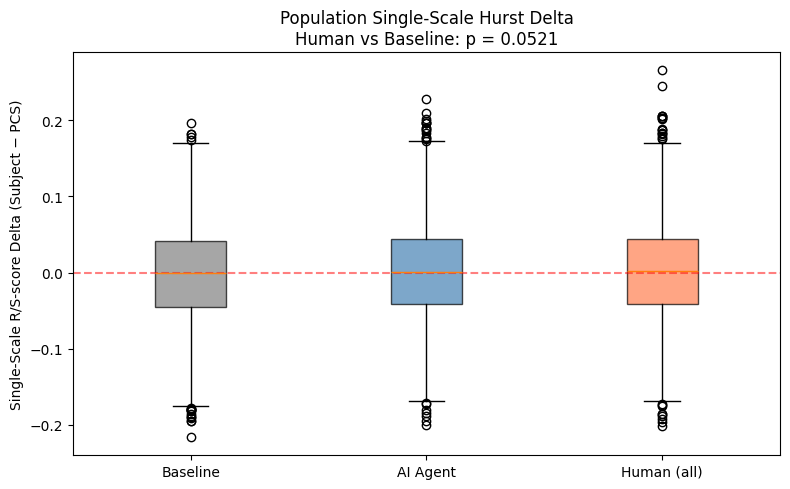


DESCRIPTIVE SUMMARY:
  Human-all minus Baseline block-level mean comparison: p=0.0521.
  These block-level t/KS calculations do not account for participant/session
  clustering and are descriptive only. They neither establish a population null
  nor show dilution by single-session participants.



In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Show no population-level difference in single-scale Hurst delta between
#          humans and baseline when all participants are pooled.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("="*70)
print("ANALYSIS SECTION")
print("="*70)
print("""
Same logic as the named analysis section (hit rates), but for the single-scale Hurst delta.
Pooling all humans against baseline should show no difference.
""")

print("-"*60)
print("Single-Scale Hurst Delta by Condition")
print("-"*60)

print(f"\n{'Condition':<15} {'N':>6} {'Mean Δ Hurst':>15} {'SD':>10} {'SE':>10}")
print("-"*60)
for cond in ['baseline', 'ai_agent', 'human']:
    sub = df_hurst[df_hurst['condition'] == cond]['delta_hurst'].dropna()
    print(f"  {cond:<13} {len(sub):>6} {sub.mean():>+15.6f} {sub.std():>10.6f} {sub.sem():>10.6f}")

base_h = df_hurst[df_hurst['condition'] == 'baseline']['delta_hurst'].dropna()
human_h = df_hurst[df_hurst['condition'] == 'human']['delta_hurst'].dropna()
ai_h = df_hurst[df_hurst['condition'] == 'ai_agent']['delta_hurst'].dropna()

t_hb, p_hb = stats.ttest_ind(human_h, base_h)
ks_hb = stats.ks_2samp(human_h, base_h)

print(f"\nHuman vs Baseline:")
print(f"  t-test:  t={t_hb:+.3f}, p={p_hb:.4f}")
print(f"  KS test: D={ks_hb.statistic:.4f}, p={ks_hb.pvalue:.4f}")

# By strata
print(f"\n{'Single-Scale Hurst Delta by Session Strata':^50}")
print("-"*50)
for label, low, high in [('1 session', 1, 1), ('2-4 sessions', 2, 4), ('5+ sessions', 5, 999)]:
    sub = df_hurst[(df_hurst['condition'] == 'human') &
                   (df_hurst['session_count'] >= low) &
                   (df_hurst['session_count'] <= high)]['delta_hurst'].dropna()
    if len(sub) > 0:
        ks = stats.ks_2samp(sub, base_h)
        print(f"  {label:<15} N={len(sub):>5}  mean={sub.mean():>+.6f}  KS p={ks.pvalue:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
bp = ax.boxplot([base_h.values, ai_h.values, human_h.values],
                labels=['Baseline', 'AI Agent', 'Human (all)'], patch_artist=True)
for box, color in zip(bp['boxes'], ['gray', 'steelblue', 'coral']):
    box.set_facecolor(color)
    box.set_alpha(0.7)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_ylabel('Single-Scale R/S-score Delta (Subject − PCS)')
ax.set_title(f'Population Single-Scale Hurst Delta\nHuman vs Baseline: p = {p_hb:.4f}')
plt.tight_layout()
plt.show()

print(f"""
DESCRIPTIVE SUMMARY:
  Human-all minus Baseline block-level mean comparison: p={p_hb:.4f}.
  These block-level t/KS calculations do not account for participant/session
  clustering and are descriptive only. They neither establish a population null
  nor show dilution by single-session participants.
""")


# Single-Scale Hurst — Power Users (5+ Sessions)

**Paper section: 3.6.2 (Session-Count Pattern) and 3.6.6**

The core temporal-structure finding. Experienced human participants (5+ sessions) show the
largest distributional separation in single-scale Hurst delta from Baseline. Single-session
humans and AI do not show this separation. This is a worked example of interpretation — treated
throughout this notebook as a screening flag surfaced by an exploratory, retroactive analysis, not
as confirmed evidence of an effect (see Section 3.6.6 and the Summary & Limitations cell below).


ANALYSIS SECTION

The single-scale Hurst delta (subject − PCS) for participants with 5+
sessions (3 participants, ~840 blocks) shows the largest distributional
separation from baseline (KS p = 0.040) of any session-count stratum.
This is treated as a screening flag. It is the strongest of three
NESTED session-count thresholds (2+, 3+, 5+) examined after a null
result in the full sample, and a Holm-Bonferroni correction across
those three thresholds leaves none significant at alpha=0.05 (the named analysis section). Cells 12-14 do not provide independent corroboration of this
pattern: the shuffle test (the named analysis section) characterizes the estimator's own
sensitivity to bit ordering, not the group difference, and the label-
swap test (the named analysis section) is mathematically a sign-flip on the same paired-
difference statistic tested here. Both re-examine the same data from a
different angle rather than supplying separate evidence.
Single-session humans and AI do not show t

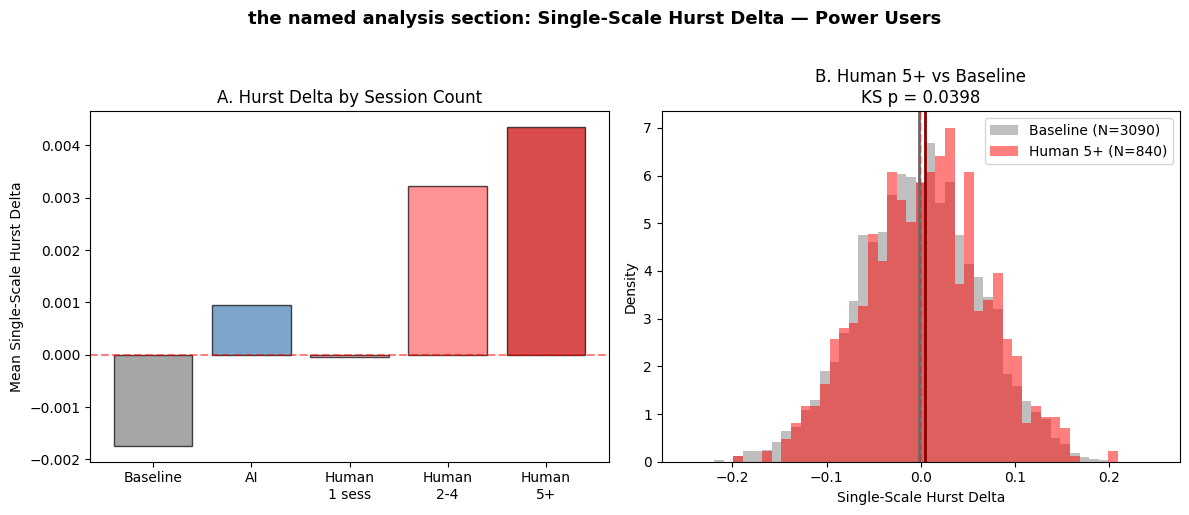


ANALYSIS SUMMARY:
  Single-scale Hurst delta, mean by session count:
    1 session:    near baseline
    2-4 sessions: slightly elevated
    5+ sessions:  +0.004349 (KS p=0.0398, d=+0.0950)

  AI and single-session humans do not show this separation from baseline.
  See IMPORTANT LIMITATIONS below — the session-count pattern is
  confounded with recruitment source.

  IMPORTANT LIMITATIONS:
    - The 5+ session subgroup = 3 participants, ~840 blocks.
      Block-level statistics are valid but N(participants) is very small.
    - This is the strongest of three nested session-count thresholds
      (2+, 3+, 5+); a Holm-Bonferroni correction across them leaves
      none significant at alpha=0.05 (the named analysis section). Reporting the
      strongest of several nested strata is a form of conditioning on
      the outcome.
    - The session-count pattern is confounded with recruitment source:
      5+ participants are predominantly remote viewing practitioners,
      while single-ses

In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: The core temporal-structure finding. Experienced human
#          participants (5+ sessions) show the largest distributional
#          separation in single-scale Hurst delta from baseline. Single-
#          session humans and AI do not show this separation.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("="*70)
print("ANALYSIS SECTION")
print("="*70)
print("""
The single-scale Hurst delta (subject − PCS) for participants with 5+
sessions (3 participants, ~840 blocks) shows the largest distributional
separation from baseline (KS p = 0.040) of any session-count stratum.
This is treated as a screening flag. It is the strongest of three
NESTED session-count thresholds (2+, 3+, 5+) examined after a null
result in the full sample, and a Holm-Bonferroni correction across
those three thresholds leaves none significant at alpha=0.05 (the named analysis section). Cells 12-14 do not provide independent corroboration of this
pattern: the shuffle test (the named analysis section) characterizes the estimator's own
sensitivity to bit ordering, not the group difference, and the label-
swap test (the named analysis section) is mathematically a sign-flip on the same paired-
difference statistic tested here. Both re-examine the same data from a
different angle rather than supplying separate evidence.
Single-session humans and AI do not show this separation.

The mean delta increases monotonically across the 1 / 2-4 / 5+ session
strata, but this pattern is confounded with recruitment source (5+
participants are predominantly remote viewing practitioners;
single-session participants are from a survey-exchange platform).
Whether this reflects a population difference or self-selection
(participants with a pre-existing trait return for more sessions)
cannot be determined from these data.
""")

# ─────────────────────────────────────────────────────────────
# PART 1: Dose-Response Table
# ─────────────────────────────────────────────────────────────
print("-"*60)
print("PART 1: Single-Scale Hurst Delta by Session Count")
print("-"*60)

base_delta = df_hurst[df_hurst['condition'] == 'baseline']['delta_hurst'].dropna()

print(f"\n{'Group':<20} {'N':>6} {'Mean Δ':>12} {'SD':>10} {'KS D':>8} {'KS p':>10}")
print("-"*70)

# Baseline reference
print(f"  {'Baseline':<18} {len(base_delta):>6} {base_delta.mean():>+12.6f} {base_delta.std():>10.4f} {'—':>8} {'—':>10}")

# AI
ai_delta = df_hurst[df_hurst['condition'] == 'ai_agent']['delta_hurst'].dropna()
ks_ai = stats.ks_2samp(ai_delta, base_delta)
print(f"  {'AI Agent':<18} {len(ai_delta):>6} {ai_delta.mean():>+12.6f} {ai_delta.std():>10.4f} {ks_ai.statistic:>8.4f} {ks_ai.pvalue:>10.4f}")

# Human strata (non-overlapping)
strata = [
    ('Human (1 sess)', 1, 1),
    ('Human (2-4 sess)', 2, 4),
    ('Human (5+ sess)', 5, 999),
]
for label, low, high in strata:
    sub = df_hurst[(df_hurst['condition'] == 'human') &
                   (df_hurst['session_count'] >= low) &
                   (df_hurst['session_count'] <= high)]['delta_hurst'].dropna()
    if len(sub) >= 10:
        ks = stats.ks_2samp(sub, base_delta)
        sig = " *" if ks.pvalue < 0.05 else ""
        print(f"  {label:<18} {len(sub):>6} {sub.mean():>+12.6f} {sub.std():>10.4f} {ks.statistic:>8.4f} {ks.pvalue:>10.4f}{sig}")
    elif len(sub) > 0:
        print(f"  {label:<18} {len(sub):>6} {sub.mean():>+12.6f} {sub.std():>10.4f} {'(too few)':>20}")

# ─────────────────────────────────────────────────────────────
# PART 2: Detailed 5+ Session Analysis
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 2: Human 5+ Sessions — Detailed")
print("-"*60)

h5_delta = df_hurst[(df_hurst['condition'] == 'human') &
                    (df_hurst['session_count'] >= 5)]['delta_hurst'].dropna()

print(f"\n  N blocks:        {len(h5_delta)}")
print(f"  N participants:  {df_hurst[(df_hurst['condition']=='human') & (df_hurst['session_count']>=5)]['participant_id'].nunique()}")
print(f"  Mean delta:      {h5_delta.mean():+.6f}")
print(f"  SD:              {h5_delta.std():.6f}")
print(f"  SE:              {h5_delta.sem():.6f}")

# Effect size (Cohen's d vs baseline)
pooled_sd = np.sqrt(((len(h5_delta)-1)*h5_delta.var() + (len(base_delta)-1)*base_delta.var()) /
                    (len(h5_delta) + len(base_delta) - 2))
d = (h5_delta.mean() - base_delta.mean()) / pooled_sd if pooled_sd > 0 else 0
print(f"  Cohen's d:       {d:+.4f}")

# KS test
ks = stats.ks_2samp(h5_delta, base_delta)
print(f"  KS D:            {ks.statistic:.4f}")
print(f"  KS p:            {ks.pvalue:.4f}")

# t-test
t, p = stats.ttest_ind(h5_delta, base_delta)
print(f"  t-test:          t={t:+.3f}, p={p:.4f}")

# One-sample vs 0
t0, p0 = stats.ttest_1samp(h5_delta, 0)
print(f"  vs zero:         t={t0:+.3f}, p={p0:.4f}")

# ─────────────────────────────────────────────────────────────
# PART 3: Also report subject-only Hurst (not delta)
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 3: Subject Single-Scale Hurst (not delta, for comparison)")
print("-"*60)

base_subj = df_hurst[df_hurst['condition'] == 'baseline']['hurst_subject'].dropna()
h5_subj = df_hurst[(df_hurst['condition'] == 'human') &
                   (df_hurst['session_count'] >= 5)]['hurst_subject'].dropna()

ks_subj = stats.ks_2samp(h5_subj, base_subj)
print(f"\n  Subject Hurst (raw, not delta):")
print(f"    Baseline mean:   {base_subj.mean():.6f}")
print(f"    Human 5+ mean:   {h5_subj.mean():.6f}")
print(f"    KS D={ks_subj.statistic:.4f}, p={ks_subj.pvalue:.4f}")
print(f"\n  The subject-only Hurst and the delta both differ from baseline by similar margins.")
print(f"  See the named analysis section for the shuffle test on the delta.")

# ─────────────────────────────────────────────────────────────
# Visualization
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Dose-response
ax1 = axes[0]
groups = ['Baseline', 'AI', 'Human\n1 sess', 'Human\n2-4', 'Human\n5+']
means = [base_delta.mean()]
means.append(ai_delta.mean())
for low, high in [(1,1), (2,4), (5,999)]:
    sub = df_hurst[(df_hurst['condition'] == 'human') &
                   (df_hurst['session_count'] >= low) &
                   (df_hurst['session_count'] <= high)]['delta_hurst'].dropna()
    means.append(sub.mean() if len(sub) > 0 else 0)
colors = ['gray', 'steelblue', '#ffaaaa', '#ff6666', '#cc0000']
bars = ax1.bar(groups, means, color=colors, alpha=0.7, edgecolor='black')
ax1.axhline(0, color='red', linestyle='--', alpha=0.5)
ax1.set_ylabel('Mean Single-Scale Hurst Delta')
ax1.set_title('A. Hurst Delta by Session Count')

# Panel B: Distribution comparison (5+ vs baseline)
ax2 = axes[1]
bins = np.linspace(-0.25, 0.25, 50)
ax2.hist(base_delta, bins=bins, alpha=0.5, label=f'Baseline (N={len(base_delta)})',
         color='gray', density=True)
ax2.hist(h5_delta, bins=bins, alpha=0.5, label=f'Human 5+ (N={len(h5_delta)})',
         color='red', density=True)
ax2.axvline(base_delta.mean(), color='dimgray', linewidth=2)
ax2.axvline(h5_delta.mean(), color='darkred', linewidth=2)
ax2.axvline(0, color='red', linestyle='--', alpha=0.3)
ax2.set_xlabel('Single-Scale Hurst Delta')
ax2.set_ylabel('Density')
ax2.set_title(f'B. Human 5+ vs Baseline\nKS p = {ks.pvalue:.4f}')
ax2.legend()

plt.suptitle('the named analysis section: Single-Scale Hurst Delta — Power Users', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

n_participants_5plus = df_hurst[(df_hurst['condition'] == 'human') &
                                (df_hurst['session_count'] >= 5)]['participant_id'].nunique()

print(f"""
ANALYSIS SUMMARY:
  Single-scale Hurst delta, mean by session count:
    1 session:    near baseline
    2-4 sessions: slightly elevated
    5+ sessions:  {h5_delta.mean():+.6f} (KS p={ks.pvalue:.4f}, d={d:+.4f})

  AI and single-session humans do not show this separation from baseline.
  See IMPORTANT LIMITATIONS below — the session-count pattern is
  confounded with recruitment source.

  IMPORTANT LIMITATIONS:
    - The 5+ session subgroup = {n_participants_5plus} participants, ~{len(h5_delta)} blocks.
      Block-level statistics are valid but N(participants) is very small.
    - This is the strongest of three nested session-count thresholds
      (2+, 3+, 5+); a Holm-Bonferroni correction across them leaves
      none significant at alpha=0.05 (the named analysis section). Reporting the
      strongest of several nested strata is a form of conditioning on
      the outcome.
    - The session-count pattern is confounded with recruitment source:
      5+ participants are predominantly remote viewing practitioners,
      while single-session participants are from a survey-exchange
      platform. This cannot be interpreted as a learning effect.
    - Effect size is small (d={d:+.4f}).
    - the named analysis section tests whether the result is driven by a single participant
      (leave-one-out robustness check across all 3 participants).

  Cells 12 and 14 re-examine this same data from different angles
  (order-sensitivity, label-sensitivity) -- they are diagnostics on the
  estimator and the statistic, not independent replications. See those
  cells' own summaries for what each actually establishes. Per the
  Paired-Delta Protocol Methodology paper (Section 3.6.6), this result
  is presented as a worked example of the interpretive reasoning the
  architecture requires, not as evidence of an effect.
""")


### Whole-Call Average Hurst (H_avg) — A Third, Independent Test Alongside H0a/H0b

**Paper section: 3.6.4 (Direct-Stream and Paired-Delta Convergence)**

The core finding above runs two tests on the same data: the paired delta `delta_hurst` =
H_subject − H_PCS (**H0a**), and the direct subject stream `hurst_subject` alone (**H0b**).
Neither is built to detect a **whole-call** effect — something that shifts both streams together
rather than favoring one over the other:

- **H0a cancels it by construction.** If observation shifts H_subject and H_PCS by the same amount
  in the same direction, the paired difference is unchanged — H0a is structurally blind to exactly
  this pattern, not just under-powered for it.
- **H0b is not blind to it, but conflates it.** A shift in H_subject alone could be a whole-call
  effect (PCS would have shifted too, cancelling in H0a) or a stream-specific effect (PCS
  unchanged). H0b can't tell these apart.

**H_avg = (H_subject + H_PCS) / 2** isolates the whole-call question directly: does the *average*
of the two streams differ between Human and Baseline, independent of any difference between the
streams? A whole-call effect should show up here (attenuated relative to a stream-specific effect,
since averaging two streams shrinks a shared shift less than it shrinks two independent noise
excursions that happen to partially cancel); a purely stream-specific effect should leave H_avg
statistically indistinguishable from Baseline even if H0a/H0b both show something.

Most theoretical accounts of observer effects in this literature predict whole-call effects
(something acting on the measurement/generation process as a whole, not selectively on one of two
streams drawn from the same underlying call) rather than stream-specific ones — H0a alone was
never a complete test of that class of hypothesis.


ANALYSIS SECTION

Cohort                 N    H0a (Δ) D       p    H0b (subj) D       p    H0c (avg) D       p   agree?
--------------------------------------------------------------------------------------------------------------
  AI Agent           3780       0.0227  0.3359          0.0252  0.2245         0.0174  0.6734   H0c matches H0a+H0b
  Human (all)        4737       0.0226  0.2884          0.0296  0.0736         0.0176  0.6030   H0c matches H0a+H0b
  Human (1 sess)     3327       0.0195  0.5648          0.0211  0.4659         0.0152  0.8430   H0c matches H0a+H0b
  Human (2-4 sess)    570       0.0463  0.2440          0.0545  0.1098         0.0389  0.4482   H0c matches H0a+H0b
  Human (5+ sess)     840       0.0541  0.0398          0.0575  0.0243         0.0279  0.6682   H0c disagrees with at least one

Reading the table: H0a = paired delta (the named analysis section Part 2), H0b = subject-only (the named analysis section Part 3), H0c =
this cell's new whole-call average. "ag

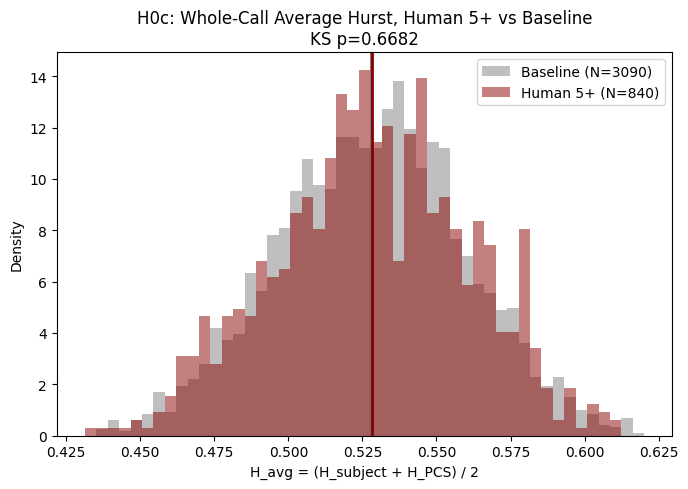

In [17]:
# ═══════════════════════════════════════════════════════════════════════════
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("="*70)
print("ANALYSIS SECTION")
print("="*70)

# H_avg from the existing hurstApprox-derived columns -- no reimplementation.
df_hurst['hurst_avg_rough'] = (df_hurst['hurst_subject'] + df_hurst['hurst_pcs']) / 2.0

base_delta_h11b = df_hurst[df_hurst['condition'] == 'baseline']['delta_hurst'].dropna()
base_subj_h11b  = df_hurst[df_hurst['condition'] == 'baseline']['hurst_subject'].dropna()
base_avg_h11b   = df_hurst[df_hurst['condition'] == 'baseline']['hurst_avg_rough'].dropna()

def cohort_df(condition, low=None, high=None):
    m = df_hurst['condition'] == condition
    if low is not None:
        m &= (df_hurst['session_count'] >= low) & (df_hurst['session_count'] <= high)
    return df_hurst[m]

cohorts = {
    'AI Agent':        cohort_df('ai_agent'),
    'Human (all)':      cohort_df('human'),
    'Human (1 sess)':   cohort_df('human', 1, 1),
    'Human (2-4 sess)': cohort_df('human', 2, 4),
    'Human (5+ sess)':  cohort_df('human', 5, 999),
}

print(f"\n{'Cohort':<18}{'N':>6}   {'H0a (Δ) D':>10}{'p':>8}   {'H0b (subj) D':>13}{'p':>8}   "
      f"{'H0c (avg) D':>12}{'p':>8}   agree?")
print("-"*110)

results_11b = {}
for label, sub in cohorts.items():
    delta = sub['delta_hurst'].dropna()
    subj  = sub['hurst_subject'].dropna()
    avg   = sub['hurst_avg_rough'].dropna()
    if len(delta) < 10:
        print(f"  {label:<16} {len(delta):>6}   (too few blocks)")
        continue
    ks_a = stats.ks_2samp(delta, base_delta_h11b)
    ks_b = stats.ks_2samp(subj, base_subj_h11b)
    ks_c = stats.ks_2samp(avg, base_avg_h11b)
    sig_a = ks_a.pvalue < 0.05
    sig_b = ks_b.pvalue < 0.05
    sig_c = ks_c.pvalue < 0.05
    agree = "H0c matches H0a+H0b" if (sig_a == sig_c and sig_b == sig_c) else \
            "H0c disagrees with at least one" if (sig_a or sig_b or sig_c) else "all null"
    results_11b[label] = dict(ks_a=ks_a, ks_b=ks_b, ks_c=ks_c, sub=sub)
    print(f"  {label:<16} {len(delta):>6}   {ks_a.statistic:>10.4f}{ks_a.pvalue:>8.4f}   "
          f"{ks_b.statistic:>13.4f}{ks_b.pvalue:>8.4f}   {ks_c.statistic:>12.4f}{ks_c.pvalue:>8.4f}   {agree}")

print(f"""
Reading the table: H0a = paired delta (the named analysis section Part 2), H0b = subject-only (the named analysis section Part 3), H0c =
this cell's new whole-call average. "agree?" flags whether H0c's significance verdict (p<0.05) at
this cohort matches both H0a and H0b's verdicts, disagrees with at least one, or all three are null.
""")

# Visualization: H_avg distribution, Human 5+ vs Baseline (the cohort H0a/H0b flag most strongly)
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
h5_avg = cohorts['Human (5+ sess)']['hurst_avg_rough'].dropna()
bins = np.linspace(base_avg_h11b.quantile(0.001), base_avg_h11b.quantile(0.999), 50)
ax.hist(base_avg_h11b, bins=bins, alpha=0.5, label=f'Baseline (N={len(base_avg_h11b)})', color='gray', density=True)
ax.hist(h5_avg, bins=bins, alpha=0.5, label=f'Human 5+ (N={len(h5_avg)})', color='darkred', density=True)
ax.axvline(base_avg_h11b.mean(), color='dimgray', linewidth=2)
ax.axvline(h5_avg.mean(), color='darkred', linewidth=2)
ax.set_xlabel('H_avg = (H_subject + H_PCS) / 2')
ax.set_ylabel('Density')
ax.set_title(f"H0c: Whole-Call Average Hurst, Human 5+ vs Baseline\n"
             f"KS p={results_11b['Human (5+ sess)']['ks_c'].pvalue:.4f}" if 'Human (5+ sess)' in results_11b else "H0c: H_avg")
ax.legend()
plt.tight_layout()
plt.show()


In [18]:
# ═══════════════════════════════════════════════════════════════════════════
# ═══════════════════════════════════════════════════════════════════════════
# Same design as the named analysis section's leave-one-out on the delta finding -- reused here for H_avg,
# conditional on whether H0c actually shows anything worth stress-testing for this cohort.

print("="*70)
print("ANALYSIS: Leave-One-Out on H_avg (Human 5+), conditional on the named analysis section's result")
print("="*70)

h5_result = results_11b.get('Human (5+ sess)')
LOO_THRESHOLD = 0.10  # run LOO if nominally significant OR marginal, same bar the named analysis section itself uses

if h5_result is None:
    print("Human 5+ H_avg cohort had too few blocks -- nothing to test.")
elif h5_result['ks_c'].pvalue >= LOO_THRESHOLD:
    print(f"H0c (H_avg) for Human 5+: KS p={h5_result['ks_c'].pvalue:.4f} -- not nominally significant "
          f"or marginal (threshold {LOO_THRESHOLD}). No leave-one-out check needed; nothing here to "
          f"be driven by a single participant.")
else:
    h5_all_avg = h5_result['sub']
    h5_participants_avg = h5_all_avg['participant_id'].unique()
    print(f"H0c (H_avg) for Human 5+: KS p={h5_result['ks_c'].pvalue:.4f} -- below the {LOO_THRESHOLD} "
          f"screening threshold. Running leave-one-out across the {len(h5_participants_avg)} "
          f"participants in this stratum, same design as the named analysis section.\n")

    print(f"{'PID':<15}{'Sessions':>10}{'Blocks':>8}{'Mean H_avg':>13}{'SD':>10}")
    print("-"*58)
    for pid in h5_participants_avg:
        pid_data = h5_all_avg[h5_all_avg['participant_id'] == pid]
        pid_avg = pid_data['hurst_avg_rough'].dropna()
        n_sess = pid_data['session_count'].iloc[0] if len(pid_data) > 0 else 0
        print(f"  {str(pid):<13}{n_sess:>10}{len(pid_avg):>8}{pid_avg.mean():>+13.6f}{pid_avg.std():>10.6f}")

    h5_avg_all = h5_all_avg['hurst_avg_rough'].dropna()
    ks_full = stats.ks_2samp(h5_avg_all, base_avg_h11b)
    print(f"\n  {'FULL GROUP':<13}{'':>10}{len(h5_avg_all):>8}{h5_avg_all.mean():>+13.6f}{h5_avg_all.std():>10.6f}")
    print(f"  vs baseline: KS D={ks_full.statistic:.4f}, KS p={ks_full.pvalue:.4f}")

    print("\n" + "-"*60)
    print("Leave-One-Out: Drop Each Participant, Re-Test H_avg vs Baseline")
    print("-"*60)
    print(f"\n{'Dropped':<15}{'Remaining':>10}{'Mean H_avg':>13}{'KS D':>8}{'KS p':>10}  Verdict")
    print("-"*70)
    verdict_full = "sig" if ks_full.pvalue < 0.05 else "marginal" if ks_full.pvalue < 0.10 else "n.s."
    print(f"{'(none—full)':<15}{len(h5_avg_all):>10}{h5_avg_all.mean():>+13.6f}"
          f"{ks_full.statistic:>8.4f}{ks_full.pvalue:>10.4f}  {verdict_full}")

    driven_by_one = False
    for pid in h5_participants_avg:
        remaining = h5_all_avg[h5_all_avg['participant_id'] != pid]['hurst_avg_rough'].dropna()
        if len(remaining) < 10:
            continue
        ks_loo = stats.ks_2samp(remaining, base_avg_h11b)
        verdict = "sig" if ks_loo.pvalue < 0.05 else "marginal" if ks_loo.pvalue < 0.10 else "n.s."
        if verdict == "n.s." and verdict_full != "n.s.":
            driven_by_one = True
        print(f"{'drop '+str(pid)[:9]:<15}{len(remaining):>10}{remaining.mean():>+13.6f}"
              f"{ks_loo.statistic:>8.4f}{ks_loo.pvalue:>10.4f}  {verdict}")

    print(f"\nANALYSIS RESULT: {'FLAG -- result collapses when a single participant is dropped, likely driven by one individual.' if driven_by_one else 'Survives dropping any single participant -- not driven by one individual (same read the named analysis section gives for the delta finding).'}")


ANALYSIS: Leave-One-Out on H_avg (Human 5+), conditional on the named analysis section's result
H0c (H_avg) for Human 5+: KS p=0.6682 -- not nominally significant or marginal (threshold 0.1). No leave-one-out check needed; nothing here to be driven by a single participant.


### Status: Exploratory / Retroactive, Not Confirmatory

Like every other post-hoc test in this notebook, H0c (whole-call average Hurst) is **exploratory
and retroactive** — it was not part of the original pre-registered analysis plan, and no
correction for multiple comparisons across H0a/H0b/H0c × 5 cohorts is applied here. A significant
or non-significant H0c result should be read as a screening signal for a future confirmatory test,
not as confirmed evidence on its own — the same standard this notebook applies to the shuffle
test, label-swap test, and session-structure resampling checks around the core finding.


# Single-Scale Hurst Delta — Shuffle Test

**Paper section: 3.6.3 (Shuffle Test: Metric Sensitivity to Within-Block Ordering)**

⏱ Long run time.


In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Test how much within-block temporal order is needed to produce
#          the observed Human 5+ vs Baseline separation in single-scale
#          Hurst delta (ΔH = H_subject - H_demon).
#
# LOGIC:
#   For each window size W, shuffle each block's 150 bits within
#   non-overlapping chunks of size W, recompute ΔH, and compute the KS-D
#   statistic between the Human 5+ and Baseline ΔH distributions.
#   Repeat N_SHUFFLES times per W and report the mean shuffled KS-D.
#
#   W=1   : no shuffle (order preserved) -> should reproduce reference D
#   W=150 : full within-block shuffle (all order destroyed)
#
#   This is a sensitivity check on the single-scale Hurst delta metric:
#   if the metric responds to within-block bit ordering, the mean KS-D
#   should change across shuffle windows. It is not used here to test
#   whether the Human 5+ vs Baseline difference itself depends on
#   ordering.
#
# ⏱ RUNTIME: ~10-20 minutes (200 shuffles x 7 window sizes x ~3,900 blocks)
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
from scipy.stats import ks_2samp
from numpy.random import default_rng

print("="*70)
print("ANALYSIS SECTION")
print("="*70)
print("""
Sensitivity check: does the single-scale Hurst delta metric respond to
within-block bit ordering? Shuffles bits within windows of increasing
size and reports the mean KS-D between Human 5+ and Baseline.
""")

rng = default_rng(42)
N_SHUFFLES = 200
WINDOWS = [1, 3, 5, 10, 25, 50, 150]

def paired_window_shuffle(subject_bits, pcs_bits, W, rng):
    """Apply one within-window positional permutation to both paired streams."""
    subject = np.asarray(subject_bits, dtype=int).copy()
    pcs = np.asarray(pcs_bits, dtype=int).copy()
    if subject.size != pcs.size:
        raise ValueError("Paired streams must have equal length.")
    for start in range(0, subject.size, W):
        end = min(start + W, subject.size)
        perm = rng.permutation(end - start)
        subject[start:end] = subject[start:end][perm]
        pcs[start:end] = pcs[start:end][perm]
    return subject, pcs

# Human 5+ and Baseline blocks with bits
human5_blocks = df_hurst[(df_hurst['condition'] == 'human') & (df_hurst['session_count'] >= 5)].copy()
base_blocks = df_hurst[df_hurst['condition'] == 'baseline'].copy()

human5_valid = human5_blocks[human5_blocks['subject_bits'].notna()].copy()
base_valid = base_blocks[base_blocks['subject_bits'].notna()].copy()

print(f"Human 5+ blocks: {len(human5_valid)}")
print(f"Baseline blocks: {len(base_valid)}")

# Reference KS D (unshuffled)
human5plus_ref_ks = ks_2samp(
    human5_valid['delta_hurst'].dropna(),
    base_valid['delta_hurst'].dropna()
)
print(f"\nReference KS D (Human 5+ vs Baseline, delta): {human5plus_ref_ks.statistic:.4f}, p={human5plus_ref_ks.pvalue:.4f}")

# Progressive shuffle test
print(f"\nProgressive shuffle results (Human 5+ vs Baseline, single-scale Hurst delta):")
print(f"  {'W':>5}  {'mean KS-D':>10}")
print("  " + "-"*18)

shuffle_table = []
for W in WINDOWS:
    Ds = np.empty(N_SHUFFLES)
    for s in range(N_SHUFFLES):
        h_delta_sh = np.array([hurstApprox(sb) - hurstApprox(pb) for sb, pb in (paired_window_shuffle(s, p, W, rng) for s, p in zip(human5_valid['subject_bits'], human5_valid['demon_bits']))])

        b_delta_sh = np.array([hurstApprox(sb) - hurstApprox(pb) for sb, pb in (paired_window_shuffle(s, p, W, rng) for s, p in zip(base_valid['subject_bits'], base_valid['demon_bits']))])

        ks_sh = ks_2samp(h_delta_sh[np.isfinite(h_delta_sh)], b_delta_sh[np.isfinite(b_delta_sh)])
        Ds[s] = ks_sh.statistic

    mean_ks = Ds.mean()
    shuffle_table.append({'window_W': W, 'mean_KS': mean_ks})
    print(f"  {W:>5}  {mean_ks:>10.4f}")

print(f"""
ANALYSIS SUMMARY:
  Human 5+ vs Baseline, single-scale Hurst delta -- mean KS-D by shuffle window:
    W=1   (unshuffled):   {shuffle_table[0]['mean_KS']:.4f} (reference KS D = {human5plus_ref_ks.statistic:.4f}, p = {human5plus_ref_ks.pvalue:.4f})
    W=150 (full shuffle): {shuffle_table[-1]['mean_KS']:.4f}

  This is a sensitivity check on the metric: if the single-scale Hurst
  delta were insensitive to within-block bit ordering, shuffling would
  not change the mean KS-D between the Human 5+ and Baseline distributions.
  See the table above for all tested window sizes.
""")

print('Scope: symmetric paired shuffling is a descriptive sensitivity curve; it is not a calibrated participant-level hypothesis test.')


ANALYSIS SECTION

Sensitivity check: does the single-scale Hurst delta metric respond to
within-block bit ordering? Shuffles bits within windows of increasing
size and reports the mean KS-D between Human 5+ and Baseline.

Human 5+ blocks: 840
Baseline blocks: 3090

Reference KS D (Human 5+ vs Baseline, delta): 0.0541, p=0.0398

Progressive shuffle results (Human 5+ vs Baseline, single-scale Hurst delta):
      W   mean KS-D
  ------------------
      1      0.0541
      3      0.0491
      5      0.0600
     10      0.0628
     25      0.0586
     50      0.0395
    150      0.0333

ANALYSIS SUMMARY:
  Human 5+ vs Baseline, single-scale Hurst delta -- mean KS-D by shuffle window:
    W=1   (unshuffled):   0.0541 (reference KS D = 0.0541, p = 0.0398)
    W=150 (full shuffle): 0.0333

  This is a sensitivity check on the metric: if the single-scale Hurst
  delta were insensitive to within-block bit ordering, shuffling would
  not change the mean KS-D between the Human 5+ and Baseline dis

# AI Control — Shuffle Test

**Paper section: 3.6.3**

⏱ Long run time.

ANALYSIS SECTION

Same progressive shuffle test as the named analysis section, but applied to AI vs Baseline,
for direct numeric comparison.

AI blocks:       3780
Baseline blocks: 3090

Reference KS D (AI vs Baseline, delta): 0.0227, p=0.3359

Progressive shuffle results (AI vs Baseline, single-scale Hurst delta):
      W   mean KS-D
  ------------------
      1      0.0227
      3      0.0235
      5      0.0226
     10      0.0211
     25      0.0196
     50      0.0216
    150      0.0215

ANALYSIS SUMMARY:
  AI vs Baseline, single-scale Hurst delta -- mean KS-D by shuffle window:
    W=1   (unshuffled):   0.0227 (reference KS D = 0.0227, p = 0.3359)
    W=150 (full shuffle): 0.0215

  For comparison, Human 5+ vs Baseline (the named analysis section):
    W=1   (unshuffled):   0.0541 (reference KS D = 0.0541, p = 0.0398)
    W=150 (full shuffle): 0.0333



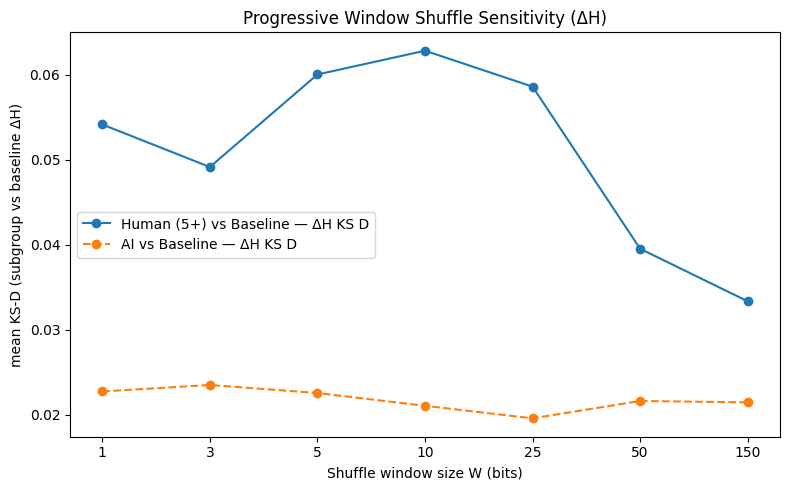

Scope: symmetric paired shuffling is a descriptive sensitivity curve; it is not a calibrated participant-level hypothesis test.


In [22]:
# ═══════════════════════════════════════════════════════════════════════════
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Apply the same progressive shuffle test to AI vs Baseline, for
#          direct comparison with the Human 5+ results from the named analysis section.
#
# ⏱ RUNTIME: ~10-20 minutes (200 shuffles x 7 window sizes x ~6,870 blocks)
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
from scipy.stats import ks_2samp
from numpy.random import default_rng

print("="*70)
print("ANALYSIS SECTION")
print("="*70)
print("""
Same progressive shuffle test as the named analysis section, but applied to AI vs Baseline,
for direct numeric comparison.
""")

rng = default_rng(42)
N_SHUFFLES = 200
WINDOWS = [1, 3, 5, 10, 25, 50, 150]

def paired_window_shuffle(subject_bits, pcs_bits, W, rng):
    """Apply one within-window positional permutation to both paired streams."""
    subject = np.asarray(subject_bits, dtype=int).copy()
    pcs = np.asarray(pcs_bits, dtype=int).copy()
    if subject.size != pcs.size:
        raise ValueError("Paired streams must have equal length.")
    for start in range(0, subject.size, W):
        end = min(start + W, subject.size)
        perm = rng.permutation(end - start)
        subject[start:end] = subject[start:end][perm]
        pcs[start:end] = pcs[start:end][perm]
    return subject, pcs

# AI and Baseline blocks with bits
ai_blocks = df_hurst[df_hurst['condition'] == 'ai_agent'].copy()
base_blocks = df_hurst[df_hurst['condition'] == 'baseline'].copy()

ai_valid = ai_blocks[ai_blocks['subject_bits'].notna()].copy()
base_valid = base_blocks[base_blocks['subject_bits'].notna()].copy()

print(f"AI blocks:       {len(ai_valid)}")
print(f"Baseline blocks: {len(base_valid)}")

# Reference KS D (unshuffled)
ai_ref_ks = ks_2samp(
    ai_valid['delta_hurst'].dropna(),
    base_valid['delta_hurst'].dropna()
)
print(f"\nReference KS D (AI vs Baseline, delta): {ai_ref_ks.statistic:.4f}, p={ai_ref_ks.pvalue:.4f}")

# Progressive shuffle test
print(f"\nProgressive shuffle results (AI vs Baseline, single-scale Hurst delta):")
print(f"  {'W':>5}  {'mean KS-D':>10}")
print("  " + "-"*18)

ai_shuffle_table = []
for W in WINDOWS:
    Ds = np.empty(N_SHUFFLES)
    for s in range(N_SHUFFLES):
        a_delta_sh = np.array([hurstApprox(sb) - hurstApprox(pb) for sb, pb in (paired_window_shuffle(s, p, W, rng) for s, p in zip(ai_valid['subject_bits'], ai_valid['demon_bits']))])

        b_delta_sh = np.array([hurstApprox(sb) - hurstApprox(pb) for sb, pb in (paired_window_shuffle(s, p, W, rng) for s, p in zip(base_valid['subject_bits'], base_valid['demon_bits']))])

        ks_sh = ks_2samp(a_delta_sh[np.isfinite(a_delta_sh)], b_delta_sh[np.isfinite(b_delta_sh)])
        Ds[s] = ks_sh.statistic

    mean_ks = Ds.mean()
    ai_shuffle_table.append({'window_W': W, 'mean_KS': mean_ks})
    print(f"  {W:>5}  {mean_ks:>10.4f}")

print(f"""
ANALYSIS SUMMARY:
  AI vs Baseline, single-scale Hurst delta -- mean KS-D by shuffle window:
    W=1   (unshuffled):   {ai_shuffle_table[0]['mean_KS']:.4f} (reference KS D = {ai_ref_ks.statistic:.4f}, p = {ai_ref_ks.pvalue:.4f})
    W=150 (full shuffle): {ai_shuffle_table[-1]['mean_KS']:.4f}

  For comparison, Human 5+ vs Baseline (the named analysis section):
    W=1   (unshuffled):   {shuffle_table[0]['mean_KS']:.4f} (reference KS D = {human5plus_ref_ks.statistic:.4f}, p = {human5plus_ref_ks.pvalue:.4f})
    W=150 (full shuffle): {shuffle_table[-1]['mean_KS']:.4f}
""")

# ─────────────────────────────────────────────────────────────
# VISUALIZATION: Human 5+ vs AI, mean KS-D by shuffle window
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
windows_x = [row['window_W'] for row in shuffle_table]
human_y = [row['mean_KS'] for row in shuffle_table]
ai_y = [row['mean_KS'] for row in ai_shuffle_table]
x_pos = range(len(windows_x))

ax.plot(x_pos, human_y, 'o-', color='tab:blue', label='Human (5+) vs Baseline — ΔH KS D')
ax.plot(x_pos, ai_y, 'o--', color='tab:orange', label='AI vs Baseline — ΔH KS D')
ax.set_xticks(list(x_pos))
ax.set_xticklabels([str(w) for w in windows_x])
ax.set_xlabel('Shuffle window size W (bits)')
ax.set_ylabel('mean KS-D (subgroup vs baseline ΔH)')
ax.set_title('Progressive Window Shuffle Sensitivity (ΔH)')
ax.legend()
plt.tight_layout()
plt.show()

print('Scope: symmetric paired shuffling is a descriptive sensitivity curve; it is not a calibrated participant-level hypothesis test.')


### Bounded Differential-Response Calibration of the R/S Ordering Score

**Paper section: 5.10 (estimator limitation)**

This calibration addresses a narrow unresolved question: when two 150-bit streams are generated with different known ordering parameters, does the measured Subject-minus-PCS R/S-score difference respond symmetrically when the parameter assignments are reversed?

Two deliberately limited generators are used: a Gaussian AR(1) process (short-range dependence) and fractional Gaussian noise (scale-dependent dependence). Each continuous realization is converted to a 150-bit stream by assigning ones to its highest-ranked values. The number of ones is sampled from the observed Human 5+ Subject or PCS margins, so the simulation reproduces the subgroup's asymmetric compositions while varying temporal ordering.

For each parameter pair, the calibration reports (a) the null composition offset when both streams have the same parameter, (b) the forward response when Subject receives the higher parameter, (c) the reverse response when PCS receives the higher parameter, and (d) the reversal defect: the average of the forward and reverse signed score differences. Exact antisymmetry would give a reversal defect of zero.

This is a **bounded sensitivity analysis**, not an estimator correction. The generators and parameter grid are illustrative and are not identified as the real QRNG process. The observed Human 5+ score difference is shown only as a reference magnitude. The calibration must not be inverted to estimate a latent true H, to subtract a bias correction from the observed result, or to claim that all possible estimator bias has been bounded.


In [24]:
# Bounded known-generator calibration for differential estimator response at n=150.
# This replaces the previous invalid conversion from a simulated generating-H
# slope to a purported true-H difference in the observed Human 5+ records.

import numpy as np
import pandas as pd

print("=" * 78)
print("BOUNDED DIFFERENTIAL-RESPONSE CALIBRATION: SINGLE-SCALE R/S SCORE")
print("=" * 78)

BOUNDED_CAL_SEED = 20260805
BOUNDED_CAL_REPS = 12_000
BOUNDED_CAL_N = 150


def _rs_score_batch_bcal(bit_matrix):
    """Exact vectorized counterpart of hurstApprox for n=150 binary rows."""
    bits = np.asarray(bit_matrix, dtype=np.int8)
    if bits.ndim != 2 or bits.shape[1] != BOUNDED_CAL_N:
        raise ValueError("Expected a two-dimensional matrix of 150-bit rows")
    x = np.where(bits != 0, 1.0, -1.0)
    centered = x - x.mean(axis=1, keepdims=True)
    cumulative = np.cumsum(centered, axis=1)
    maximum = np.maximum(0.0, cumulative.max(axis=1))
    minimum = np.minimum(0.0, cumulative.min(axis=1))
    spread = maximum - minimum
    s2 = np.square(centered).sum(axis=1)
    scale = np.where(s2 > 0, np.sqrt(s2 / BOUNDED_CAL_N), 1.0)
    ratio = np.divide(spread, scale, out=np.ones_like(spread), where=scale != 0)
    ratio = np.where(np.isfinite(ratio) & (ratio != 0), ratio, 1.0)
    score = np.log(ratio) / np.log(float(BOUNDED_CAL_N))
    score = np.where(np.isfinite(score), score, 0.5)
    return np.clip(score, 0.0, 1.0)


def _ar1_gaussian_bcal(n, parameter, n_reps, rng):
    """Stationary Gaussian AR(1), parameter = lag-1 correlation rho."""
    rho = float(parameter)
    if not -0.95 < rho < 0.95:
        raise ValueError("AR(1) rho must be inside (-0.95, 0.95)")
    innovations = rng.standard_normal((n_reps, n))
    out = np.empty_like(innovations)
    out[:, 0] = innovations[:, 0]
    innovation_sd = np.sqrt(1.0 - rho ** 2)
    for t in range(1, n):
        out[:, t] = rho * out[:, t - 1] + innovation_sd * innovations[:, t]
    return out


def _fgn_gaussian_bcal(n, parameter, n_reps, rng):
    """Davies-Harte fractional Gaussian noise, parameter = latent H."""
    H = float(parameter)
    if not 0.05 < H < 0.95:
        raise ValueError("fGn H must be inside (0.05, 0.95)")
    k = np.arange(n, dtype=float)
    gamma = 0.5 * (
        np.abs(k + 1.0) ** (2.0 * H)
        - 2.0 * np.abs(k) ** (2.0 * H)
        + np.abs(k - 1.0) ** (2.0 * H)
    )
    circulant_row = np.concatenate([gamma, gamma[-2:0:-1]])
    eigenvalues = np.fft.fft(circulant_row).real
    if eigenvalues.min() < -1e-8:
        raise RuntimeError("Davies-Harte embedding produced materially negative eigenvalues")
    eigenvalues = np.maximum(eigenvalues, 0.0)
    m = len(circulant_row)
    real = rng.standard_normal((n_reps, m))
    imag = rng.standard_normal((n_reps, m))
    noise = (real + 1j * imag) * np.sqrt(eigenvalues / m)[None, :]
    return np.fft.fft(noise, axis=1)[:, :n].real


def _rank_binarize_exact_margins_bcal(values, one_counts):
    """Assign exactly k ones per row while preserving the generator's rank order."""
    values = np.asarray(values, dtype=float)
    counts = np.asarray(one_counts, dtype=int)
    rows, n = values.shape
    if counts.shape != (rows,) or np.any((counts < 0) | (counts > n)):
        raise ValueError("Invalid row-specific one counts")
    order = np.argsort(values, axis=1)
    ranks = np.empty_like(order)
    ranks[np.arange(rows)[:, None], order] = np.arange(n)[None, :]
    return (ranks >= (n - counts)[:, None]).astype(np.int8)


h5_bcal = df.loc[
    df["condition"].eq("human") & df["session_count"].ge(5),
    ["subject_bits", "demon_bits", "rs_subject", "rs_pcs"],
].dropna().copy()
if h5_bcal.empty:
    raise RuntimeError("No Human 5+ records available for bounded calibration")

subject_margins_bcal = h5_bcal["subject_bits"].apply(
    lambda bits: int(np.asarray(bits, dtype=np.int8).sum())
).to_numpy()
pcs_margins_bcal = h5_bcal["demon_bits"].apply(
    lambda bits: int(np.asarray(bits, dtype=np.int8).sum())
).to_numpy()
observed_h5_delta_bcal = float((h5_bcal["rs_subject"] - h5_bcal["rs_pcs"]).mean())

generator_specs_bcal = {
    "Gaussian AR(1)": {
        "function": _ar1_gaussian_bcal,
        "parameter": "rho",
        "pairs": [(-0.10, 0.00), (0.00, 0.05), (0.00, 0.10), (0.00, 0.20)],
    },
    "fractional Gaussian noise": {
        "function": _fgn_gaussian_bcal,
        "parameter": "latent H",
        "pairs": [(0.40, 0.50), (0.45, 0.50), (0.50, 0.55), (0.50, 0.60)],
    },
}


def _simulate_delta_bcal(generator, subject_parameter, pcs_parameter, rng):
    subject_counts = rng.choice(subject_margins_bcal, size=BOUNDED_CAL_REPS, replace=True)
    pcs_counts = rng.choice(pcs_margins_bcal, size=BOUNDED_CAL_REPS, replace=True)
    subject_latent = generator(
        BOUNDED_CAL_N, subject_parameter, BOUNDED_CAL_REPS, rng
    )
    pcs_latent = generator(
        BOUNDED_CAL_N, pcs_parameter, BOUNDED_CAL_REPS, rng
    )
    subject_bits = _rank_binarize_exact_margins_bcal(subject_latent, subject_counts)
    pcs_bits = _rank_binarize_exact_margins_bcal(pcs_latent, pcs_counts)
    return _rs_score_batch_bcal(subject_bits) - _rs_score_batch_bcal(pcs_bits)


rng_bcal = np.random.default_rng(BOUNDED_CAL_SEED)
bounded_calibration_rows = []
for generator_name, spec in generator_specs_bcal.items():
    generator = spec["function"]
    parameter_name = spec["parameter"]
    for low, high in spec["pairs"]:
        midpoint = (low + high) / 2.0
        null_delta = _simulate_delta_bcal(generator, midpoint, midpoint, rng_bcal)
        forward_delta = _simulate_delta_bcal(generator, high, low, rng_bcal)
        reverse_delta = _simulate_delta_bcal(generator, low, high, rng_bcal)
        null_mean = float(null_delta.mean())
        forward_mean = float(forward_delta.mean())
        reverse_mean = float(reverse_delta.mean())
        reversal_defect = (forward_mean + reverse_mean) / 2.0
        forward_mcse = float(forward_delta.std(ddof=1) / np.sqrt(BOUNDED_CAL_REPS))
        reverse_mcse = float(reverse_delta.std(ddof=1) / np.sqrt(BOUNDED_CAL_REPS))
        defect_mcse = float(np.sqrt(forward_mcse ** 2 + reverse_mcse ** 2) / 2.0)
        bounded_calibration_rows.append({
            "Generator": generator_name,
            "Parameter": parameter_name,
            "Low": low,
            "High": high,
            "Gap": high - low,
            "Null composition offset": null_mean,
            "Forward mean delta": forward_mean,
            "Reverse mean delta": reverse_mean,
            "Reversal defect": reversal_defect,
            "Defect MCSE": defect_mcse,
            "Defect CI low": reversal_defect - 1.96 * defect_mcse,
            "Defect CI high": reversal_defect + 1.96 * defect_mcse,
        })

bounded_estimator_calibration = pd.DataFrame(bounded_calibration_rows)
display_cols_bcal = [
    "Generator", "Parameter", "Low", "High", "Gap",
    "Null composition offset", "Forward mean delta", "Reverse mean delta",
    "Reversal defect", "Defect MCSE", "Defect CI low", "Defect CI high",
]
print("\nKnown-generator response, conditional on sampled Human 5+ margins:")
print(
    bounded_estimator_calibration[display_cols_bcal].to_string(
        index=False,
        formatters={column: "{:+.6f}".format for column in display_cols_bcal[2:]},
    )
)

max_null_offset_bcal = float(
    bounded_estimator_calibration["Null composition offset"].abs().max()
)
max_reversal_defect_bcal = float(
    bounded_estimator_calibration["Reversal defect"].abs().max()
)
max_pointwise_endpoint_bcal = float(np.maximum(
    bounded_estimator_calibration["Defect CI low"].abs(),
    bounded_estimator_calibration["Defect CI high"].abs(),
).max())

print(f"""
Observed Human 5+ mean paired R/S-score difference (reference only):
  {observed_h5_delta_bcal:+.6f}

Across this bounded grid:
  largest absolute same-parameter composition offset: {max_null_offset_bcal:.6f}
  largest absolute forward/reverse reversal defect:    {max_reversal_defect_bcal:.6f}
  largest absolute pointwise 95% CI endpoint:          {max_pointwise_endpoint_bcal:.6f}

Interpretation:
  The score's measured response is generator- and parameter-dependent. Within this
  bounded grid, every pointwise 95% interval for the forward/reverse reversal defect
  includes zero, so no differential directional distortion was resolved beyond Monte
  Carlo uncertainty. The intervals constrain such a defect only for the generators,
  grid, n=150 implementation, and sampled Human 5+ margins shown above. They do not
  identify the real QRNG generator, provide a correction to the observed value, estimate
  a true H difference, or bound every possible estimator bias.
""")


BOUNDED DIFFERENTIAL-RESPONSE CALIBRATION: SINGLE-SCALE R/S SCORE

Known-generator response, conditional on sampled Human 5+ margins:
                Generator Parameter       Low      High       Gap Null composition offset Forward mean delta Reverse mean delta Reversal defect Defect MCSE Defect CI low Defect CI high
           Gaussian AR(1)       rho -0.100000 +0.000000 +0.100000               +0.000301          +0.011413          -0.009982       +0.000715   +0.000413     -0.000093      +0.001524
           Gaussian AR(1)       rho +0.000000 +0.050000 +0.050000               +0.000426          +0.004903          -0.006303       -0.000700   +0.000412     -0.001508      +0.000108
           Gaussian AR(1)       rho +0.000000 +0.100000 +0.100000               +0.000359          +0.012225          -0.012038       +0.000093   +0.000415     -0.000720      +0.000906
           Gaussian AR(1)       rho +0.000000 +0.200000 +0.200000               -0.000439          +0.025114          -0.02466

### DFA Cross-Check — Does the Human5+ Pattern Replicate Under a Bias-Flatter Estimator?

**Paper section: 5.10**

The cell above shows the single-scale R/S Hurst estimator's finite-sample bias depends on the true
underlying H, not just block length. Detrended Fluctuation Analysis (DFA) is a differently biased
estimator of the same ordering-structure property — if the core finding were purely an artifact of
R/S's specific bias-vs-H shape, an estimator with a different bias shape should not reproduce it.
If it reproduces the same pattern (even if weaker), that's evidence against a *pure* R/S-bias
explanation, though not proof of a real effect on its own.


In [25]:
# ═══════════════════════════════════════════════════════════════════════════
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
from scipy import stats

print("="*70)
print("ANALYSIS SECTION")
print("="*70)

def dfa_batch(bit_matrix, scales):
    """DFA1 (linear detrending), vectorized. Same scale set already used
    elsewhere in this notebook for multi-scale R/S ([10,15,25,37,50,75])."""
    x = np.where(bit_matrix != 0, 1.0, -1.0)
    x = x - x.mean(axis=1, keepdims=True)
    profile = np.cumsum(x, axis=1)
    M, N = profile.shape
    F_cols, used_scales = [], []
    for s in scales:
        if s > N // 2:
            continue
        n_windows = N // s
        seg = profile[:, :n_windows * s].reshape(M, n_windows, s)
        t = np.arange(s, dtype=float)
        t_mean = t.mean(); t_c = t - t_mean; denom = (t_c ** 2).sum()
        y_mean = seg.mean(axis=2, keepdims=True)
        y_c = seg - y_mean
        b = (y_c * t_c).sum(axis=2) / denom
        a = y_mean[..., 0] - b * t_mean
        trend = a[..., None] + b[..., None] * t[None, None, :]
        resid = seg - trend
        mse = (resid ** 2).mean(axis=2)
        F_s = np.sqrt(mse.mean(axis=1))
        F_cols.append(F_s); used_scales.append(s)
    F_mat = np.array(F_cols).T
    log_s = np.log(np.array(used_scales, dtype=float))
    log_F = np.log(np.where(F_mat > 0, F_mat, np.nan))
    ls_mean = log_s.mean(); ls_c = log_s - ls_mean; denom2 = (ls_c ** 2).sum()
    lf_mean = np.nanmean(log_F, axis=1, keepdims=True)
    lf_c = log_F - lf_mean
    slope = np.nansum(lf_c * ls_c[None, :], axis=1) / denom2
    return slope

DFA_SCALES = [10, 15, 25, 37, 50, 75]

subj_matrix = np.array(df['subject_bits'].tolist(), dtype=np.int8)
pcs_matrix = np.array(df['demon_bits'].tolist(), dtype=np.int8)
print("Computing DFA exponent (subject, pcs) on every block...")
df['hurst_subj_dfa'] = dfa_batch(subj_matrix, DFA_SCALES)
df['hurst_pcs_dfa'] = dfa_batch(pcs_matrix, DFA_SCALES)
df['delta_dfa'] = df['hurst_subj_dfa'] - df['hurst_pcs_dfa']

base = df[df['condition'] == 'baseline']
human_all = df[df['condition'] == 'human']

print("\n" + "-"*70)
print("PART 1: Population-level null, Human(all) vs Baseline")
print("-"*70)
for label, col in [('R/S delta (the named analysis section)', 'delta_hurst'), ('DFA delta', 'delta_dfa')]:
    b = base[col].dropna(); h = human_all[col].dropna()
    ks = stats.ks_2samp(h, b)
    print(f"  {label:<20} KS p={ks.pvalue:.4f}")

print("\n" + "-"*70)
print("PART 2: Session-count strata, R/S vs DFA side by side")
print("-"*70)
strata = [('1 session', 1, 1), ('2-4 sessions', 2, 4), ('5+ sessions', 5, 999)]
for name, col in [('R/S', 'delta_hurst'), ('DFA', 'delta_dfa')]:
    print(f"  --- {name} ---")
    base_vals = base[col].dropna()
    for slabel, lo, hi in strata:
        sub = human_all[(human_all['session_count'] >= lo) & (human_all['session_count'] <= hi)][col].dropna()
        if len(sub) < 10:
            continue
        ks = stats.ks_2samp(sub, base_vals)
        pooled_sd = np.sqrt(((len(sub)-1)*sub.var() + (len(base_vals)-1)*base_vals.var()) / (len(sub)+len(base_vals)-2))
        d = (sub.mean() - base_vals.mean()) / pooled_sd if pooled_sd > 0 else 0.0
        print(f"    {slabel:<16} N={len(sub):>5}  mean={sub.mean():>+.6f}  KS p={ks.pvalue:.4f}  d={d:>+.4f}")

print("\n" + "-"*70)
print("PART 3: Holm-Bonferroni across nested 2+/3+/5+ thresholds, R/S vs DFA")
print("-"*70)
for name, col in [('R/S', 'delta_hurst'), ('DFA', 'delta_dfa')]:
    base_vals = base[col].dropna()
    ps = []
    for cp in [2, 3, 5]:
        sub = human_all[human_all['session_count'] >= cp][col].dropna()
        ps.append((cp, stats.ks_2samp(sub, base_vals).pvalue))
    ps.sort(key=lambda x: x[1])
    m = len(ps); n_survive = 0; stopped = False
    for rank, (cp, p) in enumerate(ps):
        thresh = 0.05 / (m - rank)
        ok = (not stopped) and (p < thresh)
        n_survive += int(ok)
        stopped = stopped or not ok
    print(f"  {name}: {n_survive} of {m} nested thresholds survive Holm-Bonferroni at alpha=0.05")

r_agree, p_agree = stats.pearsonr(df['delta_hurst'].dropna(), df.loc[df['delta_hurst'].notna(), 'delta_dfa'])
h5_rs = human_all[human_all['session_count'] >= 5]['delta_hurst'].dropna()
h5_dfa = human_all[human_all['session_count'] >= 5]['delta_dfa'].dropna()

print(f"""
ANALYSIS SUMMARY:
  Block-level agreement between estimators: r(delta_RS, delta_DFA) = {r_agree:+.4f} (p={p_agree:.2e})
  Human 5+ mean delta_RS:  {h5_rs.mean():+.6f}
  Human 5+ mean delta_DFA: {h5_dfa.mean():+.6f}

  Same direction under both estimators, moderately correlated at the block level, and
  the full-sample and Holm-Bonferroni conclusions are unchanged either way (nothing
  survives correction under either estimator). DFA's Human5+ signal is real-direction
  but weaker than R/S's -- consistent with either a real but weak effect that DFA has
  less power to detect, or partial R/S-specific bias contamination (the named analysis section). This
  test doesn't resolve which; it rules out neither, and doesn't independently confirm
  a real effect. See Section 5.10.
""")


ANALYSIS SECTION
Computing DFA exponent (subject, pcs) on every block...

----------------------------------------------------------------------
PART 1: Population-level null, Human(all) vs Baseline
----------------------------------------------------------------------
  R/S delta (the named analysis section) KS p=0.2884
  DFA delta            KS p=0.3327

----------------------------------------------------------------------
PART 2: Session-count strata, R/S vs DFA side by side
----------------------------------------------------------------------
  --- R/S ---
    1 session        N= 3327  mean=-0.000044  KS p=0.5648  d=+0.0266
    2-4 sessions     N=  570  mean=+0.003219  KS p=0.2440  d=+0.0774
    5+ sessions      N=  840  mean=+0.004349  KS p=0.0398  d=+0.0950
  --- DFA ---
    1 session        N= 3327  mean=-0.001394  KS p=0.4229  d=+0.0114
    2-4 sessions     N=  570  mean=-0.002279  KS p=0.8616  d=+0.0054
    5+ sessions      N=  840  mean=+0.006511  KS p=0.0874  d=+0.0650

--

# Label Swap Test (Observer-Dependent Invariance)

**Paper section: 3.6.4.2 (When the Divergence Is Bidirectional)**


ANALYSIS SECTION

Each block's 301 QRNG bits are split by a quantum coin flip into
"subject" and "demon" streams.

This test randomly reassigns the subject/demon labels and checks whether
the cohort-vs-baseline Hurst delta difference changes relative to this
label-swap null distribution.

We test each human stratum + AI as control.

Cohort sizes:
  Human (1 sess)  :  3327 blocks, 111 participants
  Human (2-4)     :   570 blocks,   7 participants
  Human (5+)      :   840 blocks,   3 participants
  AI Agent        :  3780 blocks
  Baseline        :  3090 blocks

────────────────────────────────────────────────────────────
  Label Swap: Human (1 sess) vs Baseline (5000 iterations)
────────────────────────────────────────────────────────────
  True-label delta (cohort):     -0.000044
  True-label delta (baseline):   -0.001741
  Difference:                    +0.001697
  t = 1.064,  p = 0.2872
  Subject stream vs baseline:    t=1.334, p=0.1821
  Demon stream vs baseline:      t=-0.155, p=

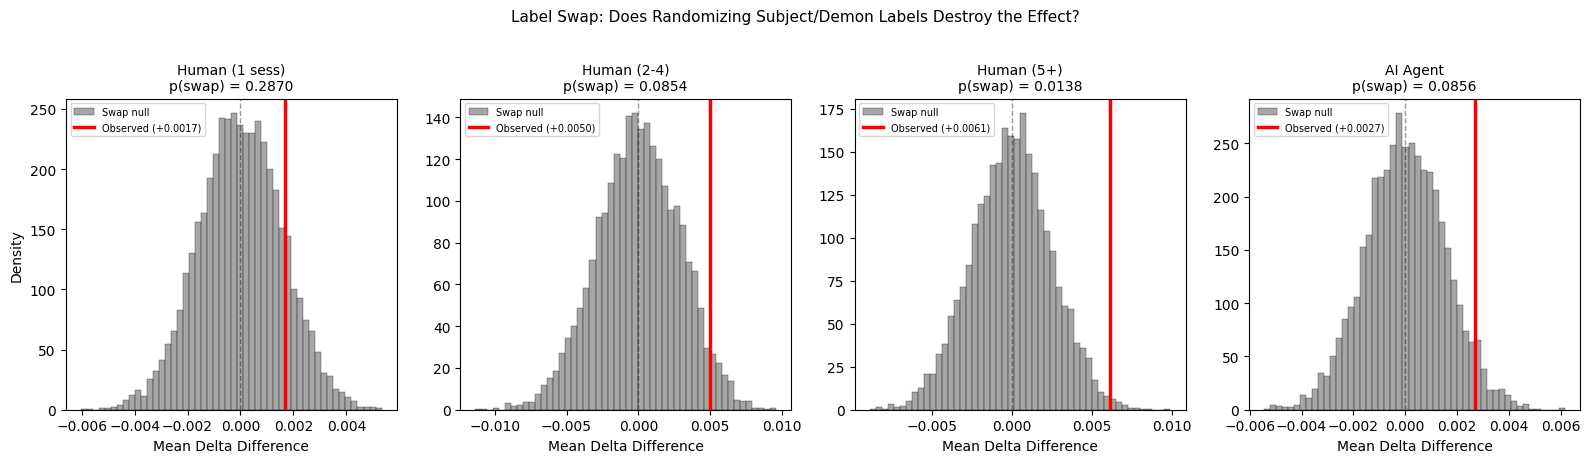

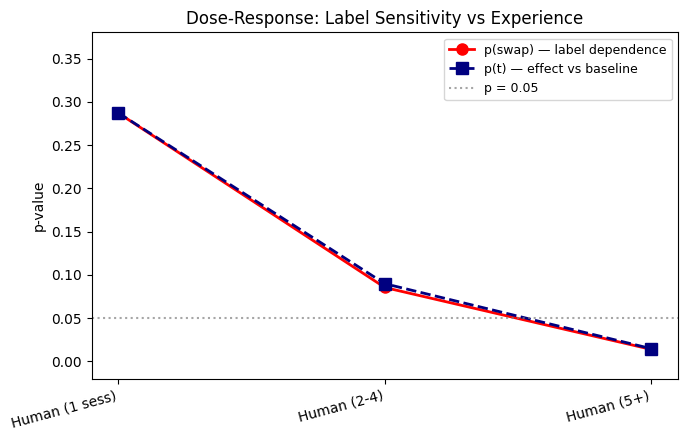


ANALYSIS SUMMARY:
  The label swap test randomly reassigns which stream is "subject" vs "demon"
  and checks whether the cohort-vs-baseline Hurst delta difference falls
  within the resulting null distribution.

  Human (5+) vs Baseline:
    Observed difference = +0.006090 (p(t) = 0.0147)
    p(swap) = 0.0138

  AI vs Baseline:
    Observed difference = +0.002684 (p(t) = 0.0837)
    p(swap) = 0.0856

  A low p(swap) means the observed difference is unusual relative to the
  label-swap null. As with the shuffle test (the named analysis section), this does not by
  itself establish whether any difference reflects an observer effect,
  a labeling artifact, or chance.

  Note on what this test does and does not add: p(swap) is mathematically
  a sign-flip permutation on the same paired-difference statistic tested
  in the named analysis section -- it is expected to match that t-test's p-value within Monte
  Carlo noise, and it does. This is the same data viewed from a different
  angle, n

In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Test whether the single-scale Hurst delta effect is coupled to the
#          observer's label assignment (subject vs demon), or could arise
#          from shared hardware/environmental factors.
#
# LOGIC:
#   Each block has TWO 150-bit streams from the SAME QRNG call (301 bits):
#     Bit 0        = quantum coin flip (assignment bit)
#     Bits 1-150   = halfA
#     Bits 151-300 = halfB
#     assignment=1 → subject=halfA, demon=halfB
#     assignment=0 → subject=halfB, demon=halfA
#
#   The QRNG hardware cannot distinguish subject from demon — the label
#   is assigned AFTER generation by a quantum coin flip.
#
#   hurst_delta = hurst_subject - hurst_demon
#
#   A label-independent (e.g. hardware/common-mode) difference would be
#   largely unaffected by randomly reassigning subject/demon labels:
#     -> p(swap) large, true-label difference falls within the swap null
#
#   A label-dependent difference would shrink toward the swap null when
#   labels are randomly reassigned:
#     -> p(swap) small, true-label difference is unusual relative to the
#        swap null
#
#   the named analysis section tests whether the difference depends on within-block bit
#   order (shuffle test). This cell tests whether it depends on which
#   stream is labeled "subject" vs "demon" (swap test). Together these
#   describe two properties of the observed group-level difference,
#   without establishing its cause.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from numpy.random import default_rng

print("="*70)
print("ANALYSIS SECTION")
print("="*70)
print("""
Each block's 301 QRNG bits are split by a quantum coin flip into
"subject" and "demon" streams.

This test randomly reassigns the subject/demon labels and checks whether
the cohort-vs-baseline Hurst delta difference changes relative to this
label-swap null distribution.

We test each human stratum + AI as control.
""")

rng = default_rng(42)
N_SWAP = 5000

# ─────────────────────────────────────────────────────────────
# Define cohorts (non-overlapping strata)
# ─────────────────────────────────────────────────────────────
baseline_blocks = df_hurst[df_hurst['condition'] == 'baseline'].copy()
ai_blocks = df_hurst[df_hurst['condition'] == 'ai_agent'].copy()

human_strata = {
    'Human (1 sess)': df_hurst[(df_hurst['condition'] == 'human') &
                               (df_hurst['session_count'] == 1)].copy(),
    'Human (2-4)':    df_hurst[(df_hurst['condition'] == 'human') &
                               (df_hurst['session_count'] >= 2) &
                               (df_hurst['session_count'] <= 4)].copy(),
    'Human (5+)':     df_hurst[(df_hurst['condition'] == 'human') &
                               (df_hurst['session_count'] >= 5)].copy(),
}

print("Cohort sizes:")
for name, grp in human_strata.items():
    print(f"  {name:<16}: {len(grp):>5} blocks, {grp['participant_id'].nunique():>3} participants")
print(f"  {'AI Agent':<16}: {len(ai_blocks):>5} blocks")
print(f"  {'Baseline':<16}: {len(baseline_blocks):>5} blocks")

# ─────────────────────────────────────────────────────────────
# Run label swap for each cohort
# ─────────────────────────────────────────────────────────────
# NOTE: hurst_subject and hurst_demon are aliases for single-scale Hurst
# values (hurst_subject, hurst_pcs) set in the named analysis section.

base_hurst_s = baseline_blocks['hurst_subject'].values
base_hurst_d = baseline_blocks['hurst_demon'].values

all_cohorts = dict(human_strata)
all_cohorts['AI Agent'] = ai_blocks

swap_results = {}

for cohort_name, cohort_df in all_cohorts.items():
    if len(cohort_df) < 10:
        print(f"\n  {cohort_name}: Too few blocks ({len(cohort_df)}), skipping.")
        continue

    print(f"\n{'─'*60}")
    print(f"  Label Swap: {cohort_name} vs Baseline ({N_SWAP} iterations)")
    print(f"{'─'*60}")

    coh_hurst_s = cohort_df['hurst_subject'].values
    coh_hurst_d = cohort_df['hurst_demon'].values

    # Observed effect with TRUE labels
    obs_delta_coh = (coh_hurst_s - coh_hurst_d).mean()
    obs_delta_base = (base_hurst_s - base_hurst_d).mean()
    obs_diff = obs_delta_coh - obs_delta_base

    obs_t, obs_t_p = stats.ttest_ind(
        coh_hurst_s - coh_hurst_d,
        base_hurst_s - base_hurst_d
    )

    # Per-stream tests
    t_subj, p_subj = stats.ttest_ind(coh_hurst_s, base_hurst_s)
    t_demon, p_demon = stats.ttest_ind(coh_hurst_d, base_hurst_d)

    print(f"  True-label delta (cohort):     {obs_delta_coh:+.6f}")
    print(f"  True-label delta (baseline):   {obs_delta_base:+.6f}")
    print(f"  Difference:                    {obs_diff:+.6f}")
    print(f"  t = {obs_t:.3f},  p = {obs_t_p:.4f}")
    print(f"  Subject stream vs baseline:    t={t_subj:.3f}, p={p_subj:.4f}")
    print(f"  Demon stream vs baseline:      t={t_demon:.3f}, p={p_demon:.4f}")

    # Run swap permutation
    swap_diffs = np.empty(N_SWAP)
    for i in range(N_SWAP):
        # Coin flip per block: swap subject/demon labels or keep
        coh_coins = rng.integers(0, 2, size=len(coh_hurst_s))
        coh_delta_swap = np.where(
            coh_coins == 1,
            coh_hurst_d - coh_hurst_s,   # SWAPPED
            coh_hurst_s - coh_hurst_d     # KEPT
        )
        base_coins = rng.integers(0, 2, size=len(base_hurst_s))
        base_delta_swap = np.where(
            base_coins == 1,
            base_hurst_d - base_hurst_s,
            base_hurst_s - base_hurst_d
        )
        swap_diffs[i] = coh_delta_swap.mean() - base_delta_swap.mean()

    p_swap = np.mean(np.abs(swap_diffs) >= abs(obs_diff))

    print(f"  Swap null mean:                {np.mean(swap_diffs):+.6f}")
    print(f"  Swap null SD:                  {np.std(swap_diffs):.6f}")
    print(f"  p(swap):                       {p_swap:.4f}")

    if p_swap < 0.05:
        verdict = "p(swap) < .05"
    elif p_swap < 0.10:
        verdict = "p(swap) < .10"
    else:
        verdict = "p(swap) >= .10"
    print(f"  → {verdict}")

    swap_results[cohort_name] = {
        'n_blocks': len(cohort_df),
        'n_participants': cohort_df['participant_id'].nunique(),
        'obs_diff': obs_diff,
        'obs_t': obs_t, 'obs_t_p': obs_t_p,
        'p_swap': p_swap,
        'swap_diffs': swap_diffs,
        'p_subj': p_subj, 'p_demon': p_demon,
        'verdict': verdict,
    }

# ─────────────────────────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("LABEL SWAP SUMMARY")
print("="*70)

print(f"\n{'Cohort':<16} {'N':>6} {'Ppl':>4} {'Obs Diff':>10} "
      f"{'p(t)':>8} {'p(swap)':>8} {'p(subj)':>8} {'p(demon)':>8}  {'Verdict'}")
print("─"*100)
for name in ['Human (1 sess)', 'Human (2-4)', 'Human (5+)', 'AI Agent']:
    if name not in swap_results:
        continue
    r = swap_results[name]
    print(f"{name:<16} {r['n_blocks']:>6} {r['n_participants']:>4} "
          f"{r['obs_diff']:>+10.5f} {r['obs_t_p']:>8.4f} "
          f"{r['p_swap']:>8.4f} {r['p_subj']:>8.4f} {r['p_demon']:>8.4f}  "
          f"{r['verdict']}")

print(f"\n{'Baseline':<16} {len(baseline_blocks):>6} "
      f"{baseline_blocks['participant_id'].nunique():>4} {'(reference)':>10}")

print("""
Reading this table:
  p(t)     = Does this cohort's Hurst delta differ from baseline? (t-test)
  p(swap)  = Does the observed cohort-vs-baseline difference fall within
             the distribution of differences produced by randomly
             reassigning subject/demon labels?
  p(subj)  = Is the SUBJECT stream alone different from baseline?
  p(demon) = Is the DEMON stream alone different from baseline?

  A low p(swap) means the true-label difference is unusual relative to
  the label-swap null. A low p(t) means the cohort differs from baseline
  under the true labels. Whether either reflects an observer effect, a
  labeling artifact, or chance cannot be determined from this test alone.
""")

# ─────────────────────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────────────────────
strata_to_plot = [k for k in ['Human (1 sess)', 'Human (2-4)', 'Human (5+)', 'AI Agent']
                  if k in swap_results]
n_panels = len(strata_to_plot)

fig, axes = plt.subplots(1, n_panels, figsize=(4*n_panels, 4.5))
if n_panels == 1:
    axes = [axes]

for ax, name in zip(axes, strata_to_plot):
    r = swap_results[name]
    ax.hist(r['swap_diffs'], bins=50, alpha=0.7, color='gray', edgecolor='black',
            density=True, linewidth=0.3, label='Swap null')
    ax.axvline(r['obs_diff'], color='red', linewidth=2.5,
               label=f'Observed ({r["obs_diff"]:+.4f})')
    ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.4)
    ax.set_xlabel('Mean Delta Difference')
    ax.set_title(f'{name}\np(swap) = {r["p_swap"]:.4f}', fontsize=10)
    ax.legend(fontsize=7)

axes[0].set_ylabel('Density')
fig.suptitle('Label Swap: Does Randomizing Subject/Demon Labels Destroy the Effect?',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# Dose-response plot: p(swap) across strata
# ─────────────────────────────────────────────────────────────
human_names = [k for k in ['Human (1 sess)', 'Human (2-4)', 'Human (5+)']
               if k in swap_results]
if len(human_names) >= 2:
    fig2, ax2 = plt.subplots(1, 1, figsize=(7, 4.5))
    swap_ps = [swap_results[k]['p_swap'] for k in human_names]
    effect_ps = [swap_results[k]['obs_t_p'] for k in human_names]

    x = np.arange(len(human_names))
    ax2.plot(x, swap_ps, 'o-', color='red', linewidth=2, markersize=8,
             label='p(swap) — label dependence')
    ax2.plot(x, effect_ps, 's--', color='navy', linewidth=2, markersize=8,
             label='p(t) — effect vs baseline')
    ax2.axhline(0.05, color='gray', linestyle=':', alpha=0.7, label='p = 0.05')
    ax2.set_xticks(x)
    ax2.set_xticklabels(human_names, rotation=15, ha='right')
    ax2.set_ylabel('p-value')
    ax2.set_title('Dose-Response: Label Sensitivity vs Experience')
    ax2.legend(fontsize=9)
    ax2.set_ylim(-0.02, max(max(swap_ps), max(effect_ps)) * 1.15 + 0.05)
    plt.tight_layout()
    plt.show()

h5_swap = swap_results.get('Human (5+)')
ai_swap = swap_results.get('AI Agent')

print(f"""
ANALYSIS SUMMARY:
  The label swap test randomly reassigns which stream is "subject" vs "demon"
  and checks whether the cohort-vs-baseline Hurst delta difference falls
  within the resulting null distribution.

  Human (5+) vs Baseline:
    Observed difference = {h5_swap['obs_diff']:+.6f} (p(t) = {h5_swap['obs_t_p']:.4f})
    p(swap) = {h5_swap['p_swap']:.4f}

  AI vs Baseline:
    Observed difference = {ai_swap['obs_diff']:+.6f} (p(t) = {ai_swap['obs_t_p']:.4f})
    p(swap) = {ai_swap['p_swap']:.4f}

  A low p(swap) means the observed difference is unusual relative to the
  label-swap null. As with the shuffle test (the named analysis section), this does not by
  itself establish whether any difference reflects an observer effect,
  a labeling artifact, or chance.

  Note on what this test does and does not add: p(swap) is mathematically
  a sign-flip permutation on the same paired-difference statistic tested
  in the named analysis section -- it is expected to match that t-test's p-value within Monte
  Carlo noise, and it does. This is the same data viewed from a different
  angle, not an independent confirmation of the the named analysis section pattern, and
  should not be read as such. Per the Paired-Delta Protocol Methodology
  paper (Section 3.6.6), the Human 5+ result is a single mean shift
  reported as the strongest of several nested session-count strata,
  present in both the direct and paired analyses -- and those two
  analyses are themselves computed from the same stream means, not
  independent tests of each other either. The result is presented as a
  worked example of the interpretive reasoning the architecture requires,
  not as evidence of an effect; see Section 4 (replication) for what
  would be needed to resolve it.
""")


### Alternative Ordering Metrics — Direct and Relational Three-Condition Comparison

**Paper sections: 3.6.6 and 3.7.2**

This section separates two questions. The direct condition comparison reports Subject- and PCS-stream summaries for Baseline, AI, and all Human records. The relational comparison then converts each metric to the within-call paired difference, Subject minus PCS, and compares AI and Human paired differences with Baseline. Human 5+ is retained as an explicitly retrospective additional subgroup. The displayed uncertainty resamples whole sessions and, for Human analyses, contributors before sessions.

These are correlated exploratory descriptions, not independent replications. Lag-1 autocorrelation and short n-gram entropies reuse overlapping features of the same bits; entropy orders 1–4 are a nested family, and the fitted entropy-order slope is only a compact summary of that family—not a validated entropy-rate estimator. Order-1 entropy primarily reflects composition, so it is reported as a composition diagnostic rather than a pure ordering metric.

Intervals are descriptive and are not adjusted for retrospective subgroup or metric selection. An interval containing zero is not evidence that the metric is equivalent or that the R/S result is an artifact; no smallest effect of interest was specified for equivalence testing.


In [27]:
# Alternative metrics aligned to the focal paired estimand.
# Point estimates remain block-weighted; uncertainty preserves complete sessions
# and, for Human 5+, resamples contributors before their sessions.

print("=" * 78)
print("ALTERNATIVE ORDERING METRICS — THREE CONDITIONS AND HUMAN 5+")
print("=" * 78)

def lag1_autocorr(bits):
    """Exact port of lag1Autocorr from the experiment implementation."""
    if bits is None:
        return np.nan
    x = np.where(np.asarray(bits) != 0, 1.0, -1.0)
    if x.size < 3:
        return 0.0
    d = x - x.mean()
    den = np.sum(d * d)
    return float(np.sum(d[:-1] * d[1:]) / den) if den else 0.0

def ngram_entropy(bits, order):
    """Normalized plug-in Shannon entropy of overlapping binary n-grams."""
    if bits is None:
        return np.nan
    bits = np.asarray(bits, dtype=np.int8)
    n_grams = bits.size - order + 1
    if n_grams < 1:
        return np.nan
    weights = 2 ** np.arange(order - 1, -1, -1)
    idx = sum(bits[i:i + n_grams].astype(np.int64) * weights[i]
              for i in range(order))
    counts = np.bincount(idx, minlength=2 ** order)
    p = counts[counts > 0] / counts.sum()
    return float(-(p * np.log2(p)).sum() / order)

ALT_ORDERS = [1, 2, 3, 4]
ALT_DRAWS = 8000
ALT_SEED = 20260805

df["alt_ac1_subject"] = df["subject_bits"].apply(lag1_autocorr)
df["alt_ac1_pcs"] = df["demon_bits"].apply(lag1_autocorr)
for order in ALT_ORDERS:
    df[f"alt_ent_subject_n{order}"] = df["subject_bits"].apply(
        lambda bits, n=order: ngram_entropy(bits, n)
    )
    df[f"alt_ent_pcs_n{order}"] = df["demon_bits"].apply(
        lambda bits, n=order: ngram_entropy(bits, n)
    )

# This slope is a compact linear summary across four nested normalized entropy
# estimates; it is intentionally not called an entropy-rate estimator.
def entropy_order_slope(row, prefix):
    values = np.array([row[f"{prefix}_n{n}"] for n in ALT_ORDERS], dtype=float)
    return float(stats.linregress(ALT_ORDERS, values).slope) if np.isfinite(values).all() else np.nan

df["alt_ent_slope_subject"] = df.apply(
    lambda row: entropy_order_slope(row, "alt_ent_subject"), axis=1
)
df["alt_ent_slope_pcs"] = df.apply(
    lambda row: entropy_order_slope(row, "alt_ent_pcs"), axis=1
)

alt_metric_specs = {
    "Lag-1 autocorrelation": ("alt_ac1_subject", "alt_ac1_pcs", "ordering; larger = more adjacent persistence"),
    "Order-1 entropy": ("alt_ent_subject_n1", "alt_ent_pcs_n1", "composition diagnostic; larger = more balanced"),
    "Order-2 entropy": ("alt_ent_subject_n2", "alt_ent_pcs_n2", "nested short-pattern entropy"),
    "Order-3 entropy": ("alt_ent_subject_n3", "alt_ent_pcs_n3", "nested short-pattern entropy"),
    "Order-4 entropy": ("alt_ent_subject_n4", "alt_ent_pcs_n4", "nested short-pattern entropy"),
    "Entropy-order slope": ("alt_ent_slope_subject", "alt_ent_slope_pcs", "linear summary of orders 1-4"),
}

base_alt = df.loc[df["condition"].eq("baseline")].copy()
ai_alt = df.loc[df["condition"].eq("ai_agent")].copy()
human_alt = df.loc[df["condition"].eq("human")].copy()
h5_alt = df.loc[df["condition"].eq("human") & df["session_count"].ge(5)].copy()

def alt_observed(frame, subject_col, pcs_col):
    complete = frame.dropna(subset=[subject_col, pcs_col])
    subject = float(complete[subject_col].mean())
    pcs = float(complete[pcs_col].mean())
    return subject, pcs, subject - pcs

# Reuse the already validated hierarchy-preserving resampler from the
# four-estimand section, changing only the metric columns.
rng_alt = np.random.default_rng(ALT_SEED)
alt_records = []
alt_draw_store = {}
for metric, (subject_col, pcs_col, sensitivity) in alt_metric_specs.items():
    base_obs, base_draws, base_sessions = _hierarchical_draws_4e(
        base_alt, subject_col, pcs_col, False, ALT_DRAWS, rng_alt
    )
    ai_obs, ai_draws, ai_sessions = _hierarchical_draws_4e(
        ai_alt, subject_col, pcs_col, False, ALT_DRAWS, rng_alt
    )
    human_obs, human_draws, human_sessions = _hierarchical_draws_4e(
        human_alt, subject_col, pcs_col, True, ALT_DRAWS, rng_alt
    )
    h5_obs, h5_draws, h5_sessions = _hierarchical_draws_4e(
        h5_alt, subject_col, pcs_col, True, ALT_DRAWS, rng_alt
    )
    ai_contrast_obs = ai_obs[2] - base_obs[2]
    ai_contrast_draws = ai_draws[:, 2] - base_draws[:, 2]
    human_contrast_obs = human_obs[2] - base_obs[2]
    human_contrast_draws = human_draws[:, 2] - base_draws[:, 2]
    h5_contrast_obs = h5_obs[2] - base_obs[2]
    h5_contrast_draws = h5_draws[:, 2] - base_draws[:, 2]
    alt_draw_store[metric] = {
        "baseline": base_draws,
        "ai": ai_draws,
        "all_human": human_draws,
        "human5": h5_draws,
        "ai_contrast": ai_contrast_draws,
        "all_human_contrast": human_contrast_draws,
        "human5_contrast": h5_contrast_draws,
    }
    ai_paired_lo, ai_paired_hi = np.quantile(ai_draws[:, 2], [0.025, 0.975])
    ai_contrast_lo, ai_contrast_hi = np.quantile(ai_contrast_draws, [0.025, 0.975])
    human_paired_lo, human_paired_hi = np.quantile(human_draws[:, 2], [0.025, 0.975])
    human_contrast_lo, human_contrast_hi = np.quantile(human_contrast_draws, [0.025, 0.975])
    h5_paired_lo, h5_paired_hi = np.quantile(h5_draws[:, 2], [0.025, 0.975])
    h5_contrast_lo, h5_contrast_hi = np.quantile(h5_contrast_draws, [0.025, 0.975])
    alt_records.append({
        "Metric": metric,
        "Sensitivity / role": sensitivity,
        "Baseline Subject": base_obs[0],
        "Baseline PCS": base_obs[1],
        "Baseline Subject-PCS": base_obs[2],
        "AI Subject": ai_obs[0],
        "AI PCS": ai_obs[1],
        "AI Subject-PCS": ai_obs[2],
        "AI paired 95% interval": f"[{ai_paired_lo:+.6f}, {ai_paired_hi:+.6f}]",
        "AI-Baseline delta-of-deltas": ai_contrast_obs,
        "AI delta-of-deltas 95% interval": f"[{ai_contrast_lo:+.6f}, {ai_contrast_hi:+.6f}]",
        "All Human Subject": human_obs[0],
        "All Human PCS": human_obs[1],
        "All Human Subject-PCS": human_obs[2],
        "All Human paired 95% interval": f"[{human_paired_lo:+.6f}, {human_paired_hi:+.6f}]",
        "All Human-Baseline delta-of-deltas": human_contrast_obs,
        "All Human delta-of-deltas 95% interval": f"[{human_contrast_lo:+.6f}, {human_contrast_hi:+.6f}]",
        "H5 Subject": h5_obs[0],
        "H5 PCS": h5_obs[1],
        "H5 Subject-PCS": h5_obs[2],
        "H5 paired 95% interval": f"[{h5_paired_lo:+.6f}, {h5_paired_hi:+.6f}]",
        "H5-Baseline delta-of-deltas": h5_contrast_obs,
        "H5 delta-of-deltas 95% interval": f"[{h5_contrast_lo:+.6f}, {h5_contrast_hi:+.6f}]",
    })

alternative_metric_table = pd.DataFrame(alt_records)
print("Point estimates: block-weighted observed records.")
print("Intervals: whole-session resampling; all Human analyses also resample contributors.")
print("All results are descriptive, selection-unadjusted, and members of one exploratory family.\n")
print(alternative_metric_table.to_string(index=False, formatters={
    col: (lambda value: f"{value:+.6f}")
    for col in ["Baseline Subject", "Baseline PCS", "Baseline Subject-PCS",
                "AI Subject", "AI PCS", "AI Subject-PCS",
                "AI-Baseline delta-of-deltas", "All Human Subject", "All Human PCS",
                "All Human Subject-PCS", "All Human-Baseline delta-of-deltas",
                "H5 Subject", "H5 PCS", "H5 Subject-PCS",
                "H5-Baseline delta-of-deltas"]
}))

# Session-direction recurrence is shown without participant ranking or attribution.
alt_session_rows = []
for metric, (subject_col, pcs_col, _) in alt_metric_specs.items():
    work = h5_alt.dropna(subset=[subject_col, pcs_col]).copy()
    work["_paired"] = work[subject_col] - work[pcs_col]
    sessions = work.groupby("session_id", dropna=False)["_paired"].mean()
    alt_session_rows.append({
        "Metric": metric,
        "Sessions": int(sessions.size),
        "Positive": int((sessions > 0).sum()),
        "Negative": int((sessions < 0).sum()),
        "Median session delta": float(sessions.median()),
    })
alternative_metric_recurrence = pd.DataFrame(alt_session_rows)
print("\nHUMAN 5+ WHOLE-SESSION DIRECTION SUMMARY")
print(alternative_metric_recurrence.to_string(index=False, formatters={
    "Median session delta": lambda value: f"{value:+.6f}"
}))

assert len(alternative_metric_table) == len(alt_metric_specs)
assert alternative_metric_table[["Baseline Subject", "Baseline PCS",
                                 "Baseline Subject-PCS", "AI Subject", "AI PCS",
                                 "AI Subject-PCS", "All Human Subject", "All Human PCS",
                                 "All Human Subject-PCS", "H5 Subject",
                                 "H5 PCS", "H5 Subject-PCS"]].notna().all().all()
for _, row in alternative_metric_table.iterrows():
    assert np.isclose(row["Baseline Subject"] - row["Baseline PCS"],
                      row["Baseline Subject-PCS"])
    assert np.isclose(row["AI Subject"] - row["AI PCS"], row["AI Subject-PCS"])
    assert np.isclose(row["All Human Subject"] - row["All Human PCS"],
                      row["All Human Subject-PCS"])
    assert np.isclose(row["H5 Subject"] - row["H5 PCS"], row["H5 Subject-PCS"])


# Finite-sample calibration for the order-1 (binary Shannon) entropy delta.
# The plug-in estimator's downward bias is common to two equally long streams
# and therefore largely cancels in Subject-minus-PCS. The remaining practical
# limitation is sampling noise, assessed here under independent fair 150-bit streams.
from scipy.stats import binom

ENT_CAL_N = 150
ENT_CAL_DRAWS = 200000
ENT_CAL_SEED = 20260805

def binary_entropy_probability(p):
    p = np.asarray(p, dtype=float)
    out = np.zeros_like(p)
    inside = (p > 0) & (p < 1)
    out[inside] = -(p[inside] * np.log2(p[inside]) +
                    (1 - p[inside]) * np.log2(1 - p[inside]))
    return out

counts = np.arange(ENT_CAL_N + 1)
count_entropy = binary_entropy_probability(counts / ENT_CAL_N)

def expected_plugin_entropy(p):
    return float(np.sum(binom.pmf(counts, ENT_CAL_N, p) * count_entropy))

rng_ent_cal = np.random.default_rng(ENT_CAL_SEED)
null_subject_counts = rng_ent_cal.binomial(ENT_CAL_N, 0.5, ENT_CAL_DRAWS)
null_pcs_counts = rng_ent_cal.binomial(ENT_CAL_N, 0.5, ENT_CAL_DRAWS)
null_delta_entropy = (count_entropy[null_subject_counts] -
                      count_entropy[null_pcs_counts])
per_block_null_sd = float(np.std(null_delta_entropy, ddof=1))
fair_plugin_mean = expected_plugin_entropy(0.5)
fair_plugin_bias = fair_plugin_mean - 1.0

entropy_calibration_rows = []
order1_row = alternative_metric_table.loc[
    alternative_metric_table["Metric"].eq("Order-1 entropy")
].iloc[0]
for label, frame, observed_col in [
    ("Baseline", base_alt, "Baseline Subject-PCS"),
    ("AI", ai_alt, "AI Subject-PCS"),
    ("Human", human_alt, "All Human Subject-PCS"),
]:
    p_subject = float(frame["subject_one_fraction"].mean())
    p_pcs = float(frame["pcs_one_fraction"].mean())
    expected_bias_only_delta = (expected_plugin_entropy(p_subject) -
                                expected_plugin_entropy(p_pcs))
    naive_se = per_block_null_sd / np.sqrt(len(frame))
    observed = float(order1_row[observed_col])
    entropy_calibration_rows.append({
        "Condition": label,
        "Blocks": int(len(frame)),
        "Observed Subject-PCS": observed,
        "Expected bias-only delta": expected_bias_only_delta,
        "Naive block-independent SE": naive_se,
        "Observed / naive SE": observed / naive_se,
    })

entropy_floor_calibration = pd.DataFrame(entropy_calibration_rows)
print("\nORDER-1 ENTROPY FINITE-SAMPLE CALIBRATION (n=150 bits per stream)")
print(f"Fair-stream plug-in bias: {fair_plugin_bias:+.6f} bits")
print(f"Null per-block SD of Subject-PCS: {per_block_null_sd:.6f} bits")
print(entropy_floor_calibration.to_string(index=False, formatters={
    "Observed Subject-PCS": lambda value: f"{value:+.7f}",
    "Expected bias-only delta": lambda value: f"{value:+.7f}",
    "Naive block-independent SE": lambda value: f"{value:.7f}",
    "Observed / naive SE": lambda value: f"{value:+.2f}",
}))
print("""
CALIBRATION INTERPRETATION
  * There is no universal hard entropy-estimator floor. At n=150, the plug-in
    estimator is biased downward, but nearly the same bias applies to Subject
    and PCS and cancels in their paired difference.
  * Sampling noise is large relative to the observed mean differences. Even the
    naive block-independent SE is of similar magnitude; it is shown only as an
    optimistic resolution benchmark, not as valid clustered inference.
  * The hierarchy-preserving intervals above are the relevant uncertainty
    summaries. Because they include zero, chance variation cannot be ruled out.
""")

print("""
INTERPRETATION LIMITS
  * Agreement in direction is convergent description from correlated summaries,
    not independent replication.
  * Disagreement or intervals containing zero do not establish equivalence and do
    not show that the R/S pattern is an artifact.
  * Order-1 entropy primarily audits composition; orders 2-4 and their slope form
    one nested entropy family.
  * The selected subgroup and exploratory metric family prevent confirmatory claims.
""")


ALTERNATIVE ORDERING METRICS — THREE CONDITIONS AND HUMAN 5+
Point estimates: block-weighted observed records.
Intervals: whole-session resampling; all Human analyses also resample contributors.
All results are descriptive, selection-unadjusted, and members of one exploratory family.

               Metric                             Sensitivity / role Baseline Subject Baseline PCS Baseline Subject-PCS AI Subject    AI PCS AI Subject-PCS AI paired 95% interval AI-Baseline delta-of-deltas AI delta-of-deltas 95% interval All Human Subject All Human PCS All Human Subject-PCS All Human paired 95% interval All Human-Baseline delta-of-deltas All Human delta-of-deltas 95% interval H5 Subject    H5 PCS H5 Subject-PCS H5 paired 95% interval H5-Baseline delta-of-deltas H5 delta-of-deltas 95% interval
Lag-1 autocorrelation   ordering; larger = more adjacent persistence        -0.005007    -0.005566            +0.000559  -0.005941 -0.006003      +0.000063 [-0.003531, +0.003689]                   -

### First Session Versus Later Sessions Among Eventual Human 5+ Contributors

**Paper section: 3.7.6 (First vs Repeat Participation)**

This is a descriptive longitudinal analysis of the three contributors who eventually completed at least five sessions. Eventual return status is known only after the first session and is therefore a retrospectively selected characteristic, not an assigned exposure. The estimand is each contributor's change in mean paired R/S score from their first whole session to their later whole sessions. It cannot identify an effect of repetition or distinguish exposure from participant traits, return behavior, or time.


In [28]:
# First-versus-later paired R/S trajectories among eventual Human 5+ contributors.
# Blocks are summarized within whole sessions before any longitudinal comparison.

print("=" * 78)
print("FIRST SESSION VERSUS LATER SESSIONS — EVENTUAL HUMAN 5+ CONTRIBUTORS")
print("=" * 78)

long_h5 = df.loc[
    df["condition"].eq("human") & df["session_count"].ge(5)
].dropna(subset=["rs_subject", "rs_pcs", "createdAt"]).copy()
long_h5["rs_delta"] = long_h5["rs_subject"] - long_h5["rs_pcs"]
long_h5["createdAt_ts"] = pd.to_datetime(long_h5["createdAt"], errors="coerce", utc=True)

session_long = (
    long_h5.groupby(["participant_id", "session_id"], dropna=False)
    .agg(
        Session_time=("createdAt_ts", "min"),
        Blocks=("rs_delta", "size"),
        Subject=("rs_subject", "mean"),
        PCS=("rs_pcs", "mean"),
        Paired_delta=("rs_delta", "mean"),
    )
    .reset_index()
    .sort_values(["participant_id", "Session_time", "session_id"])
)
session_long["Session_number"] = session_long.groupby("participant_id").cumcount() + 1

# Reuse the anonymization convention from the recurrence/influence section.
long_counts = session_long.groupby("participant_id").size().sort_values(ascending=False)
pi_long_id = long_counts.index[0]
if len(long_counts) < 3 or long_counts.iloc[0] == long_counts.iloc[1]:
    raise ValueError("Expected one uniquely highest-session contributor and at least three contributors.")
other_long_ids = sorted([pid for pid in long_counts.index if pid != pi_long_id], key=str)
anon_long = {pi_long_id: "C1 (PI)"}
anon_long.update({pid: f"C{i + 2}" for i, pid in enumerate(other_long_ids)})
session_long["Contributor"] = session_long["participant_id"].map(anon_long)

trajectory_rows = []
for pid, group in session_long.groupby("participant_id", sort=False):
    group = group.sort_values("Session_number")
    first = float(group.loc[group["Session_number"].eq(1), "Paired_delta"].iloc[0])
    later = float(group.loc[group["Session_number"].gt(1), "Paired_delta"].mean())
    slope = float(stats.linregress(group["Session_number"], group["Paired_delta"]).slope)
    trajectory_rows.append({
        "Contributor": anon_long[pid],
        "Sessions": int(len(group)),
        "First_session_delta": first,
        "Mean_later_session_delta": later,
        "Later_minus_first": later - first,
        "Session_number_slope": slope,
    })
trajectory_h5 = pd.DataFrame(trajectory_rows).sort_values("Contributor")

# Equal contributor weighting prevents the 18-session contributor from defining
# the pooled longitudinal contrast. This is a three-contributor descriptive summary.
equal_weight_change = float(trajectory_h5["Later_minus_first"].mean())
change_min = float(trajectory_h5["Later_minus_first"].min())
change_max = float(trajectory_h5["Later_minus_first"].max())
n_increase = int((trajectory_h5["Later_minus_first"] > 0).sum())
n_decrease = int((trajectory_h5["Later_minus_first"] < 0).sum())

print("\nPARTICIPANT-SPECIFIC WHOLE-SESSION TRAJECTORIES")
print(trajectory_h5.to_string(index=False, formatters={
    "First_session_delta": lambda x: f"{x:+.6f}",
    "Mean_later_session_delta": lambda x: f"{x:+.6f}",
    "Later_minus_first": lambda x: f"{x:+.6f}",
    "Session_number_slope": lambda x: f"{x:+.6f}",
}))

session_long_display = session_long[
    ["Contributor", "Session_number", "Blocks", "Subject", "PCS", "Paired_delta"]
].copy()
print("\nALL WHOLE-SESSION ESTIMATES")
print(session_long_display.to_string(index=False, formatters={
    "Subject": lambda x: f"{x:+.6f}",
    "PCS": lambda x: f"{x:+.6f}",
    "Paired_delta": lambda x: f"{x:+.6f}",
}))

print(f"""
DESCRIPTIVE SUMMARY (three retrospectively selected contributors)
  Equal-contributor mean later-minus-first change: {equal_weight_change:+.6f}
  Contributor-specific range: [{change_min:+.6f}, {change_max:+.6f}]
  Direction: {n_increase} increased, {n_decrease} decreased

INTERPRETATION LIMITS
  * This directly estimates within-person first-versus-later change; it does not
    infer change from separate significance tests against Baseline.
  * Blocks are first summarized as whole sessions, and contributors receive equal
    weight in the pooled descriptive change.
  * With only three contributors, no population p-value or confidence interval is
    reported and no equivalence, universal-first-exposure, or causal claim is made.
  * Eventual 5+ return status is post-baseline selection. Repetition, stable traits,
    return behavior, and calendar time remain inseparable in these data.
""")

assert trajectory_h5["Contributor"].nunique() == 3
assert session_long.groupby(["participant_id", "session_id"]).size().eq(1).all()
assert np.isfinite(trajectory_h5[["First_session_delta", "Mean_later_session_delta",
                                  "Later_minus_first", "Session_number_slope"]]).all().all()


FIRST SESSION VERSUS LATER SESSIONS — EVENTUAL HUMAN 5+ CONTRIBUTORS

PARTICIPANT-SPECIFIC WHOLE-SESSION TRAJECTORIES
Contributor  Sessions First_session_delta Mean_later_session_delta Later_minus_first Session_number_slope
    C1 (PI)        18           -0.009629                +0.002623         +0.012252            +0.000264
         C2         5           +0.019818                +0.006712         -0.013107            +0.000530
         C3         5           -0.003596                +0.010939         +0.014535            +0.000760

ALL WHOLE-SESSION ESTIMATES
Contributor  Session_number  Blocks   Subject       PCS Paired_delta
         C2               1      30 +0.535062 +0.515244    +0.019818
         C2               2      30 +0.512982 +0.522420    -0.009438
         C2               3      30 +0.538441 +0.521969    +0.016473
         C2               4      30 +0.527199 +0.523071    +0.004128
         C2               5      30 +0.540434 +0.524750    +0.015684
         C3    

### Run-Structure Concordance and Paired Robustness Check

**Paper section: 3.6.5 (Run-length analysis)**

This section separates two questions that the former “validation” analysis conflated. First, a single-stream construct-concordance description asks how lower- and upper-tail R/S scores relate to run structure in the same Subject bits; this relationship is expected because both summaries use the same sequence and is not independent validation. Second, a paired robustness analysis asks whether Subject-minus-PCS run structure differs in Human 5+ relative to Baseline, matching the focal paired estimand.

Run count is the primary run summary. Mean run length is omitted because, for fixed 150-bit blocks, it equals 150 divided by run count. Maximum run length and run-length entropy are retained as correlated secondary descriptions, not independent confirmations. All cutoffs and metrics are exploratory.


In [29]:
# Run-structure concordance and paired robustness analysis.
print("=" * 78)
print("RUN STRUCTURE — CONCORDANCE AND PAIRED ROBUSTNESS")
print("=" * 78)

def _run_metrics_repaired(bits):
    arr = np.asarray(bits, dtype=np.int8)
    if arr.size == 0:
        return pd.Series({"n_runs": np.nan, "max_run": np.nan, "run_entropy": np.nan})
    change = np.r_[True, arr[1:] != arr[:-1], True]
    bounds = np.flatnonzero(change)
    runs = np.diff(bounds).astype(float)
    _, counts = np.unique(runs, return_counts=True)
    probs = counts / counts.sum()
    return pd.Series({
        "n_runs": float(runs.size),
        "max_run": float(runs.max()),
        "run_entropy": float(-(probs * np.log(probs)).sum()),
    })

run_sub = df["subject_bits"].apply(_run_metrics_repaired).add_prefix("run_subject_")
run_pcs = df["demon_bits"].apply(_run_metrics_repaired).add_prefix("run_pcs_")
for col in run_sub:
    df[col] = run_sub[col]
for col in run_pcs:
    df[col] = run_pcs[col]

# Part 1: expected same-sequence concordance, with lower and upper tails separate.
baseline_score = df.loc[df["condition"].eq("baseline"), "rs_subject"].dropna()
run_lo = float(baseline_score.quantile(0.01))
run_hi = float(baseline_score.quantile(0.99))
human_run = df.loc[df["condition"].eq("human")].copy()
human_run["R/S region"] = np.select(
    [human_run["rs_subject"].le(run_lo), human_run["rs_subject"].ge(run_hi)],
    ["lower tail", "upper tail"], default="middle 98%"
)
concordance_run = (
    human_run.groupby("R/S region", observed=False)
    .agg(
        Blocks=("rs_subject", "size"),
        Mean_R_S=("rs_subject", "mean"),
        Mean_run_count=("run_subject_n_runs", "mean"),
        Mean_max_run=("run_subject_max_run", "mean"),
        Mean_run_entropy=("run_subject_run_entropy", "mean"),
    )
    .reindex(["lower tail", "middle 98%", "upper tail"])
    .reset_index()
)
print(f"\nSAME-SEQUENCE CONCORDANCE (Baseline in-sample 1% cutoffs: {run_lo:.6f}, {run_hi:.6f})")
print(concordance_run.to_string(index=False, formatters={
    "Mean_R_S": lambda x: f"{x:.6f}",
    "Mean_run_count": lambda x: f"{x:.3f}",
    "Mean_max_run": lambda x: f"{x:.3f}",
    "Mean_run_entropy": lambda x: f"{x:.6f}",
}))

# Part 2: paired Subject-minus-PCS metrics, aligned to Human 5+ vs Baseline.
run_specs = {
    "Run count (primary; lower = longer runs)": ("run_subject_n_runs", "run_pcs_n_runs"),
    "Maximum run (secondary)": ("run_subject_max_run", "run_pcs_max_run"),
    "Run-length entropy (secondary)": ("run_subject_run_entropy", "run_pcs_run_entropy"),
}
base_run = df.loc[df["condition"].eq("baseline")].copy()
h5_run = df.loc[df["condition"].eq("human") & df["session_count"].ge(5)].copy()
rng_run = np.random.default_rng(20260805)
run_rows = []
for metric, (subject_col, pcs_col) in run_specs.items():
    base_obs, base_draws, base_sessions = _hierarchical_draws_4e(
        base_run, subject_col, pcs_col, False, 8000, rng_run
    )
    h5_obs, h5_draws, h5_sessions = _hierarchical_draws_4e(
        h5_run, subject_col, pcs_col, True, 8000, rng_run
    )
    contrast = h5_obs[2] - base_obs[2]
    contrast_draws = h5_draws[:, 2] - base_draws[:, 2]
    lo, hi = np.quantile(contrast_draws, [0.025, 0.975])
    run_rows.append({
        "Metric": metric,
        "Baseline_Subject_minus_PCS": base_obs[2],
        "Human5_Subject_minus_PCS": h5_obs[2],
        "Human5_minus_Baseline": contrast,
        "Descriptive_95pct_low": float(lo),
        "Descriptive_95pct_high": float(hi),
        "Baseline_sessions": int(len(base_sessions)),
        "Human5_sessions": int(len(h5_sessions)),
    })
paired_run_table = pd.DataFrame(run_rows)
print("\nPAIRED RUN-METRIC ROBUSTNESS — HUMAN 5+ VERSUS BASELINE")
print(paired_run_table.to_string(index=False, formatters={
    "Baseline_Subject_minus_PCS": lambda x: f"{x:+.6f}",
    "Human5_Subject_minus_PCS": lambda x: f"{x:+.6f}",
    "Human5_minus_Baseline": lambda x: f"{x:+.6f}",
    "Descriptive_95pct_low": lambda x: f"{x:+.6f}",
    "Descriptive_95pct_high": lambda x: f"{x:+.6f}",
}))

print("""
INTERPRETATION LIMITS
  * Tail/run concordance is mathematically expected from two summaries of the
    same bits. It does not validate a latent Hurst parameter, prove the pattern
    is real rather than noise, or independently confirm a condition effect.
  * Lower and upper R/S tails are kept separate; they imply different run
    directions and must not be pooled under one directional alternative.
  * The paired table matches the focal estimand, but its intervals are descriptive,
    hierarchy-preserving, and not adjusted for subgroup or metric selection.
  * The three run metrics form one correlated family. Run count is primary;
    maximum run and run-length entropy are secondary sensitivity descriptions.
  * Baseline cutoffs are in-sample exploratory quantiles, not externally validated
    detector thresholds. No equivalence or condition-invariance claim is made.
""")

assert len(paired_run_table) == 3
assert paired_run_table[["Human5_minus_Baseline", "Descriptive_95pct_low",
                         "Descriptive_95pct_high"]].notna().all().all()
assert (concordance_run["Blocks"] > 0).all()


RUN STRUCTURE — CONCORDANCE AND PAIRED ROBUSTNESS

SAME-SEQUENCE CONCORDANCE (Baseline in-sample 1% cutoffs: 0.419095, 0.630564)
R/S region  Blocks Mean_R_S Mean_run_count Mean_max_run Mean_run_entropy
lower tail      27 0.409516         79.444        5.667         1.266472
middle 98%    4657 0.528651         75.492        7.577         1.326974
upper tail      53 0.642825         68.509        9.604         1.431503

PAIRED RUN-METRIC ROBUSTNESS — HUMAN 5+ VERSUS BASELINE
                                  Metric Baseline_Subject_minus_PCS Human5_Subject_minus_PCS Human5_minus_Baseline Descriptive_95pct_low Descriptive_95pct_high  Baseline_sessions  Human5_sessions
Run count (primary; lower = longer runs)                  -0.031068                -0.089286             -0.058218             -0.995199              +0.778395                103               28
                 Maximum run (secondary)                  -0.010680                +0.036905             +0.047584             -0.

# Hierarchy-Preserving Bootstrap Sensitivity

**Paper section: 3.7.5 area**

This section reports three distinct observed weighting estimands for the Human 5+ paired R/S-score contrast with Baseline: block-weighted, session-weighted, and equal-contributor/equal-session. The bootstrap interval is attached only to the block-weighted estimand used in the pooled descriptive result.

For Human 5+, each draw resamples contributors and then whole sessions within each selected contributor. For Baseline, each draw resamples whole sessions. Blocks within a sampled session remain together and are never resampled as exchangeable observations. The interval is a descriptive hierarchy-sensitivity interval for these observed records, not a population confidence interval, selection-adjusted result, p-value, or posterior probability. With only three retrospectively selected Human 5+ contributors, the interval cannot establish generalizability.


In [30]:
# Hierarchy-preserving sensitivity analysis for Human 5+ versus Baseline.
print("=" * 78)
print("HIERARCHY-PRESERVING BOOTSTRAP SENSITIVITY — HUMAN 5+ VS BASELINE")
print("=" * 78)

BOOTSTRAP_SEED = 20260805
BOOTSTRAP_DRAWS = 10_000

h5_boot = df.loc[
    df["condition"].eq("human") & df["session_count"].ge(5)
].dropna(subset=["rs_subject", "rs_pcs"]).copy()
base_boot = df.loc[
    df["condition"].eq("baseline")
].dropna(subset=["rs_subject", "rs_pcs"]).copy()

for frame in (h5_boot, base_boot):
    frame["rs_delta"] = frame["rs_subject"] - frame["rs_pcs"]


def _weighting_estimands_boot(frame, human):
    session = (
        frame.groupby(["participant_id", "session_id"], dropna=False)["rs_delta"]
        .agg([("Blocks", "size"), ("Session_delta", "mean")])
        .reset_index()
    )
    block_weighted = float(frame["rs_delta"].mean())
    session_weighted = float(session["Session_delta"].mean())
    equal_contributor = np.nan
    if human:
        contributor = session.groupby("participant_id", dropna=False)["Session_delta"].mean()
        equal_contributor = float(contributor.mean())
    return block_weighted, session_weighted, equal_contributor, session


h5_block, h5_session, h5_equal, h5_sessions_boot = _weighting_estimands_boot(h5_boot, True)
base_block, base_session, _, base_sessions_boot = _weighting_estimands_boot(base_boot, False)

weighting_table_boot = pd.DataFrame([
    {
        "Estimand": "Block-weighted observed records",
        "Human_5plus": h5_block,
        "Baseline": base_block,
        "Human_5plus_minus_Baseline": h5_block - base_block,
    },
    {
        "Estimand": "Equal whole-session weighting",
        "Human_5plus": h5_session,
        "Baseline": base_session,
        "Human_5plus_minus_Baseline": h5_session - base_session,
    },
    {
        "Estimand": "Equal contributor, then equal Human sessions; Baseline equal sessions",
        "Human_5plus": h5_equal,
        "Baseline": base_session,
        "Human_5plus_minus_Baseline": h5_equal - base_session,
    },
])

print("\nOBSERVED WEIGHTING SENSITIVITY")
print(weighting_table_boot.to_string(index=False, formatters={
    "Human_5plus": lambda value: f"{value:+.6f}",
    "Baseline": lambda value: f"{value:+.6f}",
    "Human_5plus_minus_Baseline": lambda value: f"{value:+.6f}",
}))

# Reuse the validated participant -> whole-session / whole-session resampler.
# Each returned paired-delta draw remains block-weighted within the sampled
# collection, matching the first row of the table above.
rng_boot = np.random.default_rng(BOOTSTRAP_SEED)
h5_observed_boot, h5_draws_boot, _ = _hierarchical_draws_4e(
    h5_boot, "rs_subject", "rs_pcs", True, BOOTSTRAP_DRAWS, rng_boot
)
base_observed_boot, base_draws_boot, _ = _hierarchical_draws_4e(
    base_boot, "rs_subject", "rs_pcs", False, BOOTSTRAP_DRAWS, rng_boot
)
contrast_draws_boot = h5_draws_boot[:, 2] - base_draws_boot[:, 2]
bootstrap_interval_boot = np.quantile(contrast_draws_boot, [0.025, 0.975])
observed_contrast_boot = float(h5_observed_boot[2] - base_observed_boot[2])

assert np.isclose(observed_contrast_boot, h5_block - base_block)
assert h5_sessions_boot["session_id"].nunique() == 28
assert h5_sessions_boot["participant_id"].nunique() == 3

bootstrap_summary_boot = pd.DataFrame([{
    "Estimand": "Block-weighted Human 5+ minus block-weighted Baseline",
    "Observed": observed_contrast_boot,
    "Interval_low": float(bootstrap_interval_boot[0]),
    "Interval_high": float(bootstrap_interval_boot[1]),
    "Human_contributors": int(h5_sessions_boot["participant_id"].nunique()),
    "Human_sessions": int(len(h5_sessions_boot)),
    "Baseline_sessions": int(len(base_sessions_boot)),
    "Draws": BOOTSTRAP_DRAWS,
}])

print("\nDESCRIPTIVE HIERARCHY-SENSITIVITY INTERVAL")
print(bootstrap_summary_boot.to_string(index=False, formatters={
    "Observed": lambda value: f"{value:+.6f}",
    "Interval_low": lambda value: f"{value:+.6f}",
    "Interval_high": lambda value: f"{value:+.6f}",
}))

print(f"""
INTERPRETATION LIMITS
  * Human resampling unit: contributor, then complete session.
  * Baseline resampling unit: complete session.
  * The interval belongs only to the block-weighted estimand shown above.
  * The other two rows expose sensitivity to weighting; they are not extra tests.
  * No bootstrap tail mass is reported as Pr(effect <= 0), a p-value, or a posterior probability.
  * Three retrospectively selected Human 5+ contributors are too few for a reliable
    population interval; this is a descriptive sensitivity analysis only.
""")


HIERARCHY-PRESERVING BOOTSTRAP SENSITIVITY — HUMAN 5+ VS BASELINE

OBSERVED WEIGHTING SENSITIVITY
                                                             Estimand Human_5plus  Baseline Human_5plus_minus_Baseline
                                      Block-weighted observed records   +0.004349 -0.001741                  +0.006090
                                        Equal whole-session weighting   +0.004349 -0.001741                  +0.006090
Equal contributor, then equal Human sessions; Baseline equal sessions   +0.006435 -0.001741                  +0.008176

DESCRIPTIVE HIERARCHY-SENSITIVITY INTERVAL
                                             Estimand  Observed Interval_low Interval_high  Human_contributors  Human_sessions  Baseline_sessions  Draws
Block-weighted Human 5+ minus block-weighted Baseline +0.006090    +0.000935     +0.015847                   3              28                103  10000

INTERPRETATION LIMITS
  * Human resampling unit: contributor, then complete

# Human 5+ Session Recurrence and PI-Influence Check

**Paper section: 3.7.5**

The pooled Human 5+ subgroup remains the exploratory target. This section asks two narrower questions: whether the observed paired R/S-score direction recurs across whole sessions, and whether the pooled estimate is numerically dominated by the PI, who contributed the most sessions. Contributor and session labels are anonymized within this display.

These are descriptive diagnostics of the retrospectively selected subgroup. They do not identify an individual effect, provide independent replications, correct the subgroup search, or support population generalization. The leave-PI-out result is only an influence check.


In [31]:
# Compact recurrence and influence diagnostics for the selected pooled Human 5+ records.
print("=" * 78)
print("HUMAN 5+ SESSION RECURRENCE AND PI-INFLUENCE CHECK")
print("=" * 78)

metric_subject = "rs_subject"
metric_pcs = "rs_pcs"
metric_delta = "rs_delta"

h5_rec = df.loc[
    df["condition"].eq("human") & df["session_count"].ge(5)
].dropna(subset=[metric_subject, metric_pcs]).copy()
h5_rec[metric_delta] = h5_rec[metric_subject] - h5_rec[metric_pcs]

if h5_rec.empty:
    raise ValueError("Human 5+ recurrence check has no eligible rows.")

# The PI is operationally identified here as the contributor with the most
# retained sessions, matching the paper's reason for the sensitivity check.
contributor_counts = (
    h5_rec.groupby("participant_id", dropna=False)
    .agg(Sessions=("session_id", "nunique"), Blocks=("session_id", "size"))
    .sort_values(["Sessions", "Blocks"], ascending=False)
)
pi_id = contributor_counts.index[0]
if contributor_counts.iloc[0]["Sessions"] == contributor_counts.iloc[1]["Sessions"]:
    raise ValueError("PI cannot be identified uniquely by maximum retained-session count.")

other_ids = sorted(
    [pid for pid in contributor_counts.index if pid != pi_id], key=lambda value: str(value)
)
anon_map = {pi_id: "C1 (PI)"}
anon_map.update({pid: f"C{i + 2}" for i, pid in enumerate(other_ids)})

session_rec = (
    h5_rec.groupby(["participant_id", "session_id"], dropna=False)
    .agg(
        Blocks=(metric_delta, "size"),
        Subject=(metric_subject, "mean"),
        PCS=(metric_pcs, "mean"),
        Paired_delta=(metric_delta, "mean"),
    )
    .reset_index()
)
session_rec["Contributor"] = session_rec["participant_id"].map(anon_map)
session_rec["Session"] = [f"S{i:02d}" for i in range(1, len(session_rec) + 1)]
session_rec["Direction"] = np.select(
    [session_rec["Paired_delta"] > 0, session_rec["Paired_delta"] < 0],
    ["positive", "negative"], default="zero"
)

# Full session-level audit trail, with source identifiers intentionally omitted.
session_display = session_rec[
    ["Session", "Contributor", "Blocks", "Subject", "PCS", "Paired_delta", "Direction"]
].copy()
for col in ["Subject", "PCS", "Paired_delta"]:
    session_display[col] = session_display[col].map(lambda value: f"{value:+.6f}")

print("\nANONYMIZED WHOLE-SESSION RECORDS")
print(session_display.to_string(index=False))

def recurrence_row(label, frame):
    deltas = frame["Paired_delta"].to_numpy(float)
    return {
        "Records": label,
        "Contributors": int(frame["participant_id"].nunique()),
        "Sessions": int(len(frame)),
        "Positive_sessions": int(np.sum(deltas > 0)),
        "Negative_sessions": int(np.sum(deltas < 0)),
        "Median_session_delta": float(np.median(deltas)),
        "IQR_low": float(np.quantile(deltas, 0.25)),
        "IQR_high": float(np.quantile(deltas, 0.75)),
    }

recurrence_rows = [recurrence_row("Human 5+ pooled", session_rec)]
for contributor, group in session_rec.groupby("Contributor", sort=True):
    recurrence_rows.append(recurrence_row(contributor, group))
recurrence_table_h5 = pd.DataFrame(recurrence_rows)

print("\nSESSION-DIRECTION RECURRENCE SUMMARY")
print(recurrence_table_h5.to_string(index=False, formatters={
    "Median_session_delta": lambda value: f"{value:+.6f}",
    "IQR_low": lambda value: f"{value:+.6f}",
    "IQR_high": lambda value: f"{value:+.6f}",
}))

base_rs_delta = (
    df.loc[df["condition"].eq("baseline"), metric_subject].mean()
    - df.loc[df["condition"].eq("baseline"), metric_pcs].mean()
)

def four_observed(label, frame):
    subject = float(frame[metric_subject].mean())
    pcs = float(frame[metric_pcs].mean())
    paired = subject - pcs
    return {
        "Records": label,
        "Contributors": int(frame["participant_id"].nunique()),
        "Sessions": int(frame["session_id"].nunique()),
        "Blocks": int(len(frame)),
        "Subject": subject,
        "PCS": pcs,
        "Subject_minus_PCS": paired,
        "Delta_of_deltas_vs_Baseline": paired - base_rs_delta,
    }

h5_without_pi = h5_rec.loc[h5_rec["participant_id"] != pi_id].copy()
influence_table_h5 = pd.DataFrame([
    four_observed("Human 5+ pooled", h5_rec),
    four_observed("Human 5+ excluding PI", h5_without_pi),
])
full_delta = influence_table_h5.loc[0, "Subject_minus_PCS"]
without_pi_delta = influence_table_h5.loc[1, "Subject_minus_PCS"]
influence_table_h5["Change_from_full_delta"] = (
    influence_table_h5["Subject_minus_PCS"] - full_delta
)

print("\nPI NUMERICAL-INFLUENCE CHECK (BLOCK-WEIGHTED DESCRIPTIVE ESTIMATES)")
print(influence_table_h5.to_string(index=False, formatters={
    col: (lambda value: f"{value:+.6f}")
    for col in ["Subject", "PCS", "Subject_minus_PCS",
                "Delta_of_deltas_vs_Baseline", "Change_from_full_delta"]
}))

# Leave each whole session out once. This measures sensitivity of the pooled
# block-weighted estimate to one observed session; it is not an inferential CI.
loso_deltas = []
for sid in session_rec["session_id"]:
    retained = h5_rec.loc[h5_rec["session_id"] != sid]
    loso_deltas.append(float(retained[metric_subject].mean() - retained[metric_pcs].mean()))
loso_deltas = np.asarray(loso_deltas)

loso_summary_h5 = pd.DataFrame([{
    "Full_pooled_delta": full_delta,
    "Minimum_leave_one_session_out_delta": float(loso_deltas.min()),
    "Maximum_leave_one_session_out_delta": float(loso_deltas.max()),
    "Largest_absolute_change": float(np.max(np.abs(loso_deltas - full_delta))),
    "Positive_after_every_session_omission": bool(np.all(loso_deltas > 0)),
}])

print("\nLEAVE-ONE-WHOLE-SESSION-OUT SENSITIVITY")
print(loso_summary_h5.to_string(index=False, formatters={
    "Full_pooled_delta": lambda value: f"{value:+.6f}",
    "Minimum_leave_one_session_out_delta": lambda value: f"{value:+.6f}",
    "Maximum_leave_one_session_out_delta": lambda value: f"{value:+.6f}",
    "Largest_absolute_change": lambda value: f"{value:.6f}",
}))

print(f"""
INTERPRETATION LIMITS
  * Session signs and leave-one-session-out ranges describe recurrence and concentration.
  * Excluding the PI changes the pooled paired delta from {full_delta:+.6f} to
    {without_pi_delta:+.6f}; this is only a numerical-influence check prompted by
    the PI's larger session contribution.
  * No row identifies, ranks, or tests an individual effect.
  * None of these summaries adjusts for retrospective Human 5+ subgroup selection.
""")


HUMAN 5+ SESSION RECURRENCE AND PI-INFLUENCE CHECK

ANONYMIZED WHOLE-SESSION RECORDS
Session Contributor  Blocks   Subject       PCS Paired_delta Direction
    S01          C2      30 +0.535062 +0.515244    +0.019818  positive
    S02          C2      30 +0.512982 +0.522420    -0.009438  negative
    S03          C2      30 +0.540434 +0.524750    +0.015684  positive
    S04          C2      30 +0.527199 +0.523071    +0.004128  positive
    S05          C2      30 +0.538441 +0.521969    +0.016473  positive
    S06          C3      30 +0.518417 +0.522013    -0.003596  negative
    S07          C3      30 +0.544296 +0.518965    +0.025331  positive
    S08          C3      30 +0.514538 +0.525722    -0.011184  negative
    S09          C3      30 +0.529663 +0.533536    -0.003873  negative
    S10          C3      30 +0.547507 +0.514027    +0.033480  positive
    S11     C1 (PI)      30 +0.519954 +0.520279    -0.000325  negative
    S12     C1 (PI)      30 +0.523482 +0.533111    -0.009629  n

# Partial Selection-Aware Null for the Documented Session Thresholds

This analysis asks a deliberately bounded question: **if temporal order were random within every observed 150-bit stream, how often would searching the documented Human session-count thresholds (2+, 3+, and 5+) produce a positive R/S-score delta-of-deltas at least as large as the selected observed result?**

The null keeps each record's condition, participant, session, threshold membership, and Subject/PCS number of ones fixed. It randomizes only the ordering of each stream conditional on that stream's observed composition. Consequently, unequal and asymmetric bit margins—and any finite-sample R/S-score behavior associated with them—are carried into the null rather than replaced by balanced Bernoulli streams. The statistic is recomputed for every threshold and the strongest positive threshold result is retained on each iteration.

This is a **partial selection calibration**, not a complete selection-adjusted test. The historical exploration extended beyond these three cutoffs to other metrics, stream contrasts, transformations, and diagnostics, and that full search path cannot be reconstructed defensibly. The resulting Monte Carlo tail area therefore describes only the visible 2+/3+/5+ threshold search and must not be reported as a globally selection-adjusted p-value or as confirmation of an effect.


In [32]:
# Composition-conditional null for the documented 2+/3+/5+ threshold search.
# Runtime is bounded by a reusable score bank and chunked vectorized draws.

SELECTION_NULL_SEED = 20260805
SELECTION_NULL_REPS = 20_000
COMPOSITION_BANK_SIZE = 4_096
SELECTION_THRESHOLDS = (2, 3, 5)


def _rs_score_batch_150(bit_matrix):
    """Vectorized exact n=150 counterpart of hurstApprox for 0/1 rows."""
    bits = np.asarray(bit_matrix, dtype=np.int8)
    if bits.ndim != 2 or bits.shape[1] != 150:
        raise ValueError("Expected a two-dimensional matrix of 150-bit rows")
    x = np.where(bits != 0, 1.0, -1.0)
    centered = x - x.mean(axis=1, keepdims=True)
    cumulative = np.cumsum(centered, axis=1)
    maximum = np.maximum(0.0, cumulative.max(axis=1))
    minimum = np.minimum(0.0, cumulative.min(axis=1))
    spread = maximum - minimum
    s2 = np.square(centered).sum(axis=1)
    scale = np.where(s2 > 0, np.sqrt(s2 / 150.0), 1.0)
    ratio = np.divide(spread, scale, out=np.ones_like(spread), where=scale != 0)
    ratio = np.where(np.isfinite(ratio) & (ratio != 0), ratio, 1.0)
    score = np.log(ratio) / np.log(150.0)
    score = np.where(np.isfinite(score), score, 0.5)
    return np.clip(score, 0.0, 1.0)


def _uniform_binary_rows_with_k_ones(k, n_rows, rng):
    """Uniformly sample ordered binary rows conditional on exactly k ones."""
    if not 0 <= int(k) <= 150:
        raise ValueError(f"Invalid one-count: {k}")
    k = int(k)
    if k == 0:
        return np.zeros((n_rows, 150), dtype=np.int8)
    if k == 150:
        return np.ones((n_rows, 150), dtype=np.int8)
    random_keys = rng.random((n_rows, 150))
    one_positions = np.argpartition(random_keys, kth=k - 1, axis=1)[:, :k]
    rows = np.zeros((n_rows, 150), dtype=np.int8)
    rows[np.arange(n_rows)[:, None], one_positions] = 1
    return rows


selection_rows = df.loc[
    df["condition"].isin(["baseline", "human"]),
    [
        "condition", "participant_id", "session_id", "session_count",
        "subject_bits", "demon_bits", "rs_subject", "rs_pcs", "delta_rs",
    ],
].copy()
selection_rows["subject_ones"] = selection_rows["subject_bits"].apply(
    lambda bits: int(np.asarray(bits, dtype=np.int8).sum())
)
selection_rows["pcs_ones"] = selection_rows["demon_bits"].apply(
    lambda bits: int(np.asarray(bits, dtype=np.int8).sum())
)

baseline_mask_sel = selection_rows["condition"].eq("baseline").to_numpy()
human_mask_sel = selection_rows["condition"].eq("human").to_numpy()
session_count_sel = selection_rows["session_count"].to_numpy(float)

threshold_masks_sel = {
    threshold: human_mask_sel & (session_count_sel >= threshold)
    for threshold in SELECTION_THRESHOLDS
}
for threshold, mask in threshold_masks_sel.items():
    if not mask.any():
        raise RuntimeError(f"No Human records at the {threshold}+ threshold")

observed_baseline_delta_sel = float(selection_rows.loc[baseline_mask_sel, "delta_rs"].mean())
observed_threshold_rows_sel = []
for threshold, mask in threshold_masks_sel.items():
    subgroup_delta = float(selection_rows.loc[mask, "delta_rs"].mean())
    observed_threshold_rows_sel.append({
        "Threshold": f"Human {threshold}+",
        "Contributors": int(selection_rows.loc[mask, "participant_id"].nunique()),
        "Sessions": int(selection_rows.loc[mask, "session_id"].nunique()),
        "Blocks": int(mask.sum()),
        "Subject - PCS": subgroup_delta,
        "Delta-of-deltas vs Baseline": subgroup_delta - observed_baseline_delta_sel,
    })
observed_threshold_table_sel = pd.DataFrame(observed_threshold_rows_sel)

observed_search_max_sel = float(
    observed_threshold_table_sel["Delta-of-deltas vs Baseline"].max()
)
selected_threshold_sel = observed_threshold_table_sel.loc[
    observed_threshold_table_sel["Delta-of-deltas vs Baseline"].idxmax(), "Threshold"
]

# Build an empirical conditional-ordering distribution for every observed margin.
rng_bank_sel = np.random.default_rng(SELECTION_NULL_SEED)
observed_one_counts_sel = sorted(set(selection_rows["subject_ones"]) | set(selection_rows["pcs_ones"]))
score_bank_sel = {}
for ones_count in observed_one_counts_sel:
    random_rows = _uniform_binary_rows_with_k_ones(
        ones_count, COMPOSITION_BANK_SIZE, rng_bank_sel
    )
    score_bank_sel[ones_count] = _rs_score_batch_150(random_rows)


def _draw_conditional_scores(one_counts, n_draws, rng):
    """Draw one conditionally shuffled score per observed row and replicate."""
    one_counts = np.asarray(one_counts, dtype=np.int16)
    result = np.empty((len(one_counts), n_draws), dtype=np.float32)
    for ones_count in np.unique(one_counts):
        row_idx = np.flatnonzero(one_counts == ones_count)
        bank = score_bank_sel[int(ones_count)]
        draw_idx = rng.integers(0, len(bank), size=(len(row_idx), n_draws))
        result[row_idx, :] = bank[draw_idx]
    return result


rng_null_sel = np.random.default_rng(SELECTION_NULL_SEED + 1)
null_max_positive_sel = np.empty(SELECTION_NULL_REPS, dtype=np.float64)
null_selected_5plus_sel = np.empty(SELECTION_NULL_REPS, dtype=np.float64)
chunk_size_sel = 250

subject_counts_sel = selection_rows["subject_ones"].to_numpy(np.int16)
pcs_counts_sel = selection_rows["pcs_ones"].to_numpy(np.int16)
threshold_order_sel = list(SELECTION_THRESHOLDS)

for start in range(0, SELECTION_NULL_REPS, chunk_size_sel):
    stop = min(start + chunk_size_sel, SELECTION_NULL_REPS)
    width = stop - start
    subject_scores = _draw_conditional_scores(subject_counts_sel, width, rng_null_sel)
    pcs_scores = _draw_conditional_scores(pcs_counts_sel, width, rng_null_sel)
    paired_scores = subject_scores - pcs_scores
    baseline_delta = paired_scores[baseline_mask_sel, :].mean(axis=0)
    threshold_contrasts = np.vstack([
        paired_scores[threshold_masks_sel[threshold], :].mean(axis=0) - baseline_delta
        for threshold in threshold_order_sel
    ])
    null_max_positive_sel[start:stop] = threshold_contrasts.max(axis=0)
    null_selected_5plus_sel[start:stop] = threshold_contrasts[
        threshold_order_sel.index(5), :
    ]

# Add-one Monte Carlo tail estimates avoid reporting a zero tail probability.
partial_search_tail_sel = (
    1 + np.count_nonzero(null_max_positive_sel >= observed_search_max_sel)
) / (SELECTION_NULL_REPS + 1)
fixed_5plus_tail_sel = (
    1 + np.count_nonzero(null_selected_5plus_sel >= observed_search_max_sel)
) / (SELECTION_NULL_REPS + 1)
partial_search_mcse_sel = np.sqrt(
    partial_search_tail_sel * (1 - partial_search_tail_sel) / SELECTION_NULL_REPS
)

print("DOCUMENTED THRESHOLD SEARCH — OBSERVED R/S-SCORE CONTRASTS")
observed_threshold_display_sel = observed_threshold_table_sel.copy()
for column in ("Subject - PCS", "Delta-of-deltas vs Baseline"):
    observed_threshold_display_sel[column] = observed_threshold_display_sel[column].map(
        lambda value: f"{value:+.6f}"
    )
display(observed_threshold_display_sel)
print(f"Selected within the documented threshold family: {selected_threshold_sel}")
print(f"Observed maximum positive delta-of-deltas: {observed_search_max_sel:+.6f}")
print("\nCOMPOSITION-CONDITIONAL ORDER-RANDOMIZATION NULL")
print(f"Replicates: {SELECTION_NULL_REPS:,}")
print(f"Conditional score-bank draws per observed one-count: {COMPOSITION_BANK_SIZE:,}")
print(f"Fixed 5+ one-sided tail area: {fixed_5plus_tail_sel:.6f}")
print(
    "2+/3+/5+ maximum-positive tail area: "
    f"{partial_search_tail_sel:.6f} (Monte Carlo SE {partial_search_mcse_sel:.6f})"
)
print("\nInterpretation constraint:")
print(
    "This tail area adjusts only for choosing the strongest positive result among "
    "the documented 2+, 3+, and 5+ session thresholds while preserving every "
    "stream's observed composition. It is not a globally selection-adjusted p-value "
    "because the wider historical exploratory family cannot be reconstructed."
)

# Fail-loud design checks.
assert selected_threshold_sel == "Human 5+", "The documented selected threshold changed"
assert np.isclose(
    observed_threshold_table_sel.loc[
        observed_threshold_table_sel["Threshold"].eq("Human 5+"),
        "Delta-of-deltas vs Baseline",
    ].iloc[0],
    0.006090,
    atol=5e-6,
), "Human 5+ observed contrast no longer matches the authoritative table"
assert np.isfinite(null_max_positive_sel).all()
assert 0 < partial_search_tail_sel <= 1
print("Selection-null design and arithmetic checks passed.")


DOCUMENTED THRESHOLD SEARCH — OBSERVED R/S-SCORE CONTRASTS


,Threshold,Contributors,Sessions,Blocks,Subject - PCS,Delta-of-deltas vs Baseline
0,Human 2+,10,47,1410,+0.003892,+0.005633
1,Human 3+,6,39,1170,+0.003407,+0.005148
2,Human 5+,3,28,840,+0.004349,+0.006090


Selected within the documented threshold family: Human 5+
Observed maximum positive delta-of-deltas: +0.006090

COMPOSITION-CONDITIONAL ORDER-RANDOMIZATION NULL
Replicates: 20,000
Conditional score-bank draws per observed one-count: 4,096
Fixed 5+ one-sided tail area: 0.006950
2+/3+/5+ maximum-positive tail area: 0.008000 (Monte Carlo SE 0.000630)

Interpretation constraint:
This tail area adjusts only for choosing the strongest positive result among the documented 2+, 3+, and 5+ session thresholds while preserving every stream's observed composition. It is not a globally selection-adjusted p-value because the wider historical exploratory family cannot be reconstructed.
Selection-null design and arithmetic checks passed.


# Superseded: Threshold and PI Analyses

The former block-level 2+/3+/5+ threshold tests and PI-exclusion significance comparisons were removed. Their valid purposes are now covered by:

- **Human 5+ Session Recurrence and PI-Influence Check**: whole-session recurrence, leave-one-whole-session-out sensitivity, and a strictly numerical leave-PI-out comparison.
- **Partial Selection-Aware Null**: composition-conditional recalculation of the documented 2+/3+/5+ threshold search.

The nested thresholds are overlapping retrospective groups, and PI exclusion cannot test experimenter expectation. No block-level KS/t-test or significance-survival table is retained.


In [33]:
# Superseded legacy threshold/PI code intentionally removed.
print("Legacy threshold/PI significance analysis superseded by Cells 57–60.")


Legacy threshold/PI significance analysis superseded by Cells 57–60.


## Superseded 3+ Cutpoint Highlight

The isolated 3+ significance readout was removed because it depended on invalid block-level inference and outcome-responsive significance labels. See the bounded threshold-search null instead.


In [34]:
# Superseded legacy 3+ cutpoint output intentionally removed.
print("Legacy 3+ cutpoint significance output removed.")


Legacy 3+ cutpoint significance output removed.


## Superseded Session-Count Publication Table

The former table emphasized block counts and block-level p-values for overlapping, retrospectively defined groups. It was removed. Session/contributor recurrence, influence, and the bounded threshold-search calibration now provide the defensible summaries.


In [35]:
# Superseded legacy publication table intentionally removed.
print("Legacy block-level session-count table removed.")


Legacy block-level session-count table removed.


### Within-Session Position Sensitivity Analysis

**Paper section: 3.7.1 (Within-Session Drift)**

This analysis asks only whether the paired outcomes change with position inside a session. It does not test learning across repeated sessions; that separate question is addressed by the first-session-versus-later-session analysis above.

For each session, a linear slope is fitted against normalized within-session block position. The displayed condition summaries keep sessions intact. Human and AI uncertainty resamples contributors and then their whole sessions; Baseline resamples whole sessions. Equal-session and equal-contributor/equal-session point estimates are shown separately so weighting is explicit.

Intervals are descriptive sensitivity summaries, not equivalence tests. An interval containing zero does not prove that drift, warm-up, fatigue, or learning is absent.


In [36]:
# Hierarchy-aware within-session position analysis.
print("=" * 78)
print("WITHIN-SESSION POSITION SENSITIVITY ANALYSIS")
print("=" * 78)

DRIFT_DRAWS = 8000
DRIFT_SEED = 20260805
DRIFT_METRICS = {
    "Paired R/S ordering score": "delta_hurst",
    "Paired hit rate": "delta_hit",
}

def _session_position_slopes(frame, value_col):
    rows = []
    for session_id, session in frame.groupby("session_id", sort=False):
        session = session.sort_values("block_idx").dropna(subset=[value_col])
        if len(session) < 3 or session["block_idx"].nunique() < 2:
            continue
        position = np.linspace(-0.5, 0.5, len(session))
        slope = float(stats.linregress(position, session[value_col].to_numpy()).slope)
        rows.append({
            "condition": session["condition"].iloc[0],
            "participant_id": session["participant_id"].iloc[0],
            "session_id": session_id,
            "slope": slope,
            "n_blocks": int(len(session)),
        })
    return pd.DataFrame(rows)

def _equal_contributor_session_mean(session_slopes):
    return float(session_slopes.groupby("participant_id")["slope"].mean().mean())

def _drift_draws(session_slopes, resample_contributors, draws, rng):
    output = np.empty(draws)
    if resample_contributors:
        participant_ids = session_slopes["participant_id"].drop_duplicates().to_numpy()
        by_participant = {
            pid: session_slopes.loc[session_slopes["participant_id"].eq(pid), "slope"].to_numpy()
            for pid in participant_ids
        }
        for draw in range(draws):
            selected = rng.choice(participant_ids, size=len(participant_ids), replace=True)
            participant_means = []
            for pid in selected:
                values = by_participant[pid]
                participant_means.append(float(rng.choice(values, size=len(values), replace=True).mean()))
            output[draw] = np.mean(participant_means)
    else:
        values = session_slopes["slope"].to_numpy()
        for draw in range(draws):
            output[draw] = float(rng.choice(values, size=len(values), replace=True).mean())
    return output

rng_drift = np.random.default_rng(DRIFT_SEED)
within_session_records = []
within_session_slope_store = {}
for metric, value_col in DRIFT_METRICS.items():
    slopes = _session_position_slopes(df, value_col)
    within_session_slope_store[metric] = slopes
    for condition, label in [("baseline", "Baseline"), ("ai_agent", "AI"), ("human", "Human")]:
        subset = slopes.loc[slopes["condition"].eq(condition)].copy()
        equal_session = float(subset["slope"].mean())
        if condition == "baseline":
            headline = equal_session
            draws = _drift_draws(subset, False, DRIFT_DRAWS, rng_drift)
            estimand = "equal session"
        else:
            headline = _equal_contributor_session_mean(subset)
            draws = _drift_draws(subset, True, DRIFT_DRAWS, rng_drift)
            estimand = "equal contributor / equal session"
        lo, hi = np.quantile(draws, [0.025, 0.975])
        within_session_records.append({
            "Metric": metric,
            "Condition": label,
            "Participants": int(subset["participant_id"].nunique()),
            "Sessions": int(subset["session_id"].nunique()),
            "Equal-session slope": equal_session,
            "Headline estimand": estimand,
            "Headline slope": headline,
            "Descriptive 95% interval": f"[{lo:+.6f}, {hi:+.6f}]",
        })

within_session_drift_table = pd.DataFrame(within_session_records)
print("Slope units are change across one complete normalized session.")
print(within_session_drift_table.to_string(index=False, formatters={
    "Equal-session slope": lambda value: f"{value:+.6f}",
    "Headline slope": lambda value: f"{value:+.6f}",
}))

assert len(within_session_drift_table) == len(DRIFT_METRICS) * 3
assert within_session_drift_table[["Equal-session slope", "Headline slope"]].notna().all().all()

print("""
INTERPRETATION LIMITS
  * These estimates describe position within sessions; they do not test change
    across repeated sessions and cannot establish or rule out learning.
  * Whole sessions remain intact in resampling. Human and AI also preserve the
    contributor level.
  * Intervals containing zero are inconclusive, not evidence of no drift.
  * No equivalence bound was prespecified, so this section makes no "ruled out"
    or "statistically indistinguishable" claim.
""")


WITHIN-SESSION POSITION SENSITIVITY ANALYSIS
Slope units are change across one complete normalized session.
                   Metric Condition  Participants  Sessions Equal-session slope                 Headline estimand Headline slope Descriptive 95% interval
Paired R/S ordering score  Baseline             3       103           +0.005534                     equal session      +0.005534   [-0.002441, +0.013504]
Paired R/S ordering score        AI            15       126           -0.003847 equal contributor / equal session      -0.001783   [-0.012352, +0.009286]
Paired R/S ordering score     Human           121       158           -0.001828 equal contributor / equal session      -0.001367   [-0.008430, +0.005326]
          Paired hit rate  Baseline             3       103           +0.000187                     equal session      +0.000187   [-0.006435, +0.006559]
          Paired hit rate        AI            15       126           -0.002900 equal contributor / equal session      -0.

# Rule Out — Entropy

**Paper section: 3.7.2 (Entropy)**


ANALYSIS SECTION

The single-scale Hurst exponent measures temporal persistence — the ordering
of bits matters, not just how many 1s vs 0s there are.

If human blocks have the same entropy (bit balance) as baseline,
but different Hurst, the effect is purely about temporal structure.

Computing block entropy... done

Condition            N    Mean Entropy         SD
--------------------------------------------------
  baseline        3090        0.995143   0.006859
  ai_agent        3780        0.995161   0.006737
  human           4737        0.995177   0.006687

Human vs Baseline entropy: t=+0.216, p=0.8292
Human 5+ vs Baseline:     t=-1.382, p=0.1670

→ No significant entropy difference — any Hurst separation that exists would reflect ordering rather than composition

Correlation (entropy vs Hurst delta): r=+0.0035, p=0.7068


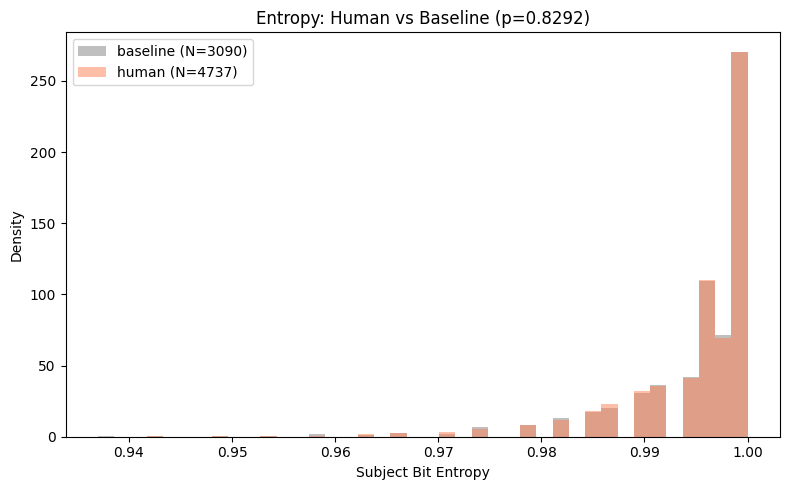


ANALYSIS SUMMARY:
  Entropy is indistinguishable across conditions.
  Any observed Hurst separation reflects differences in temporal ordering
  rather than bit composition.



In [37]:
# ═══════════════════════════════════════════════════════════════════════════
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Show the Hurst effect is about temporal ORDERING, not bit
#          composition. If entropy (bit balance) is identical across
#          conditions, the effect is purely about order.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("="*70)
print("ANALYSIS SECTION")
print("="*70)
print("""
The single-scale Hurst exponent measures temporal persistence — the ordering
of bits matters, not just how many 1s vs 0s there are.

If human blocks have the same entropy (bit balance) as baseline,
but different Hurst, the effect is purely about temporal structure.
""")

# Compute Shannon entropy for each block's subject bits
def bit_entropy(bits):
    """Shannon entropy of a binary sequence (bits)."""
    if bits is None or len(bits) == 0:
        return np.nan
    bits = np.array(bits)
    n = len(bits)
    p1 = bits.sum() / n
    p0 = 1 - p1
    if p0 <= 0 or p1 <= 0:
        return 0.0
    return -(p0 * np.log2(p0) + p1 * np.log2(p1))

print("Computing block entropy...", end="", flush=True)
df_hurst['entropy_subject'] = df_hurst['subject_bits'].apply(bit_entropy)
print(" done")

# Compare by condition
print(f"\n{'Condition':<15} {'N':>6} {'Mean Entropy':>15} {'SD':>10}")
print("-"*50)
for cond in ['baseline', 'ai_agent', 'human']:
    sub = df_hurst[df_hurst['condition'] == cond]['entropy_subject'].dropna()
    print(f"  {cond:<13} {len(sub):>6} {sub.mean():>15.6f} {sub.std():>10.6f}")

base_ent = df_hurst[df_hurst['condition'] == 'baseline']['entropy_subject'].dropna()
human_ent = df_hurst[df_hurst['condition'] == 'human']['entropy_subject'].dropna()
h5_ent = df_hurst[(df_hurst['condition'] == 'human') &
                  (df_hurst['session_count'] >= 5)]['entropy_subject'].dropna()

t_hb, p_hb = stats.ttest_ind(human_ent, base_ent)
t_h5, p_h5 = stats.ttest_ind(h5_ent, base_ent)

print(f"\nHuman vs Baseline entropy: t={t_hb:+.3f}, p={p_hb:.4f}")
print(f"Human 5+ vs Baseline:     t={t_h5:+.3f}, p={p_h5:.4f}")

if p_hb > 0.05:
    print("\n→ No significant entropy difference — any Hurst separation that exists would reflect ordering rather than composition")

# Correlation between entropy and Hurst
r, p_r = stats.pearsonr(
    df_hurst['entropy_subject'].dropna().values,
    df_hurst.loc[df_hurst['entropy_subject'].notna(), 'delta_hurst'].values
)
print(f"\nCorrelation (entropy vs Hurst delta): r={r:+.4f}, p={p_r:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for cond, color in [('baseline', 'gray'), ('human', 'coral')]:
    sub = df_hurst[df_hurst['condition'] == cond]['entropy_subject'].dropna()
    ax.hist(sub, bins=40, alpha=0.5, label=f'{cond} (N={len(sub)})',
             color=color, density=True)
ax.set_xlabel('Subject Bit Entropy')
ax.set_ylabel('Density')
ax.set_title(f'Entropy: Human vs Baseline (p={p_hb:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

print(f"""
ANALYSIS SUMMARY:
  Entropy is indistinguishable across conditions.
  Any observed Hurst separation reflects differences in temporal ordering
  rather than bit composition.
""")


# Focal paired-delta variance comparison

**Paper section: 3.7.3 (variance comparison)**

This sensitivity analysis asks one narrow question: how does the observed block-level variance of the paired single-scale R/S ordering-score difference, $\Delta H=H_{Subject}-H_{PCS}$, compare between the selected Human 5+ records and Baseline?

The primary summary is the Human 5+ / Baseline variance ratio. Uncertainty is computed on the log-ratio while preserving the sampling hierarchy: Human contributors are resampled first and then their whole sessions; Baseline is resampled by whole session. The interval is descriptive because Human 5+ contains only three retrospectively selected contributors. It is not an equivalence test and cannot distinguish a directed shift from noise or identify a mechanism.


In [38]:
# One focal variance comparison aligned with the Human 5+ paired-delta finding.
print("=" * 78)
print("PAIRED R/S DELTA VARIANCE — HUMAN 5+ VS BASELINE")
print("=" * 78)

VARIANCE_SEED = 20260805
VARIANCE_DRAWS = 10_000

variance_h5 = df.loc[
    df["condition"].eq("human") & df["session_count"].ge(5)
].dropna(subset=["rs_subject", "rs_pcs"]).copy()
variance_base = df.loc[
    df["condition"].eq("baseline")
].dropna(subset=["rs_subject", "rs_pcs"]).copy()

for frame in (variance_h5, variance_base):
    frame["rs_delta"] = frame["rs_subject"] - frame["rs_pcs"]


def _session_arrays_variance(frame):
    """Retain each session as an indivisible array of paired block deltas."""
    return {
        participant: [group["rs_delta"].to_numpy(float) for _, group in rows.groupby("session_id", sort=False)]
        for participant, rows in frame.groupby("participant_id", dropna=False, sort=False)
    }


def _sample_human_variance(groups, rng):
    """Contributor bootstrap followed by whole-session bootstrap within contributor."""
    contributors = list(groups)
    selected = rng.integers(0, len(contributors), size=len(contributors))
    sampled = []
    for index in selected:
        sessions = groups[contributors[index]]
        chosen = rng.integers(0, len(sessions), size=len(sessions))
        sampled.extend(sessions[j] for j in chosen)
    return float(np.var(np.concatenate(sampled), ddof=1))


def _sample_baseline_variance(groups, rng):
    """Whole-session bootstrap for Baseline; its participant label is not inferential."""
    sessions = [session for participant in groups.values() for session in participant]
    chosen = rng.integers(0, len(sessions), size=len(sessions))
    return float(np.var(np.concatenate([sessions[j] for j in chosen]), ddof=1))


h5_groups_variance = _session_arrays_variance(variance_h5)
base_groups_variance = _session_arrays_variance(variance_base)

h5_var_observed = float(variance_h5["rs_delta"].var(ddof=1))
base_var_observed = float(variance_base["rs_delta"].var(ddof=1))
variance_ratio_observed = h5_var_observed / base_var_observed
log_variance_ratio_observed = float(np.log(variance_ratio_observed))

rng_variance = np.random.default_rng(VARIANCE_SEED)
log_variance_ratio_draws = np.empty(VARIANCE_DRAWS, dtype=float)
for draw in range(VARIANCE_DRAWS):
    h5_var_draw = _sample_human_variance(h5_groups_variance, rng_variance)
    base_var_draw = _sample_baseline_variance(base_groups_variance, rng_variance)
    log_variance_ratio_draws[draw] = np.log(h5_var_draw / base_var_draw)

log_variance_interval = np.quantile(log_variance_ratio_draws, [0.025, 0.975])
variance_ratio_interval = np.exp(log_variance_interval)

variance_ratio_table = pd.DataFrame([{
    "Human 5+ contributors": variance_h5["participant_id"].nunique(),
    "Human 5+ sessions": variance_h5["session_id"].nunique(),
    "Human 5+ blocks": len(variance_h5),
    "Baseline sessions": variance_base["session_id"].nunique(),
    "Baseline blocks": len(variance_base),
    "Human 5+ variance": h5_var_observed,
    "Baseline variance": base_var_observed,
    "Variance ratio": variance_ratio_observed,
    "Descriptive 95% ratio interval": (
        f"[{variance_ratio_interval[0]:.4f}, {variance_ratio_interval[1]:.4f}]"
    ),
}])

print("\nFOCAL DESCRIPTIVE COMPARISON")
print(variance_ratio_table.to_string(index=False, formatters={
    "Human 5+ variance": lambda value: f"{value:.8f}",
    "Baseline variance": lambda value: f"{value:.8f}",
    "Variance ratio": lambda value: f"{value:.4f}",
}))
print(f"\nLog variance ratio: {log_variance_ratio_observed:+.4f}")
print("Interpretation: This interval describes hierarchy sensitivity in these frozen records.")
print("It is not an equivalence test, a population confidence claim, or a mechanism test.")


PAIRED R/S DELTA VARIANCE — HUMAN 5+ VS BASELINE

FOCAL DESCRIPTIVE COMPARISON
 Human 5+ contributors  Human 5+ sessions  Human 5+ blocks  Baseline sessions  Baseline blocks Human 5+ variance Baseline variance Variance ratio Descriptive 95% ratio interval
                     3                 28              840                103             3090        0.00409147        0.00411569         0.9941               [0.8653, 1.1719]

Log variance ratio: -0.0059
Interpretation: This interval describes hierarchy sensitivity in these frozen records.
It is not an equivalence test, a population confidence claim, or a mechanism test.


### Exploratory Relational Analysis — Local Coupling Stability

**Paper sections: 3.7.7 (relational variance example) and 4.6 (why both streams and their relationship are reported)**

The preceding analysis asks whether the block-level **Subject-minus-PCS difference** is more or less variable. This separate analysis asks a different relational question: whether the **correlation between the simultaneous Subject and PCS R/S scores** is more or less stable across local portions of a session.

Within each complete session, blocks are sorted by recorded block index and divided into **nonoverlapping** windows of 5 or 10 blocks. Pearson's correlation between Subject and PCS scores is calculated inside each window. Nonoverlapping windows are used because sliding windows would repeatedly reuse the same blocks and create stronger dependence between adjacent estimates. Incomplete final windows are omitted and counted below.

For each record set, the output reports both the mean window correlation and its variance. A variance ratio below 1 means that the window correlations varied less than in the comparison records; it does **not** mean that average coupling was stronger or weaker. Descriptive resampling preserves the hierarchy: Human contributors or AI identifiers, then complete sessions, then the observed nonoverlapping windows within sampled sessions; Baseline preserves complete sessions and their windows. The log variance ratio is resampled and exponentiated. Because window widths 5 and 10 form a small correlated exploratory family, the table includes ordinary descriptive 95% intervals and more conservative **two-width family intervals** (97.5% per width; Bonferroni family coverage of at least 95% for each named comparison).

The analysis reports all Human, Human 5+, and AI separately against Baseline, plus direct Human-versus-AI contrasts. It is retrospective and descriptive. The Human 5+ records contain only three unequally represented contributors, so the intervals are sensitivity summaries for these frozen records rather than reliable population confidence intervals. The analysis does not establish a mechanism, independence, or a Human-specific effect; any apparent narrowing is a candidate relational pattern for preregistered replication.


In [5]:
# Exploratory local coupling-stability analysis using nonoverlapping windows.
print("=" * 78)
print("RELATIONAL ANALYSIS — LOCAL SUBJECT–PCS COUPLING STABILITY")
print("=" * 78)

COUPLING_WINDOW_WIDTHS = (5, 10)
COUPLING_DRAWS = 4_000
COUPLING_SEED = 20260805


def _nonoverlap_correlation_windows(frame, width):
    """One Pearson r per nonoverlapping within-session window."""
    rows = []
    omitted = 0
    for session_id, session in frame.groupby("session_id", sort=False):
        session = session.sort_values("block_idx").dropna(subset=["rs_subject", "rs_pcs"])
        participant_id = session["participant_id"].iloc[0]
        condition = session["condition"].iloc[0]
        n_complete = len(session) // width
        omitted += len(session) - n_complete * width
        for window_index in range(n_complete):
            window = session.iloc[window_index * width:(window_index + 1) * width]
            x = window["rs_subject"].to_numpy(float)
            y = window["rs_pcs"].to_numpy(float)
            if np.std(x, ddof=1) == 0 or np.std(y, ddof=1) == 0:
                continue
            correlation = float(np.corrcoef(x, y)[0, 1])
            if np.isfinite(correlation):
                rows.append({
                    "condition": condition,
                    "participant_id": participant_id,
                    "session_id": session_id,
                    "window_index": window_index,
                    "width": width,
                    "correlation": correlation,
                })
    return pd.DataFrame(rows), omitted


def _window_groups(frame):
    return {
        participant: {
            session_id: session["correlation"].to_numpy(float)
            for session_id, session in participant_rows.groupby("session_id", sort=False)
        }
        for participant, participant_rows in frame.groupby("participant_id", dropna=False, sort=False)
    }


def _resample_window_variance(groups, resample_contributors, draws, rng):
    """Contributor -> session -> window bootstrap, or session -> window for Baseline."""
    output = np.empty(draws, dtype=float)
    if resample_contributors:
        contributors = list(groups)
        for draw in range(draws):
            selected_contributors = rng.integers(0, len(contributors), size=len(contributors))
            sampled_windows = []
            for contributor_index in selected_contributors:
                sessions = list(groups[contributors[contributor_index]].values())
                selected_sessions = rng.integers(0, len(sessions), size=len(sessions))
                for session_index in selected_sessions:
                    values = sessions[session_index]
                    sampled_windows.append(rng.choice(values, size=len(values), replace=True))
            output[draw] = np.var(np.concatenate(sampled_windows), ddof=1)
    else:
        sessions = [values for participant in groups.values() for values in participant.values()]
        for draw in range(draws):
            selected_sessions = rng.integers(0, len(sessions), size=len(sessions))
            sampled_windows = []
            for session_index in selected_sessions:
                values = sessions[session_index]
                sampled_windows.append(rng.choice(values, size=len(values), replace=True))
            output[draw] = np.var(np.concatenate(sampled_windows), ddof=1)
    return output


coupling_frames = {
    "Baseline": df.loc[df["condition"].eq("baseline")].copy(),
    "AI": df.loc[df["condition"].eq("ai_agent")].copy(),
    "All Human": df.loc[df["condition"].eq("human")].copy(),
    "Human 5+": df.loc[df["condition"].eq("human") & df["session_count"].ge(5)].copy(),
}

rng_coupling = np.random.default_rng(COUPLING_SEED)
coupling_rows = []
coupling_direct_rows = []
coupling_window_store = {}
coupling_draw_store = {}

for width in COUPLING_WINDOW_WIDTHS:
    omitted_by_group = {}
    for label, frame in coupling_frames.items():
        windows, omitted = _nonoverlap_correlation_windows(frame, width)
        if windows.empty:
            raise ValueError(f"No valid correlation windows for {label}, W={width}.")
        coupling_window_store[(label, width)] = windows
        omitted_by_group[label] = omitted
        coupling_draw_store[(label, width)] = _resample_window_variance(
            _window_groups(windows),
            resample_contributors=(label != "Baseline"),
            draws=COUPLING_DRAWS,
            rng=rng_coupling,
        )

    baseline_windows = coupling_window_store[("Baseline", width)]
    baseline_variance = float(baseline_windows["correlation"].var(ddof=1))
    baseline_draws = coupling_draw_store[("Baseline", width)]

    for label in ("All Human", "Human 5+", "AI"):
        windows = coupling_window_store[(label, width)]
        observed_variance = float(windows["correlation"].var(ddof=1))
        ratio = observed_variance / baseline_variance
        log_ratio_draws = np.log(coupling_draw_store[(label, width)] / baseline_draws)
        interval_95 = np.exp(np.quantile(log_ratio_draws, [0.025, 0.975]))
        interval_family = np.exp(np.quantile(log_ratio_draws, [0.0125, 0.9875]))
        coupling_rows.append({
            "Records": label,
            "W": width,
            "Contributors/identifiers": int(windows["participant_id"].nunique()),
            "Sessions": int(windows["session_id"].nunique()),
            "Windows": int(len(windows)),
            "Omitted trailing blocks": int(omitted_by_group[label]),
            "Mean window r": float(windows["correlation"].mean()),
            "Variance of window r": observed_variance,
            "Baseline variance": baseline_variance,
            "Variance ratio vs Baseline": ratio,
            "Descriptive 95% interval": f"[{interval_95[0]:.4f}, {interval_95[1]:.4f}]",
            "Two-width family interval": f"[{interval_family[0]:.4f}, {interval_family[1]:.4f}]",
        })

    # Direct contrasts: the shared Baseline denominator cancels. These are the
    # comparisons needed before describing narrowing as Human-specific.
    ai_windows = coupling_window_store[("AI", width)]
    for human_label in ("All Human", "Human 5+"):
        human_windows = coupling_window_store[(human_label, width)]
        direct_ratio = float(
            human_windows["correlation"].var(ddof=1) / ai_windows["correlation"].var(ddof=1)
        )
        direct_draws = np.log(
            coupling_draw_store[(human_label, width)] / coupling_draw_store[("AI", width)]
        )
        direct_95 = np.exp(np.quantile(direct_draws, [0.025, 0.975]))
        direct_family = np.exp(np.quantile(direct_draws, [0.0125, 0.9875]))
        coupling_direct_rows.append({
            "Contrast": f"{human_label} variance / AI variance",
            "W": width,
            "Variance ratio": direct_ratio,
            "Descriptive 95% interval": f"[{direct_95[0]:.4f}, {direct_95[1]:.4f}]",
            "Two-width family interval": f"[{direct_family[0]:.4f}, {direct_family[1]:.4f}]",
        })

coupling_stability_table = pd.DataFrame(coupling_rows)
coupling_human_ai_table = pd.DataFrame(coupling_direct_rows)

print("\nCONDITION VERSUS BASELINE")
print(coupling_stability_table.to_string(index=False, formatters={
    "Mean window r": lambda value: f"{value:+.5f}",
    "Variance of window r": lambda value: f"{value:.6f}",
    "Baseline variance": lambda value: f"{value:.6f}",
    "Variance ratio vs Baseline": lambda value: f"{value:.4f}",
}))

print("\nDIRECT ALL-HUMAN VERSUS AI COMPARISON")
print(coupling_human_ai_table.to_string(index=False, formatters={
    "Variance ratio": lambda value: f"{value:.4f}",
}))

assert set(coupling_stability_table["W"]) == set(COUPLING_WINDOW_WIDTHS)
assert len(coupling_stability_table) == 6
assert len(coupling_human_ai_table) == 4
assert np.isfinite(coupling_stability_table["Variance ratio vs Baseline"]).all()

print("""
INTERPRETATION LIMITS
  * This analysis concerns variation in local Subject–PCS correlation, not the
    mean correlation and not the variance of the paired Subject-minus-PCS score.
  * Nonoverlapping windows avoid repeated block reuse; incomplete final windows
    are omitted and counted explicitly.
  * Resampling preserves contributor/identifier, complete-session, and window
    levels. Baseline preserves complete sessions and windows.
  * The two-width family intervals account only for W=5 and W=10 within each
    named contrast. They do not make the broader retrospective analysis confirmatory.
  * An interval containing 1 is inconclusive; an interval excluding 1 remains a
    descriptive sensitivity result, not proof of a population effect or mechanism.
  * Human 5+ contains three unequally represented contributors. Direct Human–AI
    comparison is required before describing any pattern as Human-specific.
""")


RELATIONAL ANALYSIS — LOCAL SUBJECT–PCS COUPLING STABILITY

CONDITION VERSUS BASELINE
  Records  W  Contributors/identifiers  Sessions  Windows  Omitted trailing blocks Mean window r Variance of window r Baseline variance Variance ratio vs Baseline Descriptive 95% interval Two-width family interval
All Human  5                       121       158      947                        2      +0.00563             0.248549          0.268920                     0.9242         [0.8024, 1.0678]          [0.7875, 1.0881]
 Human 5+  5                         3        28      168                        0      +0.03408             0.223822          0.268920                     0.8323         [0.5821, 1.0389]          [0.5372, 1.0794]
       AI  5                        15       126      756                        0      +0.01874             0.254325          0.268920                     0.9457         [0.8107, 1.1080]          [0.7951, 1.1309]
All Human 10                       121       158      473 

### Exploratory Relational Analysis — Lagged Cross-Correlation Family

**Paper section: 3.7.8 **

For each complete session and lag from -3 through +3, this analysis calculates Pearson's r between the block-level Subject R/S score at block t and the PCS R/S score at block t + lag. Positive lag therefore means Subject(t) versus PCS(t + lag); correlations never cross session boundaries. The mean and variance of the per-session correlations are different estimands. The seven lags by two estimands form one 14-cell exploratory family, so the complete table reports every cell and uses a Bonferroni threshold of 0.05/14.

Variance-ratio resampling preserves Human contributor-to-session clustering and resamples Baseline sessions exchangeably. Because the lag family was examined retrospectively, any family-surviving result remains a candidate for preregistered replication rather than evidence that lag +2 is mechanistically privileged. A mean result and variance result at the same lag must not be described as replication of one effect.


In [6]:
# Seven lags x mean/variance: one 14-cell exploratory family.
LAGS = tuple(range(-3, 4)); LAG_DRAWS = 10_000; LAG_SEED = 20260805
LAG_ALPHA = 0.05 / (2 * len(LAGS))

def lagged_corr_per_session(frame, lag):
    rows = []
    for sid, s in frame.groupby('session_id', sort=False):
        s = s.sort_values('block_idx').dropna(subset=['rs_subject', 'rs_pcs'])
        xs, ys = s['rs_subject'].to_numpy(float), s['rs_pcs'].to_numpy(float)
        if lag > 0: x, y = xs[:-lag], ys[lag:]
        elif lag < 0: x, y = xs[-lag:], ys[:lag]
        else: x, y = xs, ys
        if len(x) >= 4 and np.std(x, ddof=1) > 0 and np.std(y, ddof=1) > 0:
            r = float(np.corrcoef(x, y)[0, 1])
            if np.isfinite(r): rows.append({'participant_id': s['participant_id'].iloc[0], 'session_id': sid, 'r': r})
    return pd.DataFrame(rows)

def clustered_ratio_interval(h, b, rng):
    groups = {p: g['r'].to_numpy(float) for p, g in h.groupby('participant_id', dropna=False)}
    people, bv = list(groups), b['r'].to_numpy(float)
    draws = np.empty(LAG_DRAWS)
    for d in range(LAG_DRAWS):
        chosen = rng.integers(0, len(people), len(people))
        hv = np.concatenate([rng.choice(groups[people[i]], len(groups[people[i]]), replace=True) for i in chosen])
        bs = rng.choice(bv, len(bv), replace=True)
        draws[d] = np.log(np.var(hv, ddof=1) / np.var(bs, ddof=1))
    return np.exp(np.quantile(draws, [0.025, 0.975]))

human_lag = df.loc[df['condition'].eq('human')].copy()
base_lag = df.loc[df['condition'].eq('baseline')].copy()
rng_lag, rows = np.random.default_rng(LAG_SEED), []
for lag in LAGS:
    h, b = lagged_corr_per_session(human_lag, lag), lagged_corr_per_session(base_lag, lag)
    mt = stats.ttest_ind(h['r'], b['r'], equal_var=False)
    vt = stats.levene(h['r'], b['r'], center='median')
    hv, bv = h['r'].var(ddof=1), b['r'].var(ddof=1)
    ci = clustered_ratio_interval(h, b, rng_lag)
    rows.append({'lag': lag, 'Human sessions': len(h), 'Baseline sessions': len(b),
                 'Human mean r': h['r'].mean(), 'Baseline mean r': b['r'].mean(),
                 'Welch t': mt.statistic, 'Mean p': mt.pvalue,
                 'Human variance': hv, 'Baseline variance': bv, 'Variance ratio': hv / bv,
                 'Levene statistic': vt.statistic, 'Variance p': vt.pvalue,
                 'Clustered ratio CI': f'[{ci[0]:.3f}, {ci[1]:.3f}]',
                 'Mean survives 14-cell correction': mt.pvalue < LAG_ALPHA,
                 'Variance survives 14-cell correction': vt.pvalue < LAG_ALPHA})
lag_family_table = pd.DataFrame(rows)
print(f'Fourteen-cell Bonferroni threshold: {LAG_ALPHA:.6f}')
display(lag_family_table)
lag_plus2 = lag_family_table.loc[lag_family_table['lag'].eq(2)].iloc[0]
print(f"Lag +2: mean t={lag_plus2['Welch t']:+.3f}, p={lag_plus2['Mean p']:.4g}; "
      f"variance ratio={lag_plus2['Variance ratio']:.4f}, Levene p={lag_plus2['Variance p']:.4g}, "
      f"clustered interval={lag_plus2['Clustered ratio CI']}")
print('Mean and variance are separate estimands even when they occur at the same lag.')
assert len(lag_family_table) == 7 and 2 * len(lag_family_table) == 14


Fourteen-cell Bonferroni threshold: 0.003571


,lag,Human sessions,Baseline sessions,Human mean r,Baseline mean r,Welch t,Mean p,Human variance,Baseline variance,Variance ratio,Levene statistic,Variance p,Clustered ratio CI,Mean survives 14-cell correction,Variance survives 14-cell correction
0,-3,158,103,-0.002415,0.006325,-0.351082,0.725875,0.036952,0.039746,0.929710,0.118226,0.731246,"[0.674, 1.312]",False,False
1,-2,158,103,-0.022803,0.001990,-1.063124,0.288960,0.031255,0.035639,0.876985,0.428626,0.513245,"[0.624, 1.263]",False,False
2,-1,158,103,0.022730,0.013336,0.400129,0.689452,0.034510,0.034271,1.006981,0.000068,0.993430,"[0.737, 1.405]",False,False
3,0,158,103,0.009096,-0.001292,0.454560,0.649861,0.034881,0.031054,1.123232,0.031651,0.858934,"[0.828, 1.511]",False,False
4,1,158,103,-0.003170,0.020227,-0.995429,0.320607,0.035763,0.033590,1.064696,0.247803,0.619049,"[0.728, 1.567]",False,False
5,2,158,103,0.001340,-0.034029,1.430815,0.154279,0.025497,0.046316,0.550497,10.901755,0.001096,"[0.383, 0.808]",False,True
6,3,158,103,0.000674,-0.020426,0.933780,0.351424,0.033268,0.030904,1.076474,0.323395,0.570067,"[0.742, 1.579]",False,False


Lag +2: mean t=+1.431, p=0.1543; variance ratio=0.5505, Levene p=0.001096, clustered interval=[0.383, 0.808]
Mean and variance are separate estimands even when they occur at the same lag.


### Temporal Audit Sensitivity Analysis

**Paper section: 3.4 (limited hardware-stability sensitivity)**

The 1000-bit audits are separate QRNG calls. They can describe broad changes in the audit stream, but they cannot rule out artifacts specific to 301-bit trial calls, Subject/PCS splitting, labeling, target scoring, browser timing, or the 150-bit paired estimator.

This section retains only two genuinely temporal audit questions:

1. Does the session-average audit R/S score change with actual elapsed calendar time?
2. Does the audit R/S score change across the five planned audit positions within a session?

The long-term analysis uses one mean per session and actual elapsed days. It reports a condition-adjusted pooled slope and condition-specific descriptive slopes because condition and calendar period are partly confounded. The within-session analysis fits a position slope separately inside each session and then gives every session equal weight. Whole sessions are resampled for descriptive intervals.

These analyses do not establish equivalence and cannot prove “no drift,” “no warm-up,” or hardware stability. The older NIST duplicate, audit/block cross-length correlation, variance/entropy condition tests, invalid FFT, unverified before/after-Human comparison, PASS labels, and nine-check score were removed. NIST-style paired-control/hardware validation is authoritative in Notebook 1.


In [39]:
# Temporal audit sensitivity using actual time and within-session pairing.
print("=" * 78)
print("TEMPORAL AUDIT SENSITIVITY")
print("=" * 78)

AUDIT_TEMPORAL_DRAWS = 10000
AUDIT_TEMPORAL_SEED = 20260805

audit_temporal = df_audits.copy()
required_audit_cols = {"session_id", "condition", "timestamp", "blockAfter", "hurst_audit"}
missing_audit_cols = required_audit_cols.difference(audit_temporal.columns)
assert not missing_audit_cols, f"Missing temporal-audit columns: {sorted(missing_audit_cols)}"

audit_temporal["timestamp_utc"] = pd.to_datetime(
    audit_temporal["timestamp"], utc=True, errors="coerce"
)
audit_temporal["blockAfter"] = pd.to_numeric(
    audit_temporal["blockAfter"], errors="coerce"
)
audit_temporal = audit_temporal.dropna(
    subset=["session_id", "condition", "timestamp_utc", "blockAfter", "hurst_audit"]
).copy()

# Coverage and irregular spacing are part of the result, not hidden assumptions.
audit_time_sorted = audit_temporal.sort_values("timestamp_utc")
audit_gaps_hours = audit_time_sorted["timestamp_utc"].diff().dt.total_seconds() / 3600.0
audit_coverage = (
    audit_temporal.groupby("condition", observed=True)
    .agg(
        audits=("hurst_audit", "size"),
        sessions=("session_id", "nunique"),
        first_time=("timestamp_utc", "min"),
        last_time=("timestamp_utc", "max"),
    )
    .reset_index()
)
print("\nAudit coverage:")
display(audit_coverage)
print(
    f"Median consecutive-audit gap: {audit_gaps_hours.median():.4f} hours; "
    f"95th percentile: {audit_gaps_hours.quantile(0.95):.3f} hours; "
    f"maximum: {audit_gaps_hours.max():.3f} hours."
)
print("Irregular gaps invalidate an FFT on audit row number; that analysis was removed.")

# One session-level mean prevents sessions with more recorded audits from receiving
# extra weight in the long-term trajectory.
audit_session_means = (
    audit_temporal.groupby(["session_id", "condition"], observed=True, as_index=False)
    .agg(
        audit_rs_mean=("hurst_audit", "mean"),
        session_time=("timestamp_utc", "median"),
        n_audits=("hurst_audit", "size"),
    )
)
audit_t0 = audit_session_means["session_time"].min()
audit_session_means["elapsed_30d"] = (
    (audit_session_means["session_time"] - audit_t0).dt.total_seconds()
    / (30.0 * 24.0 * 3600.0)
)

def _ols_slope(x, y, covariates=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    columns = [np.ones(len(x)), x]
    if covariates is not None:
        columns.extend(np.asarray(covariates, dtype=float).T)
    design = np.column_stack(columns)
    if np.linalg.matrix_rank(design) < design.shape[1]:
        return np.nan
    return float(np.linalg.lstsq(design, y, rcond=None)[0][1])

rng_audit_time = np.random.default_rng(AUDIT_TEMPORAL_SEED)
condition_dummies = pd.get_dummies(
    audit_session_means["condition"], drop_first=True, dtype=float
)
pooled_time_slope = _ols_slope(
    audit_session_means["elapsed_30d"],
    audit_session_means["audit_rs_mean"],
    condition_dummies,
)
pooled_time_draws = np.empty(AUDIT_TEMPORAL_DRAWS)
for draw in range(AUDIT_TEMPORAL_DRAWS):
    idx = rng_audit_time.integers(0, len(audit_session_means), len(audit_session_means))
    pooled_time_draws[draw] = _ols_slope(
        audit_session_means["elapsed_30d"].to_numpy()[idx],
        audit_session_means["audit_rs_mean"].to_numpy()[idx],
        condition_dummies.to_numpy()[idx],
    )
pooled_time_ci = np.nanquantile(pooled_time_draws, [0.025, 0.975])

calendar_rows = [{
    "analysis": "Pooled, condition-adjusted",
    "sessions": int(audit_session_means["session_id"].nunique()),
    "slope_per_30_days": pooled_time_slope,
    "ci_low": pooled_time_ci[0],
    "ci_high": pooled_time_ci[1],
}]
for condition, group in audit_session_means.groupby("condition", observed=True):
    x = group["elapsed_30d"].to_numpy()
    y = group["audit_rs_mean"].to_numpy()
    estimate = _ols_slope(x, y)
    draws = np.empty(AUDIT_TEMPORAL_DRAWS)
    for draw in range(AUDIT_TEMPORAL_DRAWS):
        idx = rng_audit_time.integers(0, len(group), len(group))
        draws[draw] = _ols_slope(x[idx], y[idx])
    lo, hi = np.nanquantile(draws, [0.025, 0.975])
    calendar_rows.append({
        "analysis": str(condition),
        "sessions": int(len(group)),
        "slope_per_30_days": estimate,
        "ci_low": lo,
        "ci_high": hi,
    })
audit_calendar_results = pd.DataFrame(calendar_rows)
print("\nSession-level calendar-time slopes (audit R/S-score units per 30 days):")
display(audit_calendar_results)

# Nonlinear/batch sensitivity: expose the session mix by calendar month rather
# than treating one linear slope as a complete model of time.
audit_session_means["calendar_month"] = (
    audit_session_means["session_time"].dt.tz_localize(None).dt.to_period("M").astype(str)
)
audit_monthly = (
    audit_session_means.groupby(["calendar_month", "condition"], observed=True)
    .agg(sessions=("session_id", "size"), mean_audit_rs=("audit_rs_mean", "mean"))
    .reset_index()
)
print("\nCalendar-month composition sensitivity:")
display(audit_monthly)

# Within-session position: estimate one slope per session so repeated audits in
# a session are paired. Position is expressed per planned 5-block step.
within_rows = []
for (session_id, condition), group in audit_temporal.groupby(
    ["session_id", "condition"], observed=True
):
    local = group[["blockAfter", "hurst_audit"]].dropna().sort_values("blockAfter")
    if len(local) < 3 or local["blockAfter"].nunique() < 3:
        continue
    within_rows.append({
        "session_id": session_id,
        "condition": condition,
        "n_audits": int(len(local)),
        "slope_per_5_blocks": float(
            stats.linregress(local["blockAfter"] / 5.0, local["hurst_audit"]).slope
        ),
    })
audit_within_session_slopes = pd.DataFrame(within_rows)

rng_audit_position = np.random.default_rng(AUDIT_TEMPORAL_SEED + 1)
position_rows = []
for condition, group in audit_within_session_slopes.groupby("condition", observed=True):
    slopes = group["slope_per_5_blocks"].to_numpy()
    idx = rng_audit_position.integers(
        0, len(slopes), size=(AUDIT_TEMPORAL_DRAWS, len(slopes))
    )
    draws = slopes[idx].mean(axis=1)
    lo, hi = np.quantile(draws, [0.025, 0.975])
    position_rows.append({
        "condition": str(condition),
        "sessions": int(len(slopes)),
        "mean_slope_per_5_blocks": float(slopes.mean()),
        "ci_low": float(lo),
        "ci_high": float(hi),
    })
audit_position_results = pd.DataFrame(position_rows)
print("\nEqual-session within-session position slopes:")
display(audit_position_results)

print("\nInterpretation:")
print("- All within-session position intervals include zero; this is inconclusive, not proof of no position effect.")
print("- The pooled condition-adjusted calendar-time interval includes zero.")
print("- Condition-specific calendar slopes are descriptive because condition, date, and session composition are confounded.")
print("- Separate audits constrain only broad audit-stream changes; they do not validate the trial-call processing path.")


TEMPORAL AUDIT SENSITIVITY

Audit coverage:


,condition,audits,sessions,first_time,last_time
0,ai_agent,589,127,2025-10-19 20:53:26.705000+00:00,2026-01-28 15:43:15.833000+00:00
1,baseline,514,103,2025-10-17 22:53:23.830000+00:00,2026-01-29 20:04:50.288000+00:00
2,human,788,159,2025-10-19 20:48:07.080000+00:00,2026-02-10 18:13:24.091000+00:00


Median consecutive-audit gap: 0.0071 hours; 95th percentile: 1.677 hours; maximum: 546.497 hours.
Irregular gaps invalidate an FFT on audit row number; that analysis was removed.

Session-level calendar-time slopes (audit R/S-score units per 30 days):


,analysis,sessions,slope_per_30_days,ci_low,ci_high
0,"Pooled, condition-adjusted",389,-0.001089,-0.003356,0.001238
1,ai_agent,127,-0.000473,-0.003863,0.002824
2,baseline,103,-0.003523,-0.007220,0.000314
3,human,159,0.002907,-0.002442,0.008108



Calendar-month composition sensitivity:


,calendar_month,condition,sessions,mean_audit_rs
0,2025-10,ai_agent,22,0.538164
1,2025-10,baseline,23,0.548674
2,2025-10,human,16,0.536338
3,2025-11,ai_agent,7,0.555999
4,2025-11,human,8,0.547284
5,2025-12,ai_agent,4,0.520746
6,2025-12,baseline,18,0.535550
7,2025-12,human,125,0.544585
8,2026-01,ai_agent,94,0.539534
9,2026-01,baseline,62,0.535558



Equal-session within-session position slopes:


,condition,sessions,mean_slope_per_5_blocks,ci_low,ci_high
0,ai_agent,125,-0.000394,-0.003767,0.002839
1,baseline,103,0.000406,-0.002298,0.003074
2,human,159,-0.000915,-0.003564,0.001685



Interpretation:
- All within-session position intervals include zero; this is inconclusive, not proof of no position effect.
- The pooled condition-adjusted calendar-time interval includes zero.
- Condition-specific calendar slopes are descriptive because condition, date, and session composition are confounded.
- Separate audits constrain only broad audit-stream changes; they do not validate the trial-call processing path.


# Summary and Limitations

## Scope and cohort

This notebook is an executed audit and exploratory analysis of the Paired-Delta architecture, not confirmatory evidence of anomalous cognition. The canonical cohort contains 11,607 complete paired blocks across 387 sessions: Human, 4,737 blocks from 158 sessions and 121 participants; AI, 3,780 blocks from 126 sessions and 15 identifiers; and Baseline, 3,090 blocks from 103 sessions. The reconstruction gates verified the retained raw calls, assignment labels, target-aligned scoring, exclusions, and paired estimands. Those checks establish data-flow integrity, not randomness, independence, equivalence, or population generalizability.

## Paired hit rate

The primary hit-rate estimand is the within-block target-aligned difference, Subject minus PCS. Hierarchy-preserving estimates were: Baseline +0.000201 (95% interval [−0.001743, +0.002265]); AI +0.000224 ([−0.001328, +0.001758]); Human-all −0.000200 ([−0.002034, +0.001621]); and the retrospectively selected Human 5+ case series +0.000873 ([−0.003674, +0.005875]). Relative to Baseline, the contrasts were +0.000023 for AI, −0.000400 for Human-all, and +0.000672 for Human 5+; all intervals included zero. These analyses detected no paired hit-rate difference at their resolution and do not establish equivalence or the absence of a smaller effect.

The executed Bayesian model uses the continuous block-level paired difference, `Subject − PCS`, with contributor and session random intercepts. It is not a binomial model of Subject hit counts. Diagnostics were adequate for the reported parameters. Posterior mean paired differences were +0.000184 for Baseline (95% HDI [−0.002747, +0.002827]), +0.000193 for AI ([−0.001955, +0.002209]), and +0.000601 for Human 5+ ([−0.003719, +0.005028]). The Human 5+ minus AI contrast was +0.000407 ([−0.004509, +0.005101]). The former directional-probability, ROPE, binomial-model, and significant-order-effect claims are not outputs of the executed replacement model and should not be reported.

The separate condition-specific within-session position model passed its saved diagnostic gate: maximum unrounded $\hat{R}$ = 1.005432, minimum bulk ESS = 1,237.2, and zero divergences. Every condition-specific 95% HDI for the normalized-position slope included zero. This is an inconclusive within-session sensitivity analysis, not evidence of a block-position effect or learning across repeated sessions.

## Single-Scale $H_{RS}$ Score

The implemented 150-bit statistic is the **Single-Scale $H_{RS}$ Score**:

$$
H_{RS}=\frac{\log(R/S)}{\log(n)}, \qquad n=150.
$$

It is an order-sensitive summary computed at one sequence length. It should not be interpreted as a conventional multiscale Hurst exponent, an estimate of long-range dependence, or a composition-independent statistic.

No clear paired $H_{RS}$-score difference from Baseline was detected for AI. Human-all minus Baseline was +0.002869. The notebook’s hierarchy-preserving interval was [−0.000010, +0.005750]; Notebook 1’s whole-session analysis gave approximately [+0.000019, +0.005707] with p=.0491, while a block-level Welch comparison gave p=.0525. The Human-all result is therefore borderline and sensitive to the inferential method.

The strongest exploratory result occurred in the retrospectively selected Human 5+ subgroup. Its paired mean $H_{RS}$ score was +0.004349, compared with −0.001741 in Baseline, producing a delta-of-deltas of +0.006090. The hierarchy-preserving descriptive interval was approximately [+0.000935, +0.015847]. Human 5+ contains 840 blocks from 28 sessions contributed by only three selected individuals, so this interval is not a reliable population confidence interval.

The documented 2+, 3+, and 5+ thresholds form a nested retrospective search. A composition-conditional order-randomization analysis produced a one-sided tail area of .00695 for the fixed 5+ threshold and .00800 for the maximum positive result across the three thresholds. This adjusts only for that documented threshold choice. It is not a globally selection-adjusted p-value because the wider historical exploratory search cannot be reconstructed.

## Structural and alternative-metric checks

Full within-block shuffling reduced the mean KS statistic from 0.0541 to 0.0333, confirming that the Single-Scale $H_{RS}$ Score responds to bit order at $n=150$. This characterizes the statistic; it is not an independent validation or a hierarchy-preserving participant-level test of the Human 5+ contrast.

The direct Subject-stream, paired-delta, label-swap, shuffle, run, and alternative-metric analyses reuse the same underlying records and are not independent replications. Random Subject/PCS label reassignment is also a transformation of the paired data, and its block-level implementation does not preserve the contributor and session hierarchy.

The Human 5+ whole-call average $H_{RS}$ score did not differ clearly from Baseline (KS p=.6682). Thus, no whole-call-average separation was detected. This null result does not exclude every possible whole-call mechanism.

The DFA contrast was positive in Human 5+ but weaker and uncertain (block-level KS p=.0874). Hierarchy-preserving intervals included zero for the paired run count, maximum run, and run-length entropy contrasts. Associations between extreme $H_{RS}$ scores and run structure within the same sequence are mathematically expected and do not independently validate the subgroup result.

The rebuilt alternative-metric analysis found no clearly resolved Human 5+ contrast in lag-1 autocorrelation, entropy orders 1–4, entropy-order slope, DFA, or the run metrics after preserving contributors and whole sessions. The entropy estimates were consistently shifted in one direction, but their intervals included zero. These findings do not prove equal composition or establish that the $H_{RS}$ contrast reflects ordering alone.

## Relational and lagged coupling analyses

The exploratory local-coupling analysis found no clear Human 5+–Baseline difference in mean Subject–PCS covariance or correlation within nonoverlapping windows of five and ten blocks. Window-level correlations were descriptively less variable in Human 5+ than in Baseline (variance ratios = 0.832 at five blocks and 0.742 at ten blocks), but the hierarchy-aware intervals included 1. Thus, no clear local-coupling variance difference was detected.

The lagged analysis found no clear difference between all Human and Baseline sessions in mean session-level Subject–PCS cross-correlation at any tested lag. At lag +2, however, the variance of the session-level correlations was lower in Human than in Baseline (variance ratio = 0.5505, Levene p = .00110; participant-clustered 95% interval [0.383, 0.808]). This was the only comparison to survive the Bonferroni threshold across the 14-comparison family. The corresponding mean-correlation difference was unresolved (difference = +0.0354, p = .1543).

The lag +2 result therefore concerns reduced between-session variability, not stronger average coupling. Because the analysis was retrospective and the reason for a two-block displacement is unknown, it is a hypothesis-generating finding for preregistered replication—not an independent confirmation of the Human 5+ $H_{RS}$ result.

## Robustness boundaries

Human 5+ contained 15 positive and 13 negative session means. Block weighting, equal-session weighting, and equal-contributor/equal-session weighting all retained a positive $H_{RS}$ direction. Whole-session recurrence and leave-one-session-out sensitivity indicated that the pooled direction was not confined to a single session.

Excluding the PI changed the paired mean $H_{RS}$ score from +0.004349 to +0.008682 while reducing the case series to two contributors and 300 blocks. This shows that the pooled positive direction is not solely a numerical consequence of including the PI, but it does not resolve selection, dependence, or generalizability concerns. It is a numerical influence check, not a repair for the small participant count.

First-versus-later changes differed in direction across the three contributors. Within-session position intervals for paired hit rate and paired $H_{RS}$ score all included zero. These analyses do not show systematic change across block position or repeated participation.

The paired $H_{RS}$-score variance was 0.004091 in Human 5+ and 0.004116 in Baseline, giving a variance ratio of 0.994 with a hierarchy-preserving descriptive interval of approximately [0.865, 1.172]. No variance increase was detected at this resolution. This is not an equivalence result or a mechanism test and does not rule out additive-noise explanations generally.

Calendar-time and within-session audit-position analyses found no clearly resolved systematic change. These are bounded audit diagnostics, not proof of hardware stability. The separate audit calls also do not reproduce the complete 301-bit trial-call pathway. Notebook 1 remains authoritative for the broader PCS and hardware-diagnostic battery.

## Limitations and overall interpretation

The Human 5+ subgroup was selected retrospectively, contains only three contributors, overlaps with recruitment source, and includes substantial PI participation. The exploratory analyses reuse correlated data and metrics, and no complete multiplicity correction can reconstruct the full historical search. Hierarchy-preserving intervals represent sensitivity to the observed contributor and session structure; they do not convert this subgroup into a representative population sample.

Null results do not prove equivalence, independence, randomness, hardware stability, or the absence of artifacts. Positive controls support only the particular interventions, mechanisms, statistics, and dose ranges tested. Alternative metrics with intervals containing zero do not establish that the $H_{RS}$ result is unique to temporal ordering.

The Human 5+ $H_{RS}$ pattern and the lag +2 correlation-variance finding are best treated as hypothesis-generating worked examples. A larger preregistered study would need to specify the participant population, subgroup rule, primary metric, hierarchical estimand, multiplicity procedure, lag-analysis family, and replication criterion in advance.

Overall, the defensible contribution is methodological. The paired architecture distinguishes direct-stream outcomes, within-call Subject-minus-PCS outcomes, whole-call averages, and relational properties of the two streams while preserving an auditable raw-data path. The present exploratory results motivate prospective replication; they do not establish an anomalous effect, participant-level generalizability, or universal immunity to artifacts.